In [1]:
import numpy as np 
import os 
import scipy.io
from sklearn.metrics import r2_score 
import matplotlib.pyplot as plt
import seaborn as sns
import json
main_pathname = 'c:/Users/yaoyu/Documents/Epilepsy_research/'
window_length = 3
stride = 1

# Checking FOS fit for all patients 
patients = ['HUP64', 'HUP68', 'HUP70', 'HUP72','HUP78','HUP86','MAYO010','MAYO011','MAYO016','MAYO020']

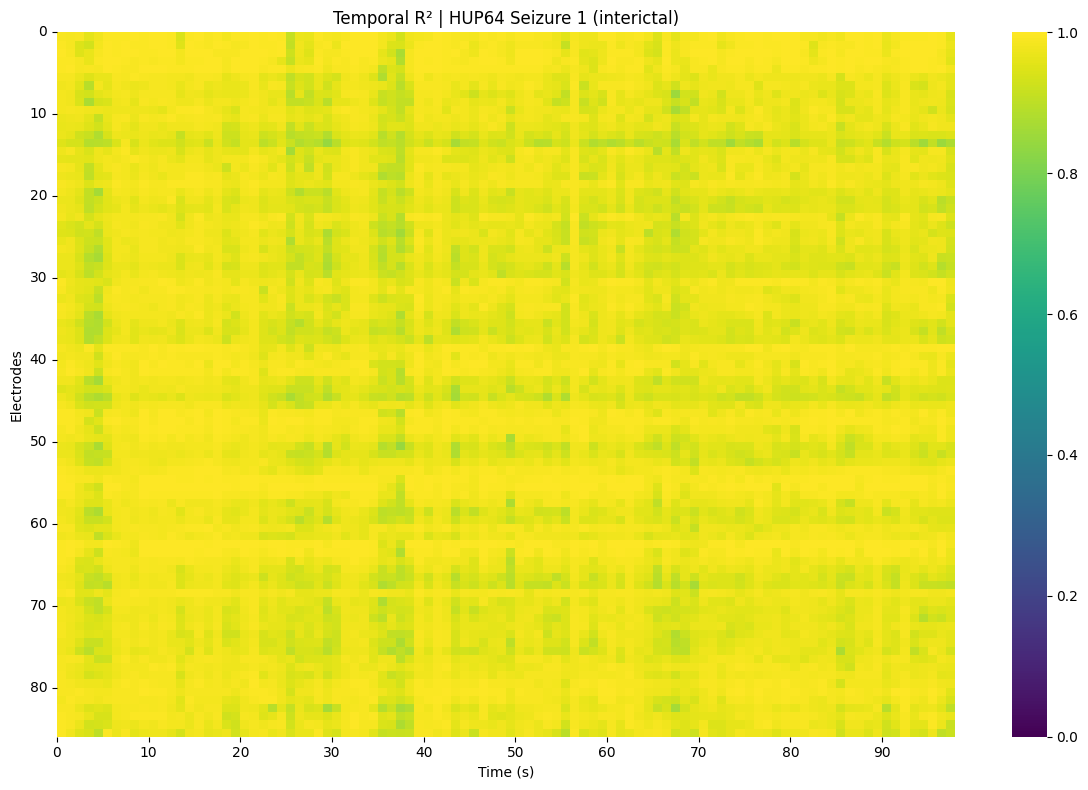

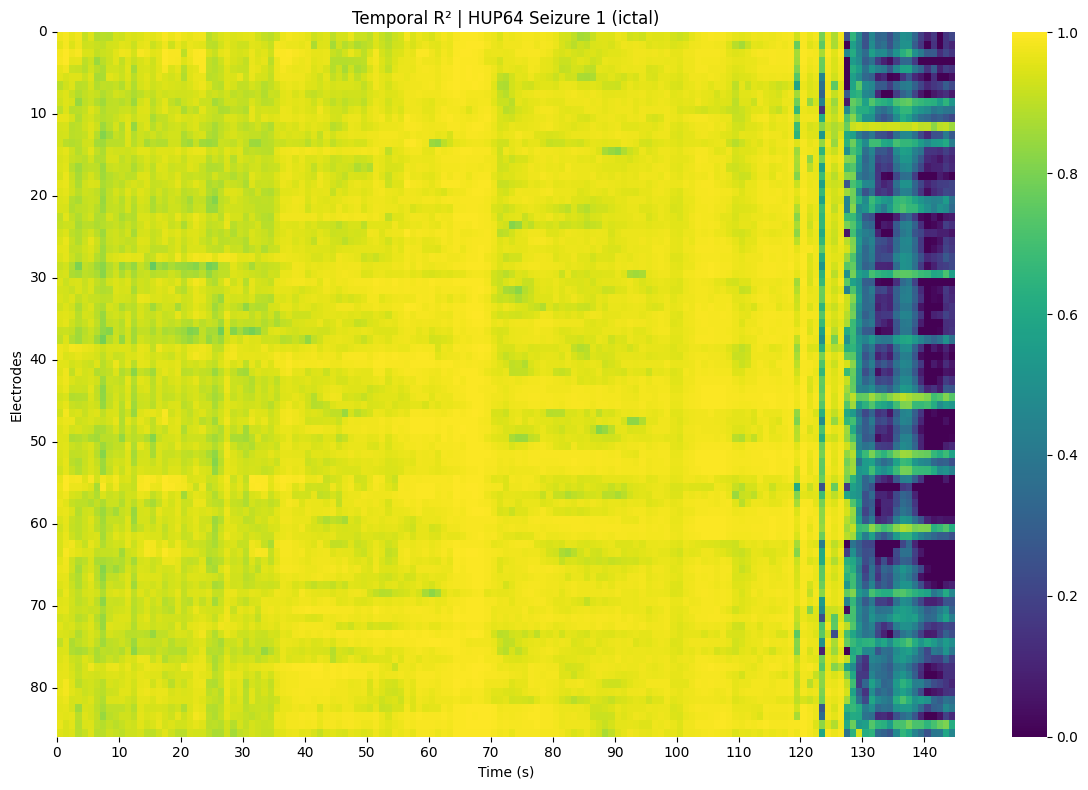

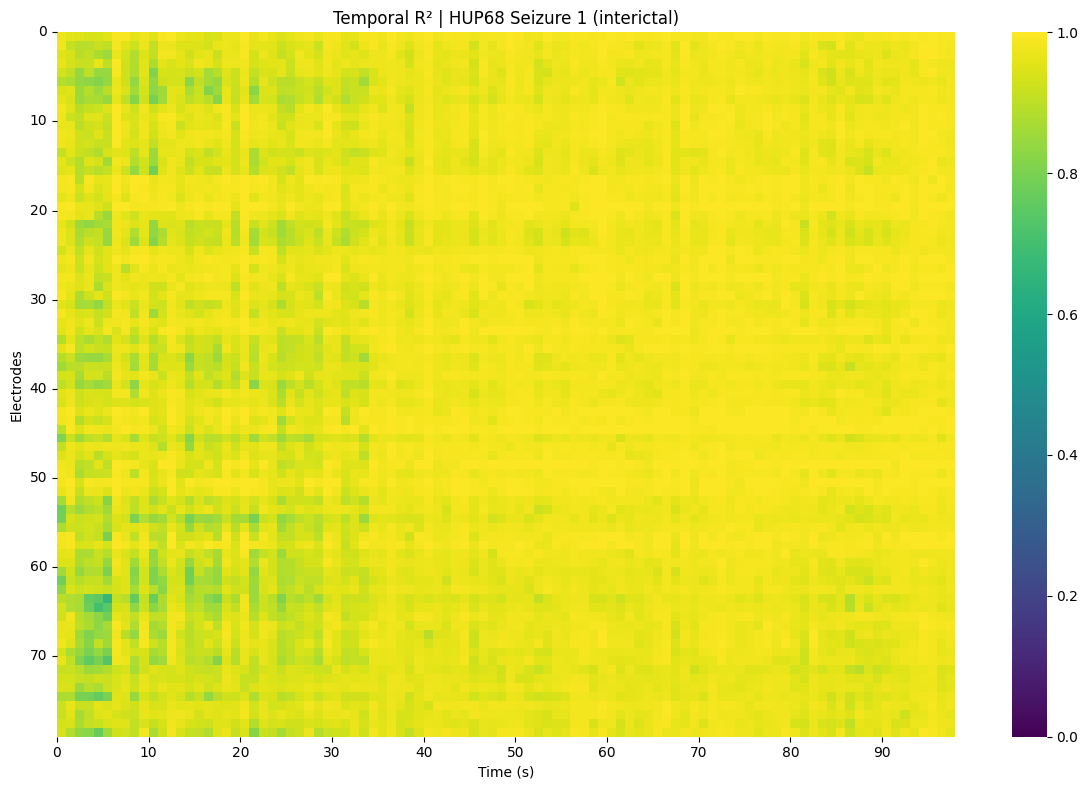

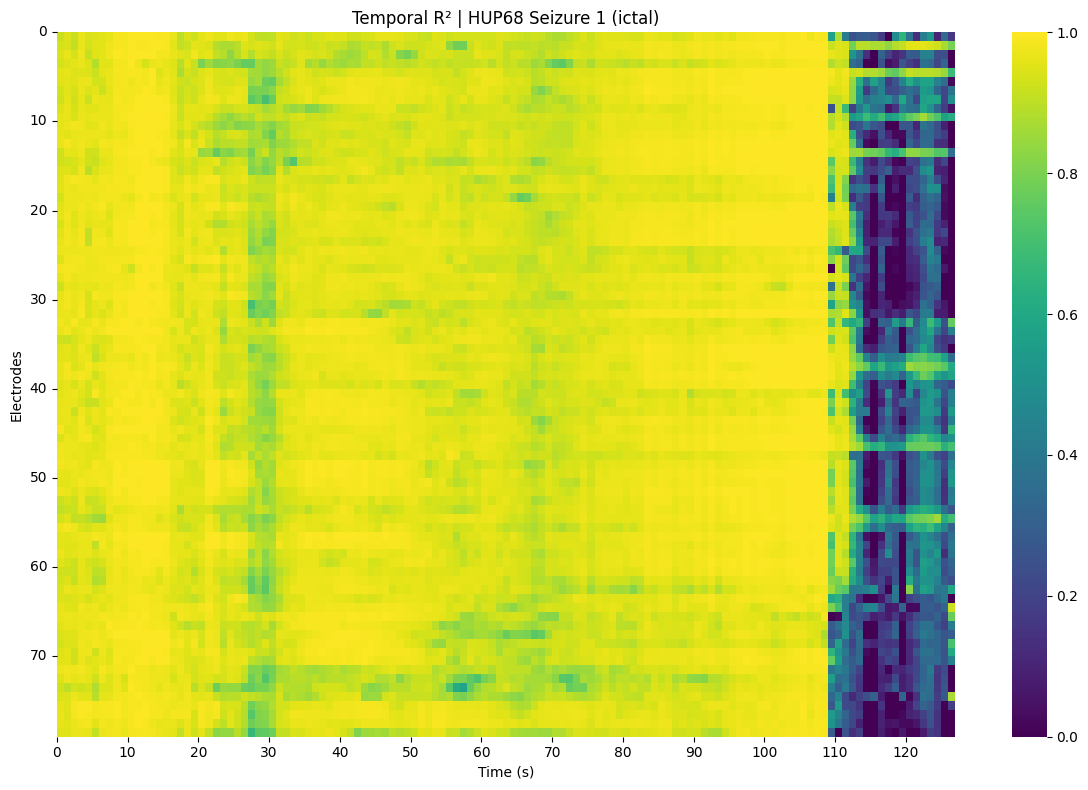

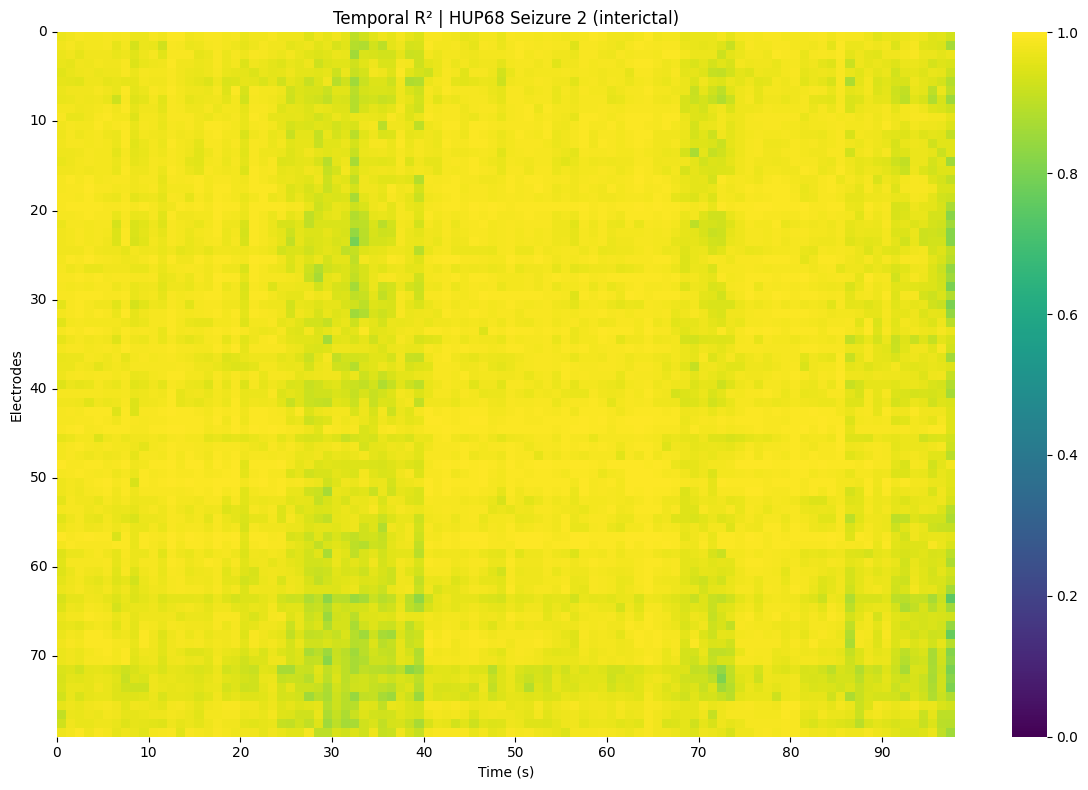

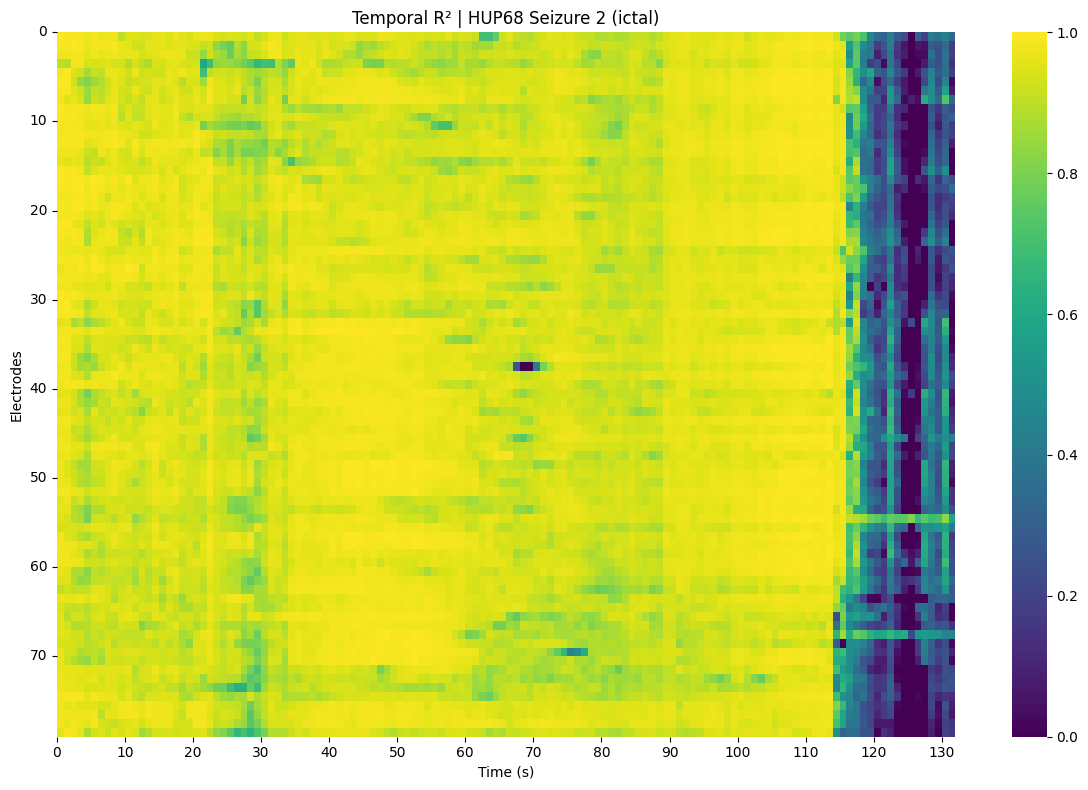

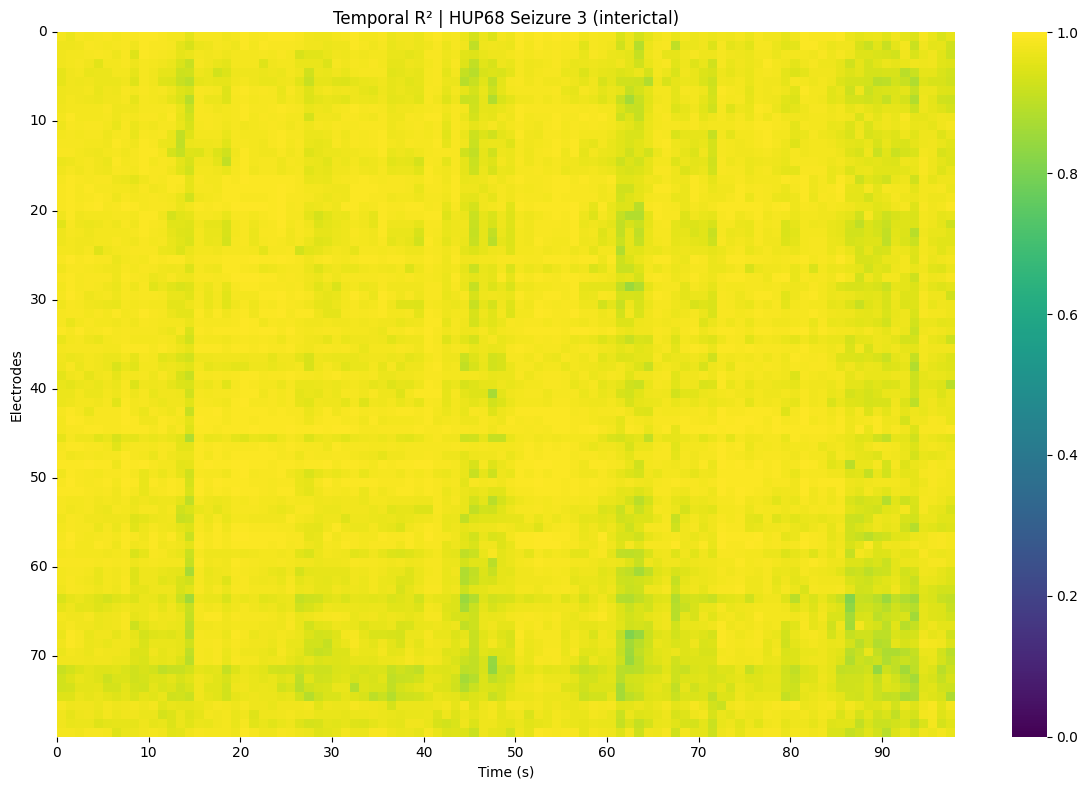

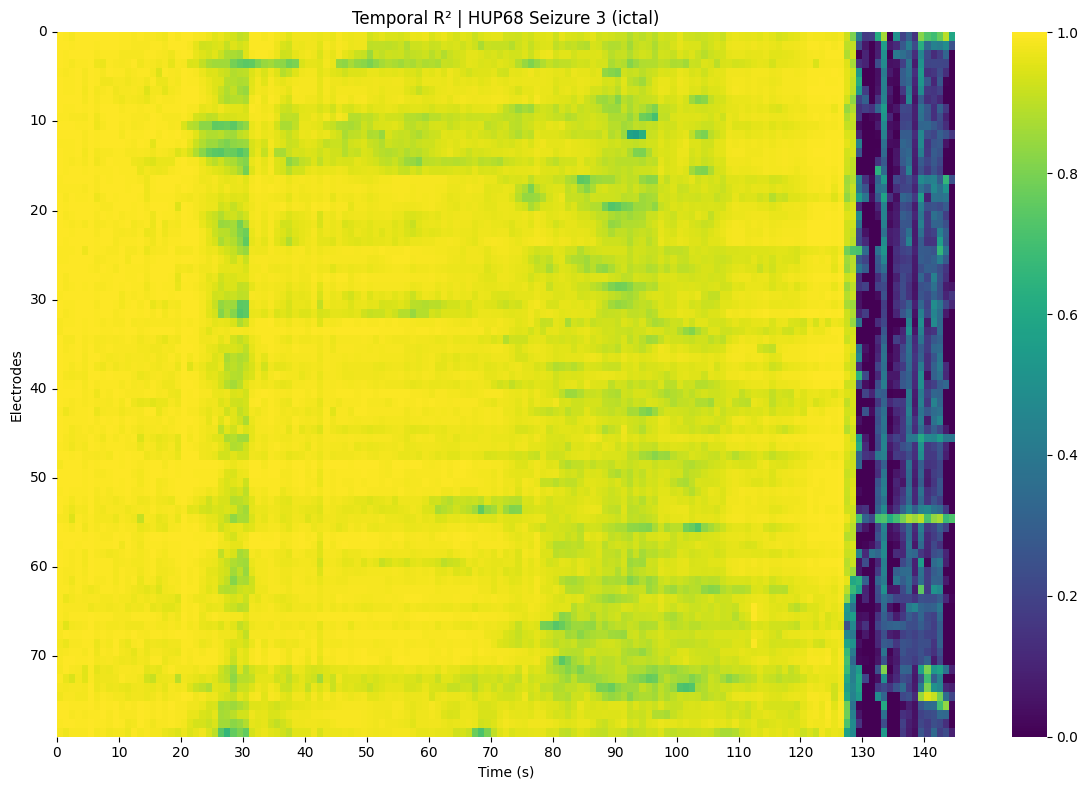

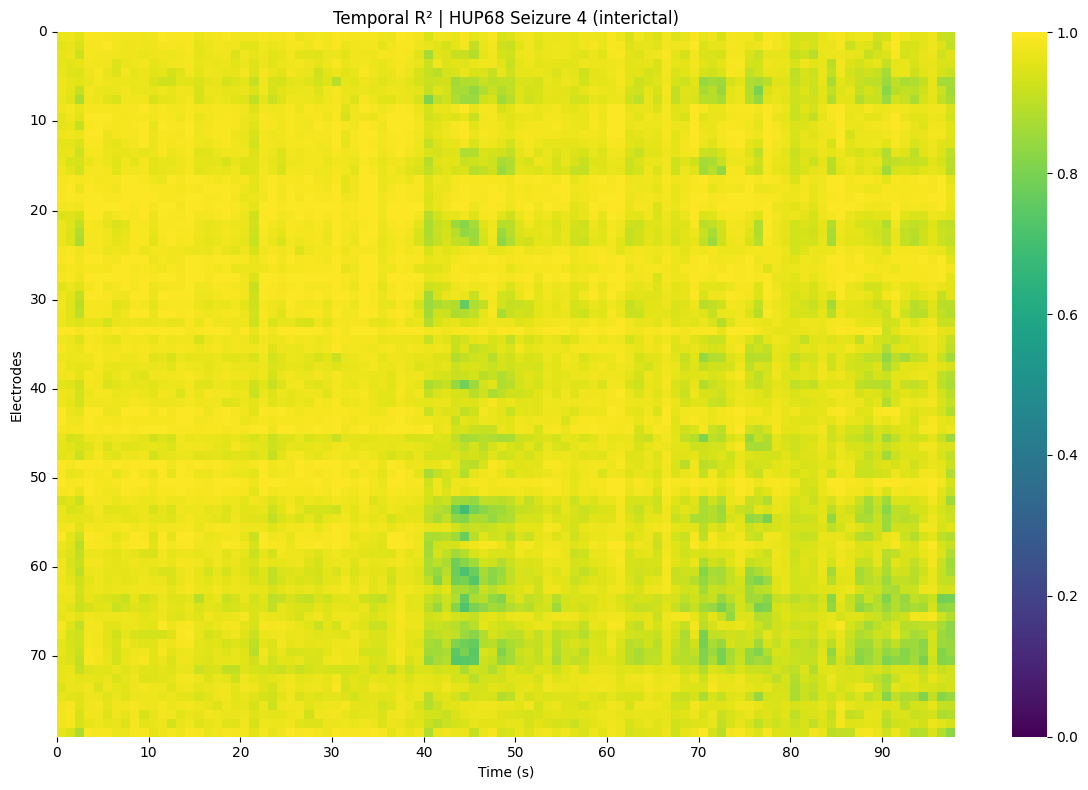

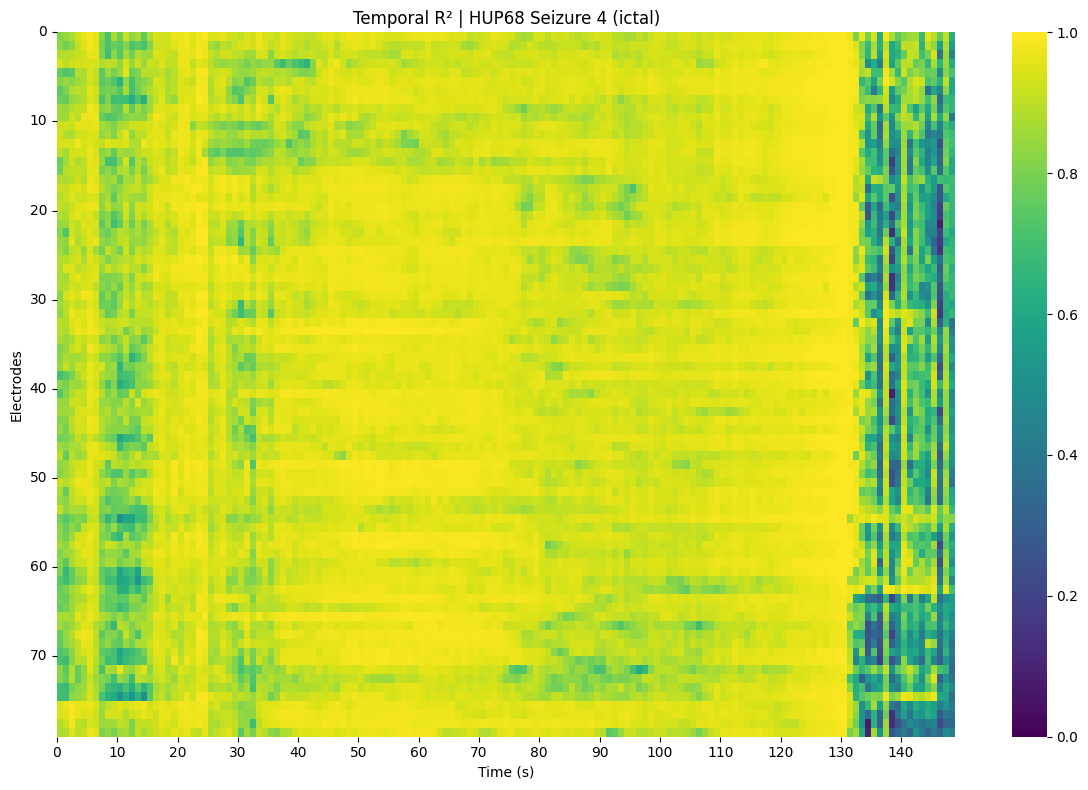

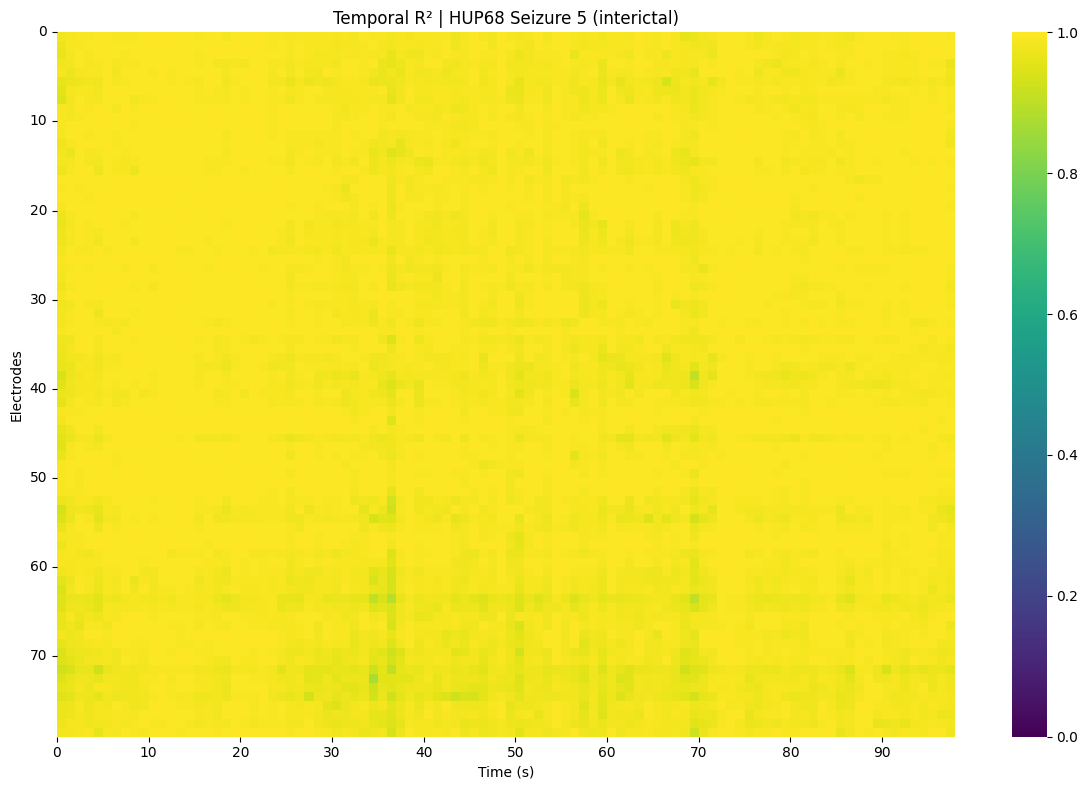

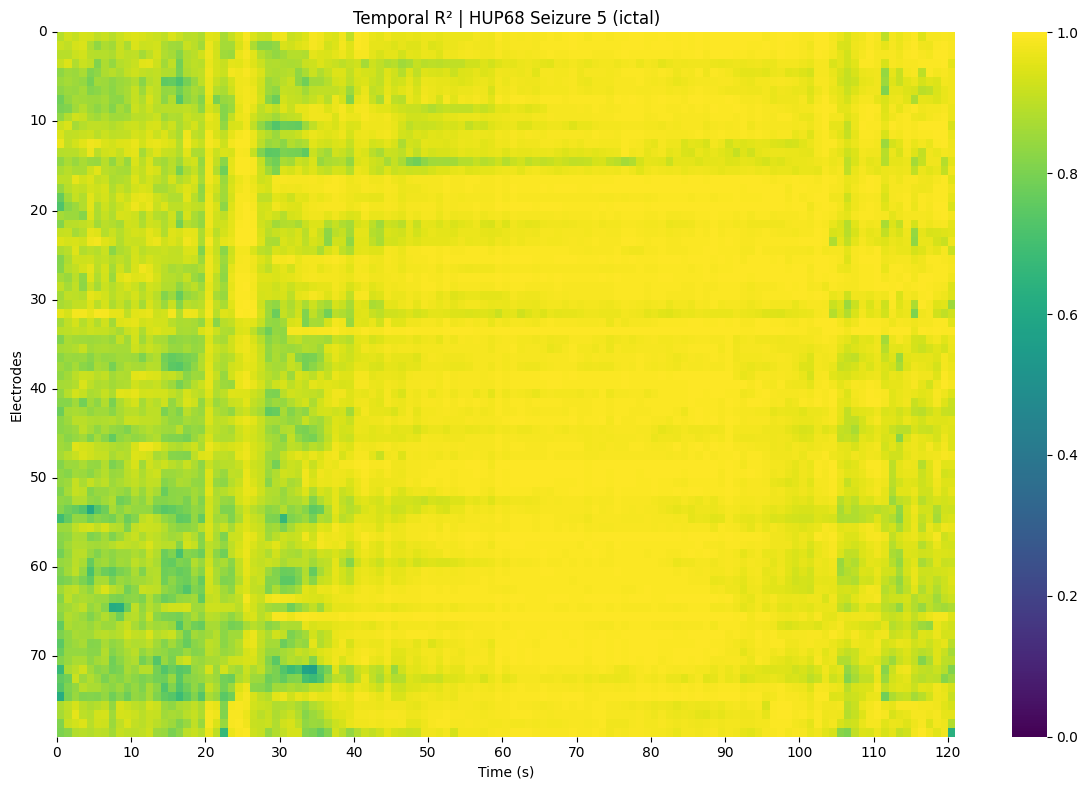

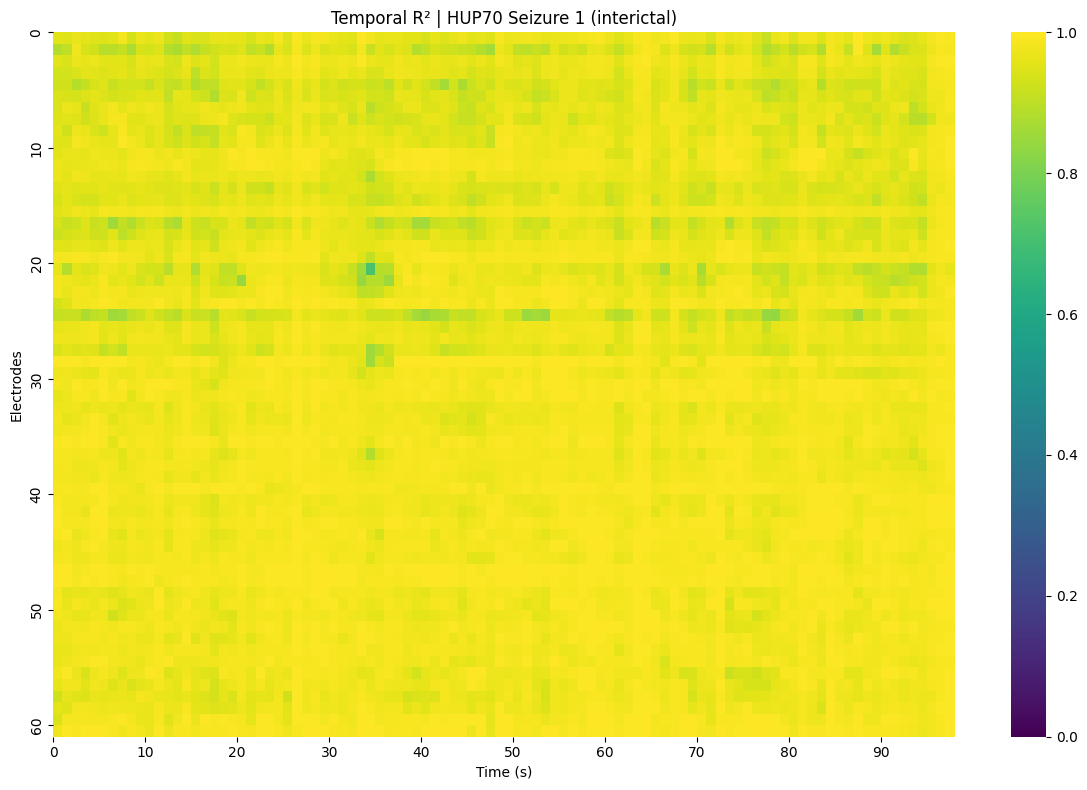

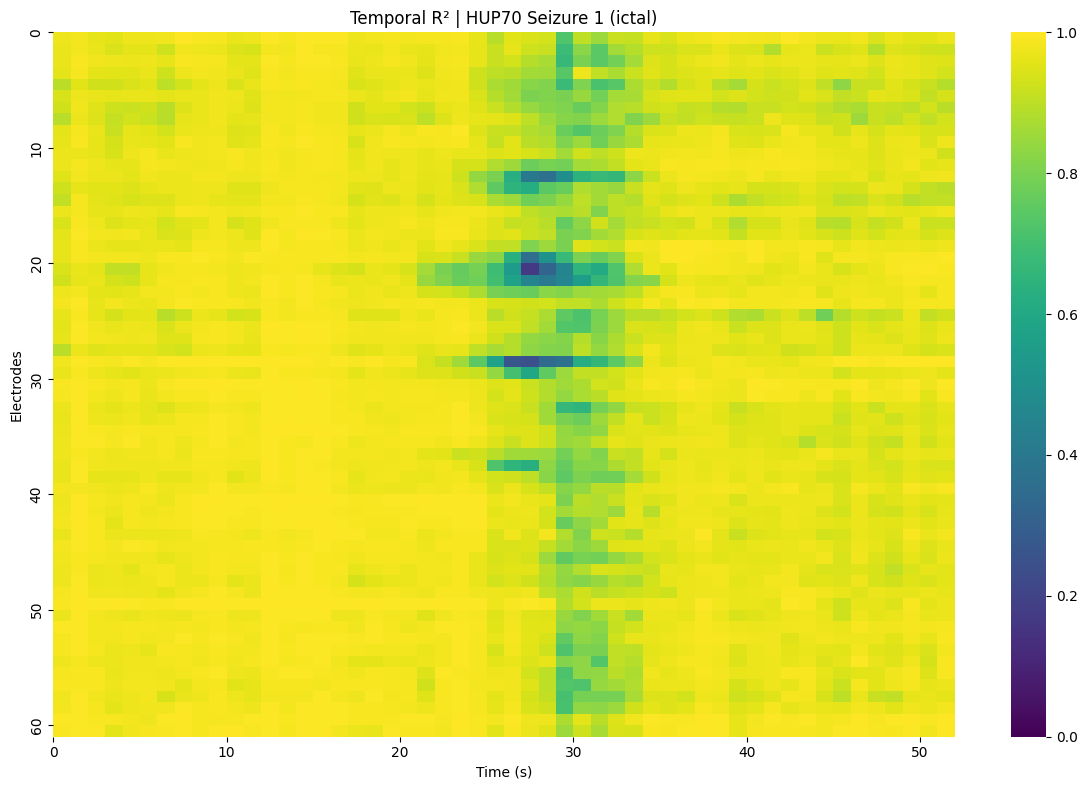

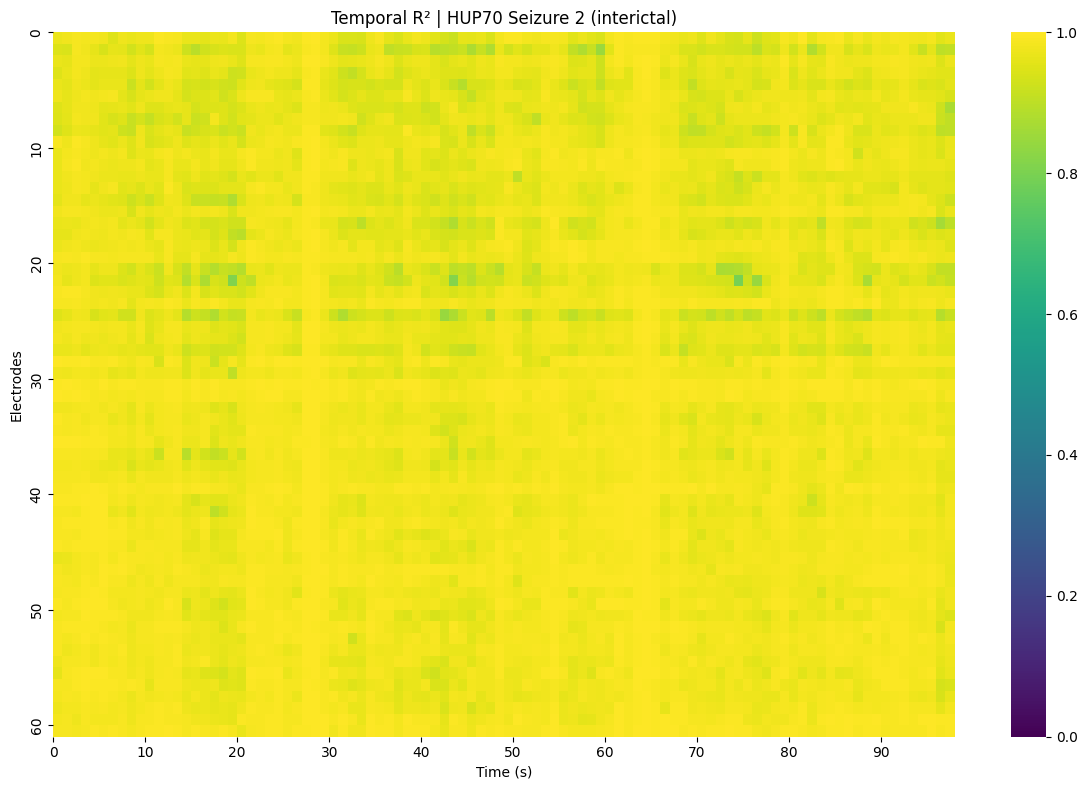

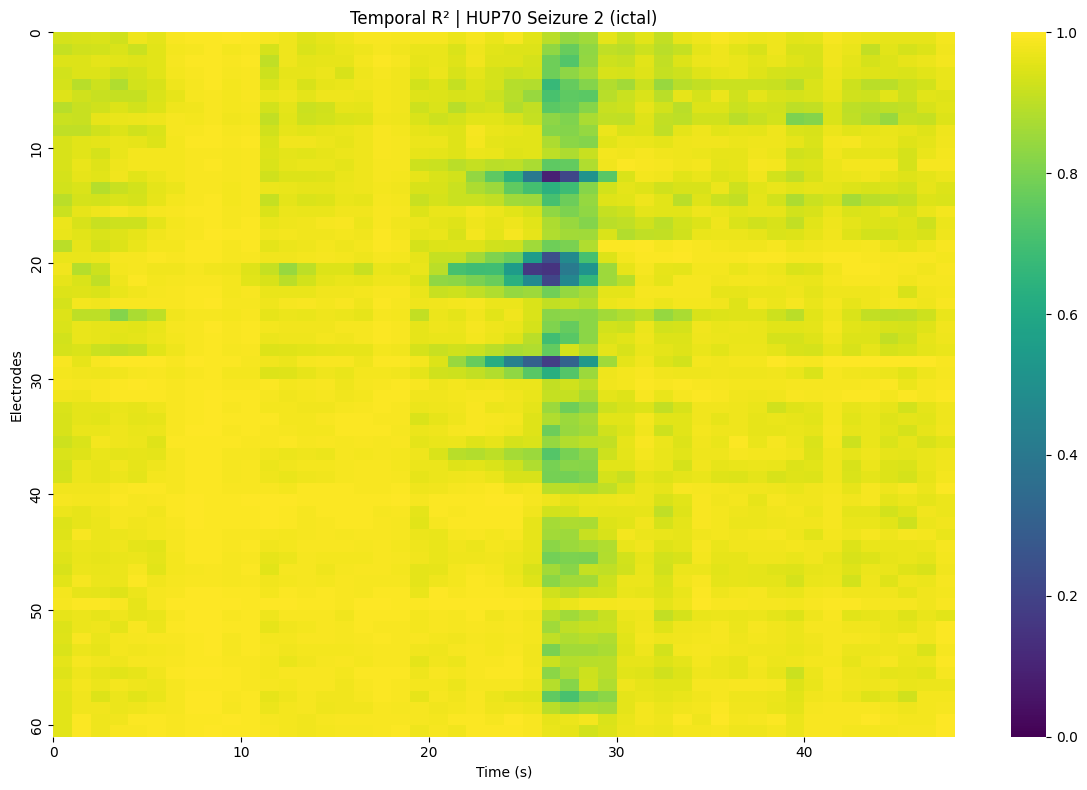

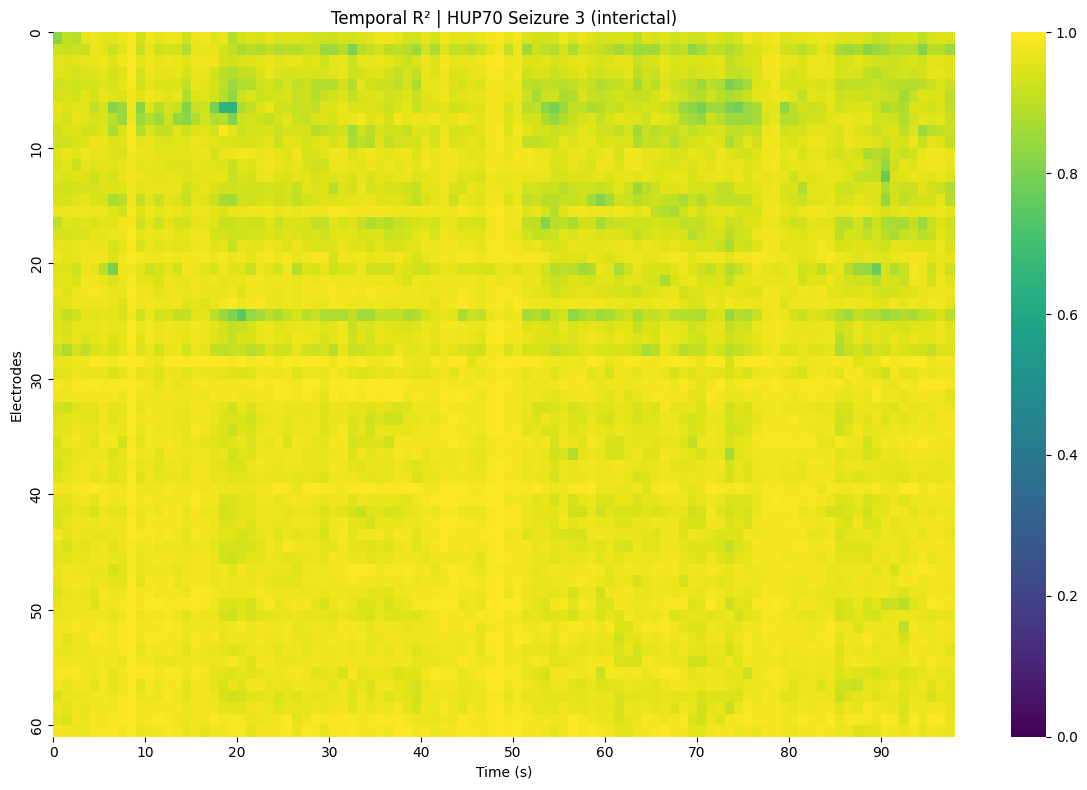

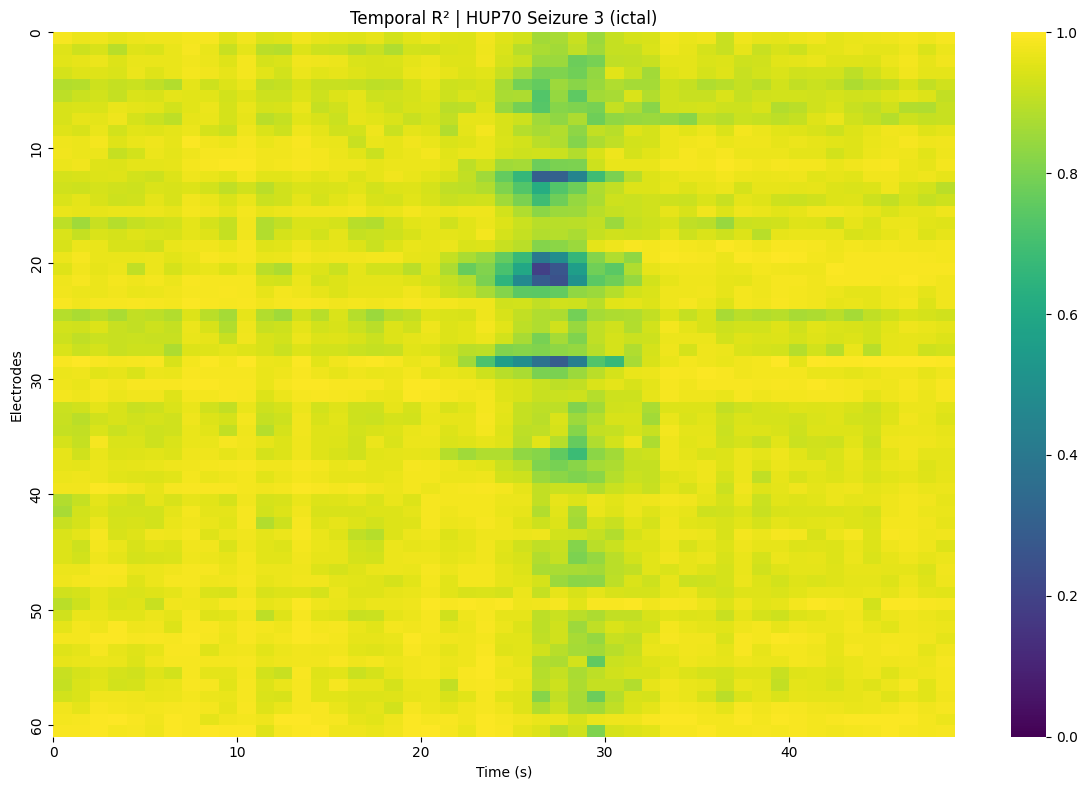

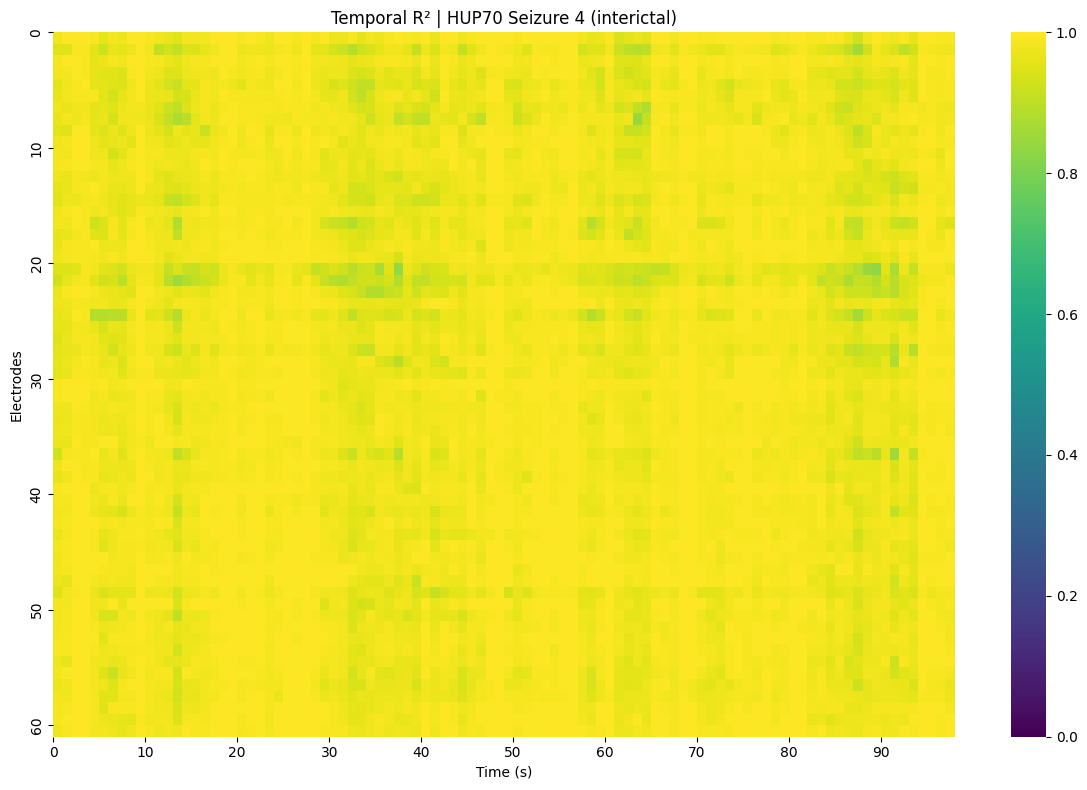

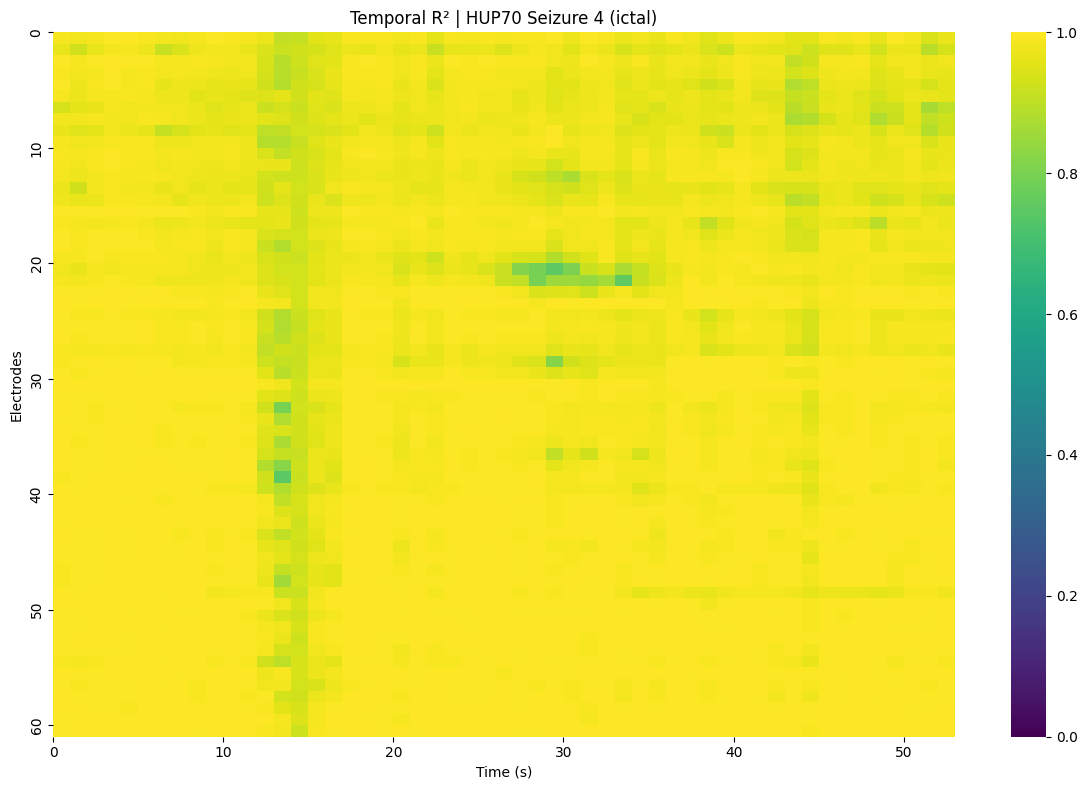

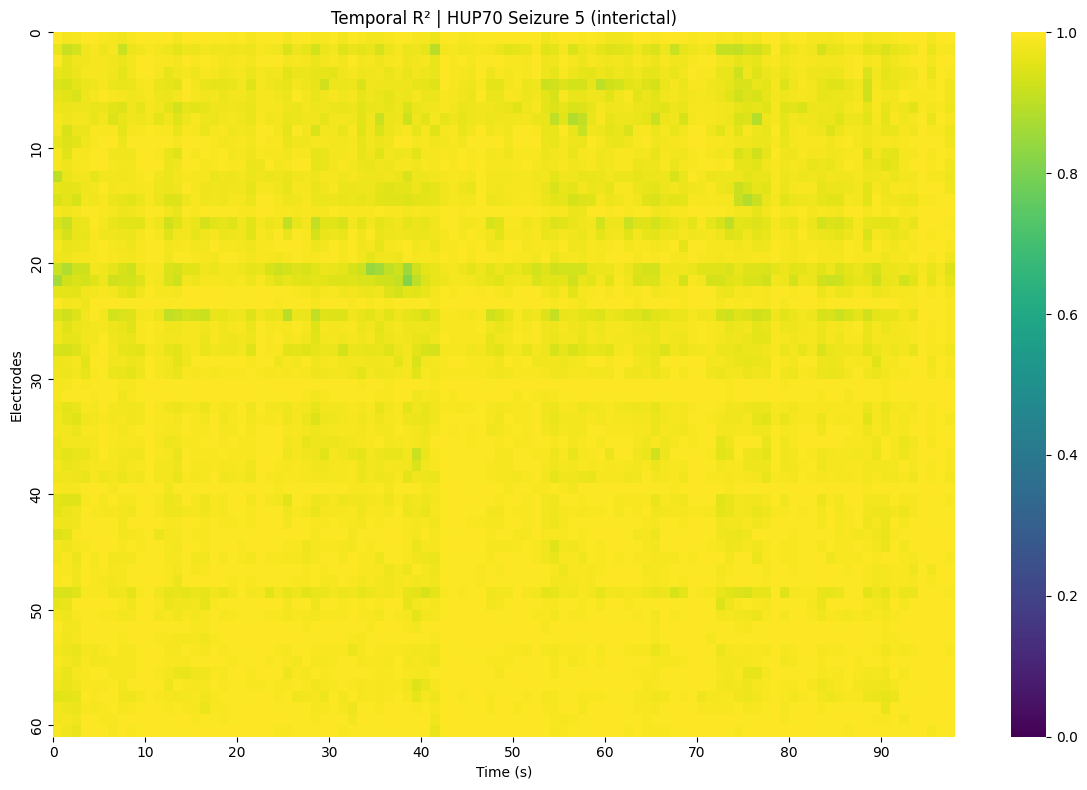

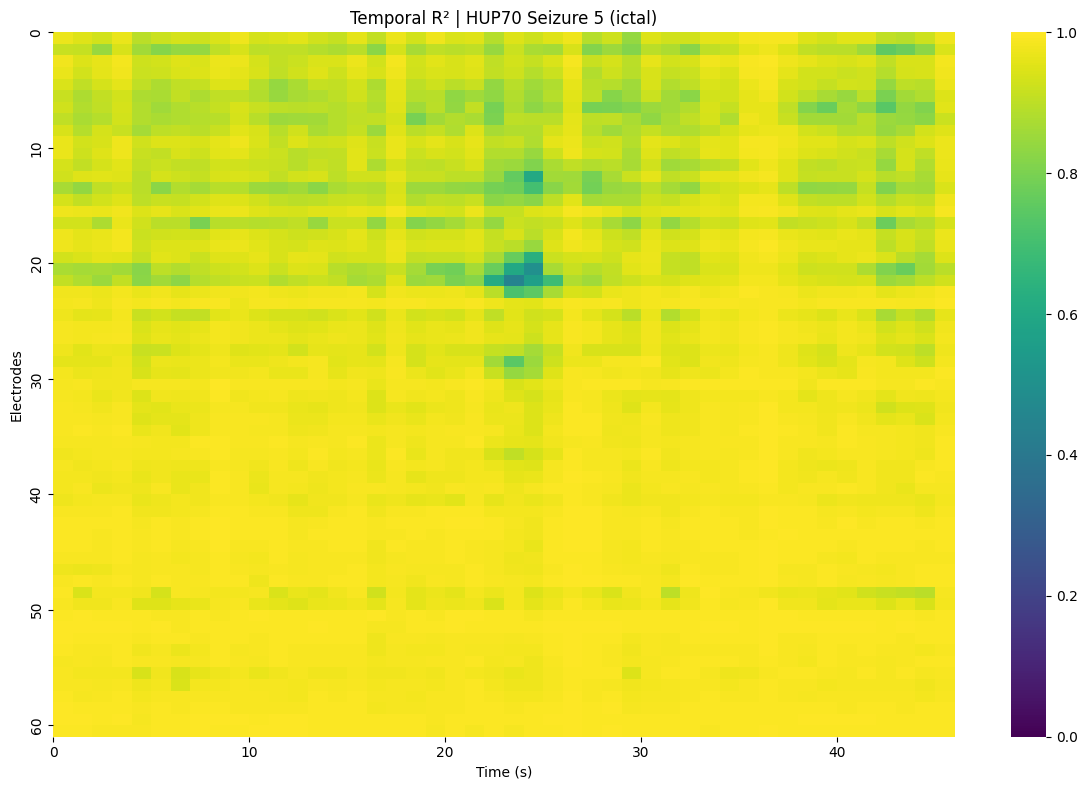

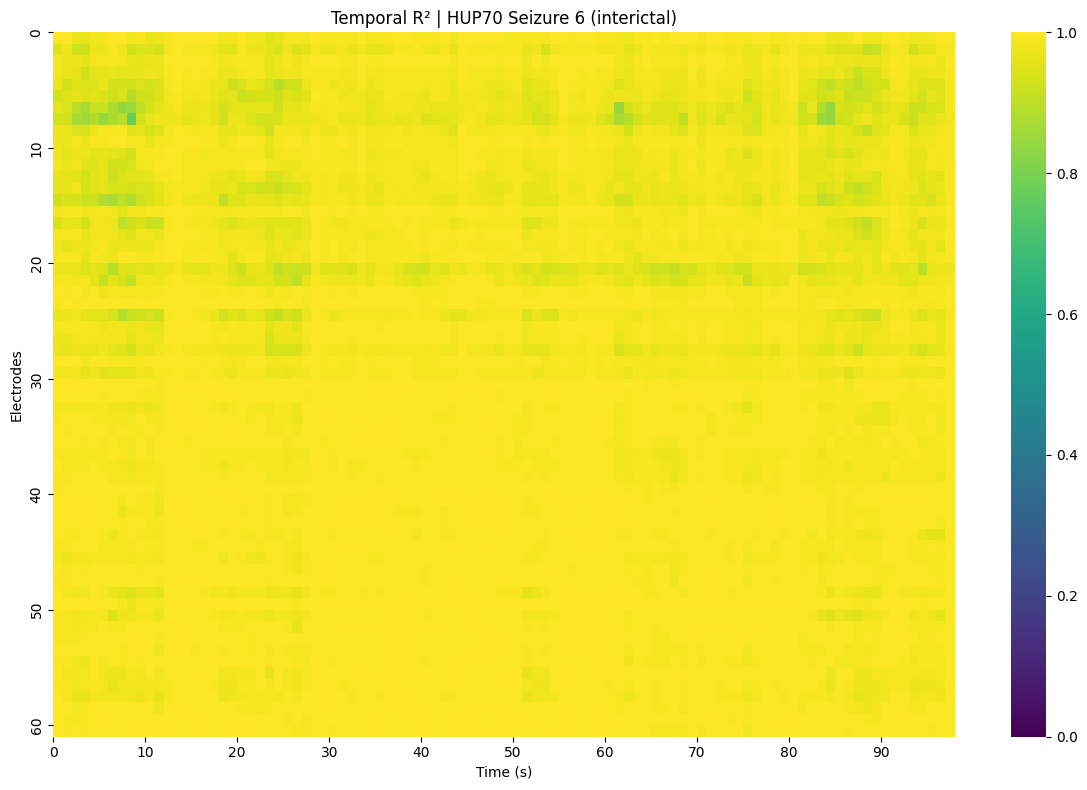

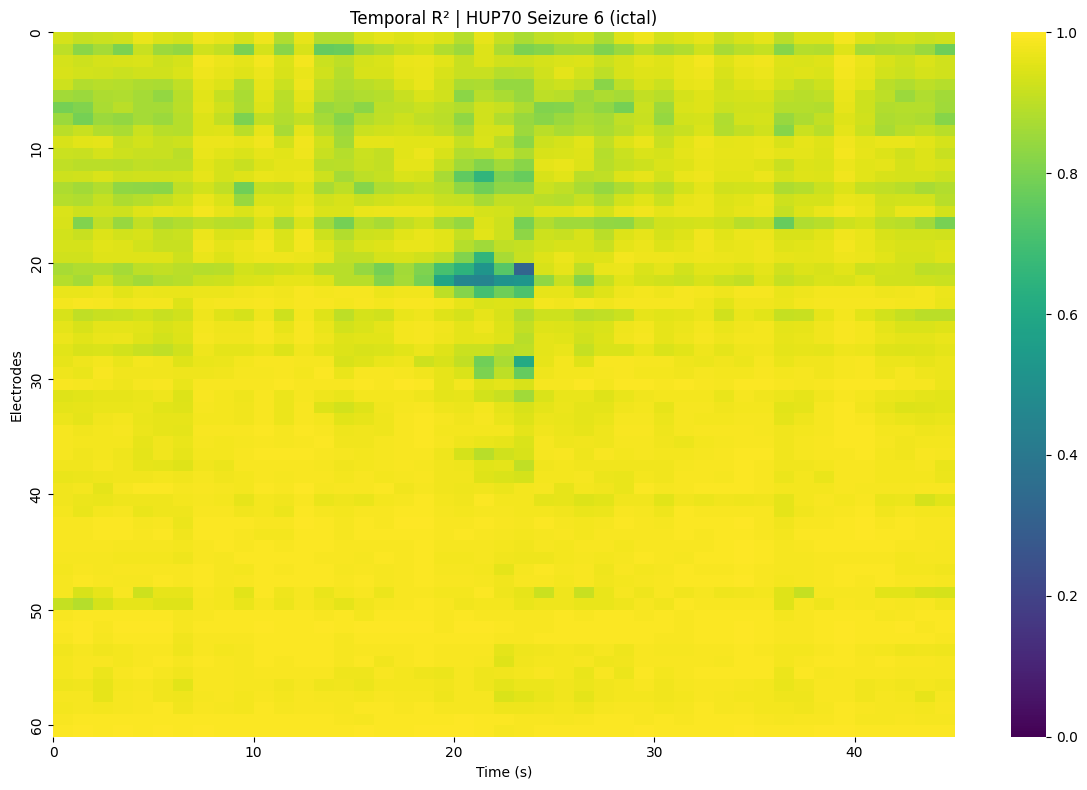

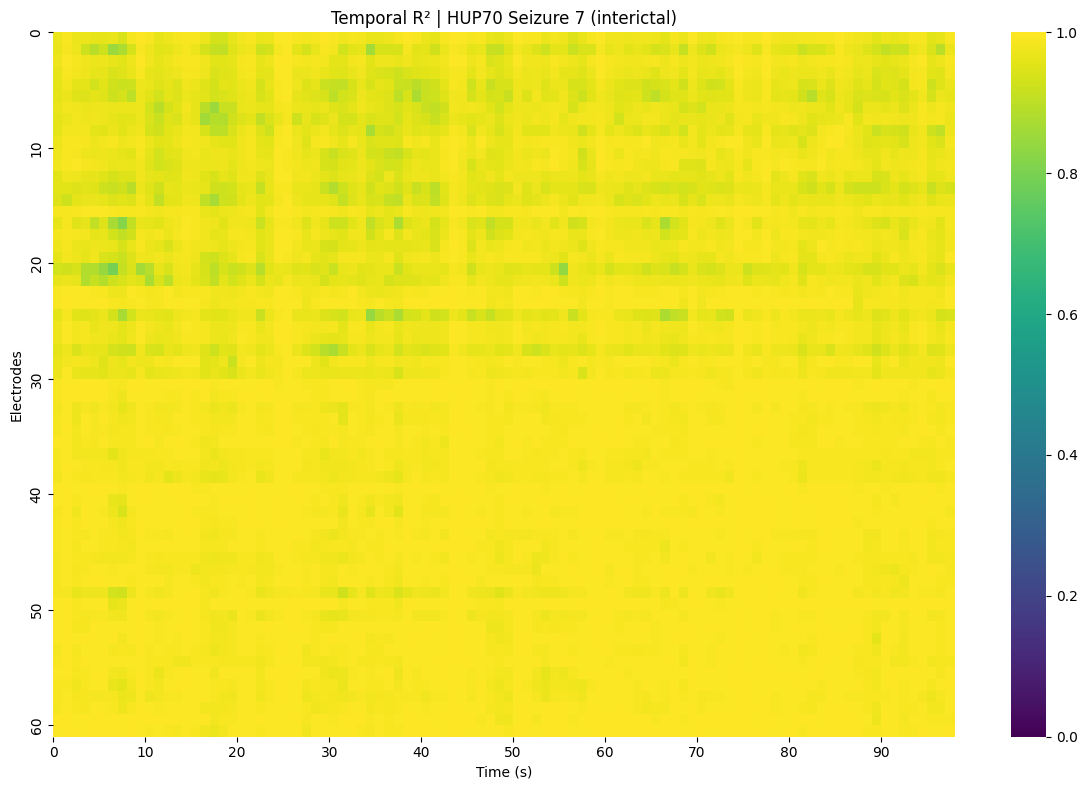

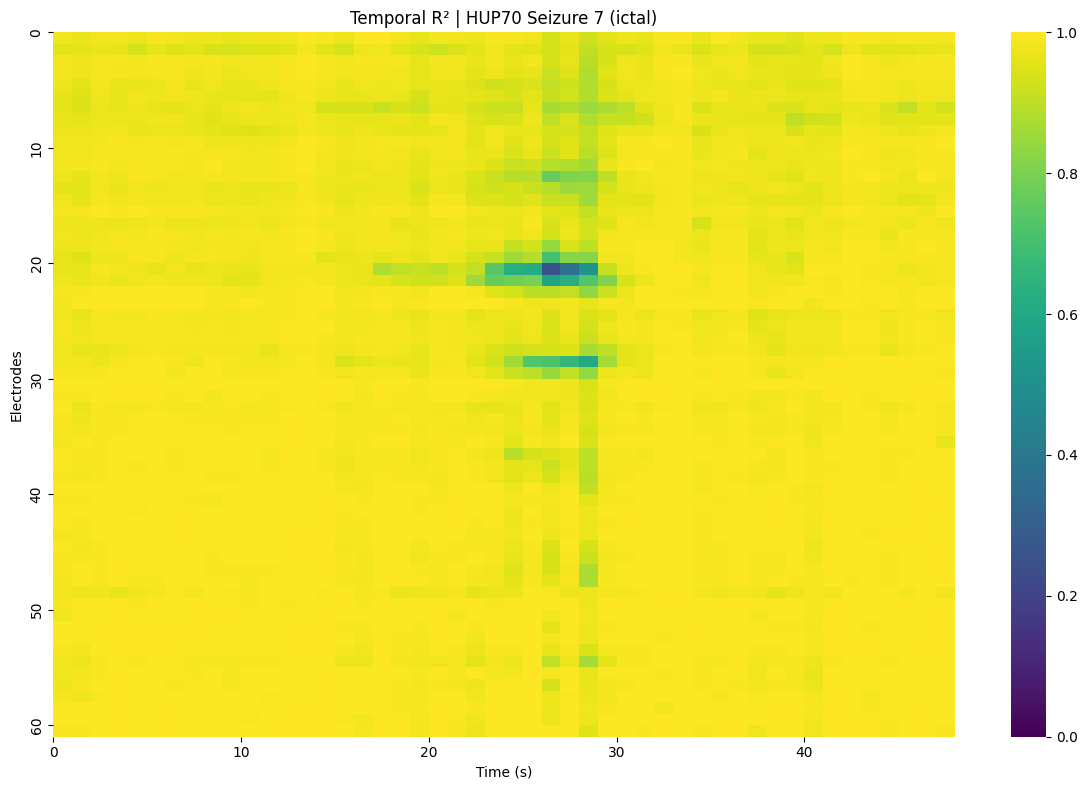

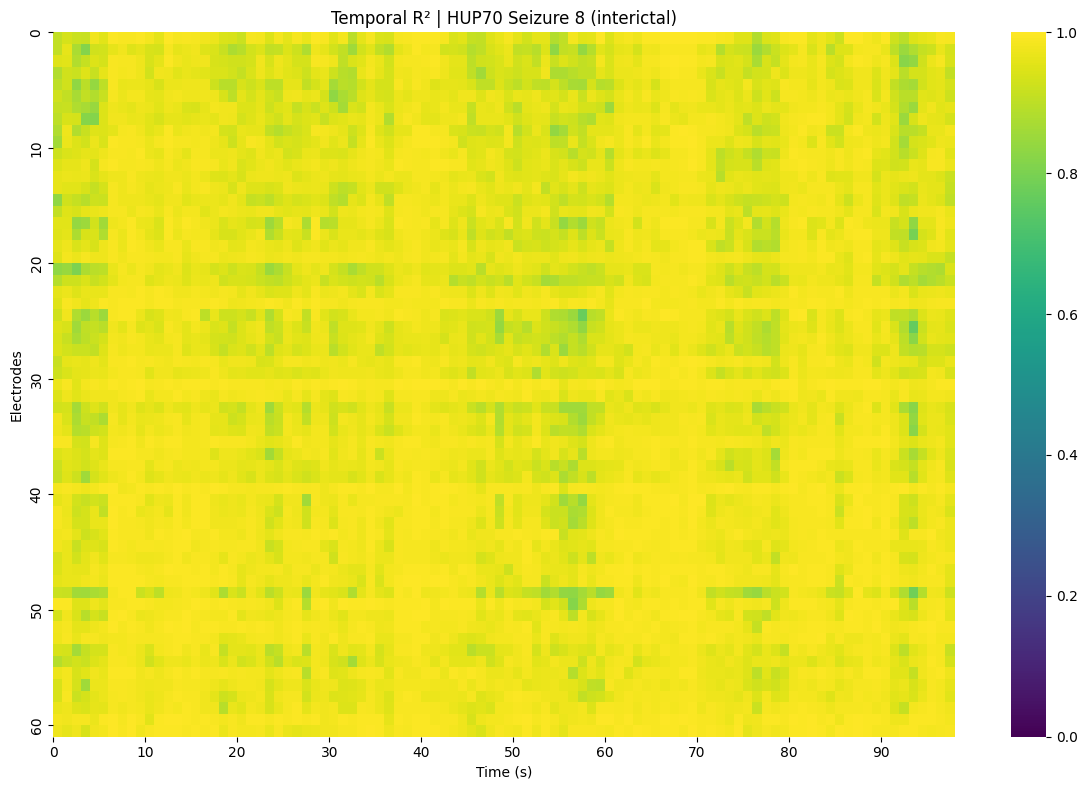

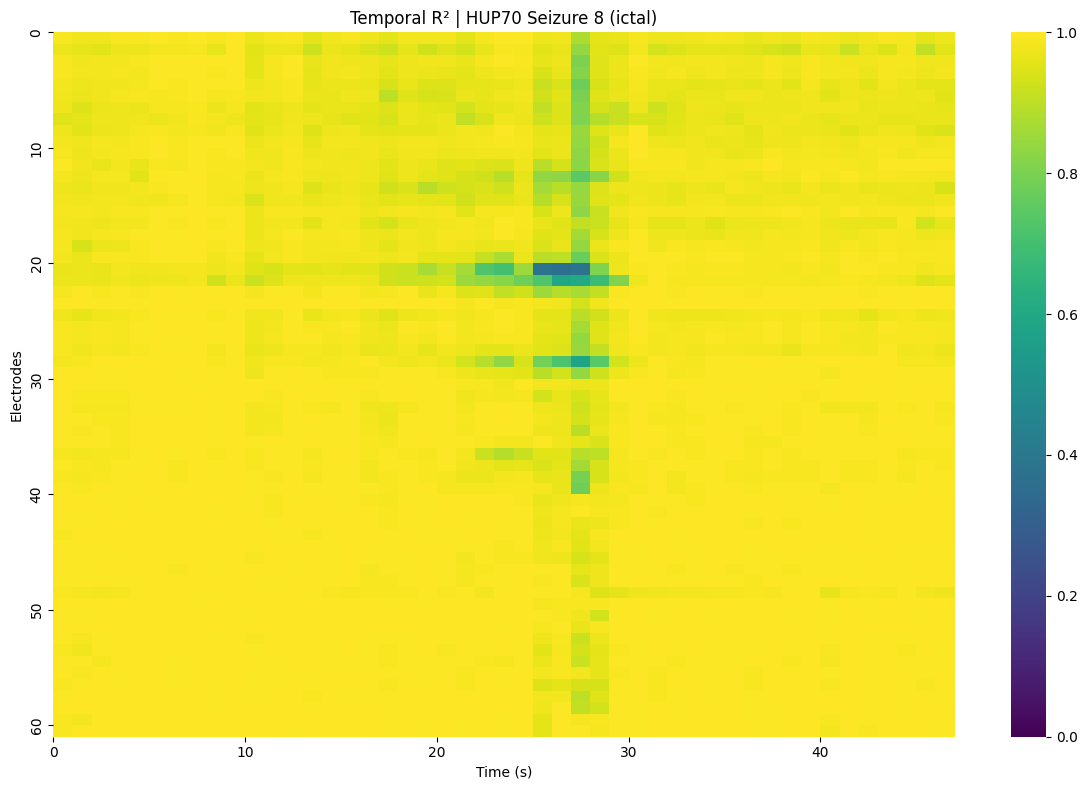

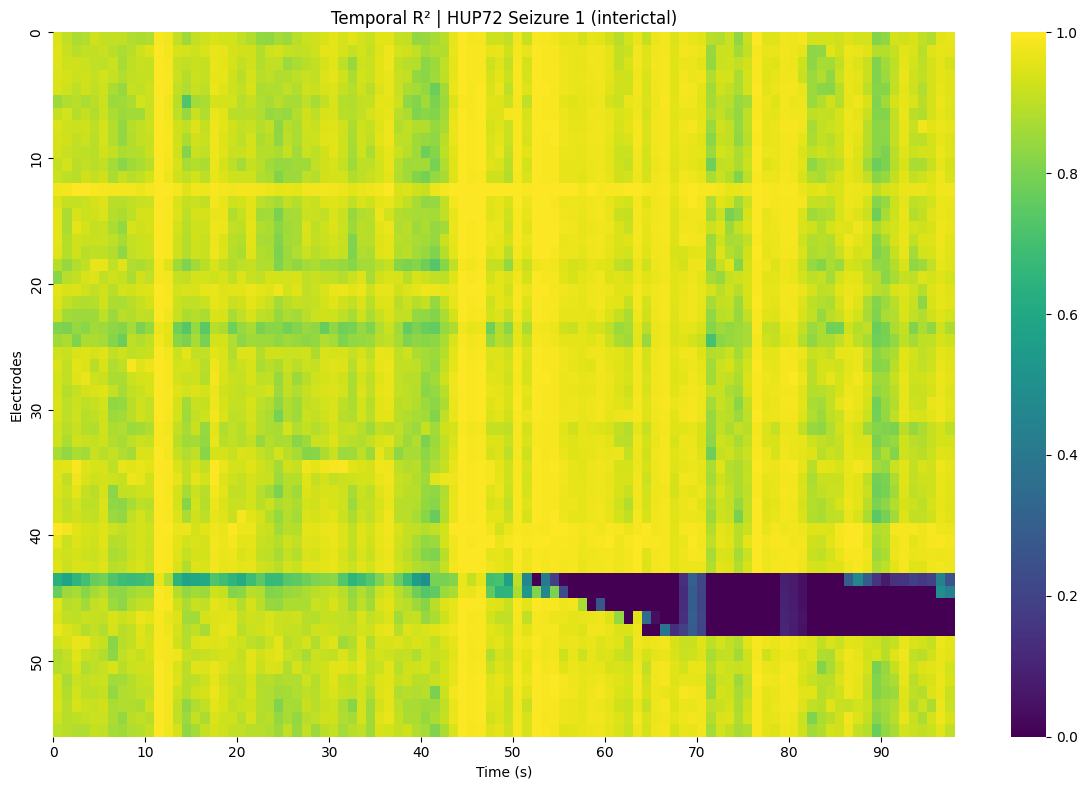

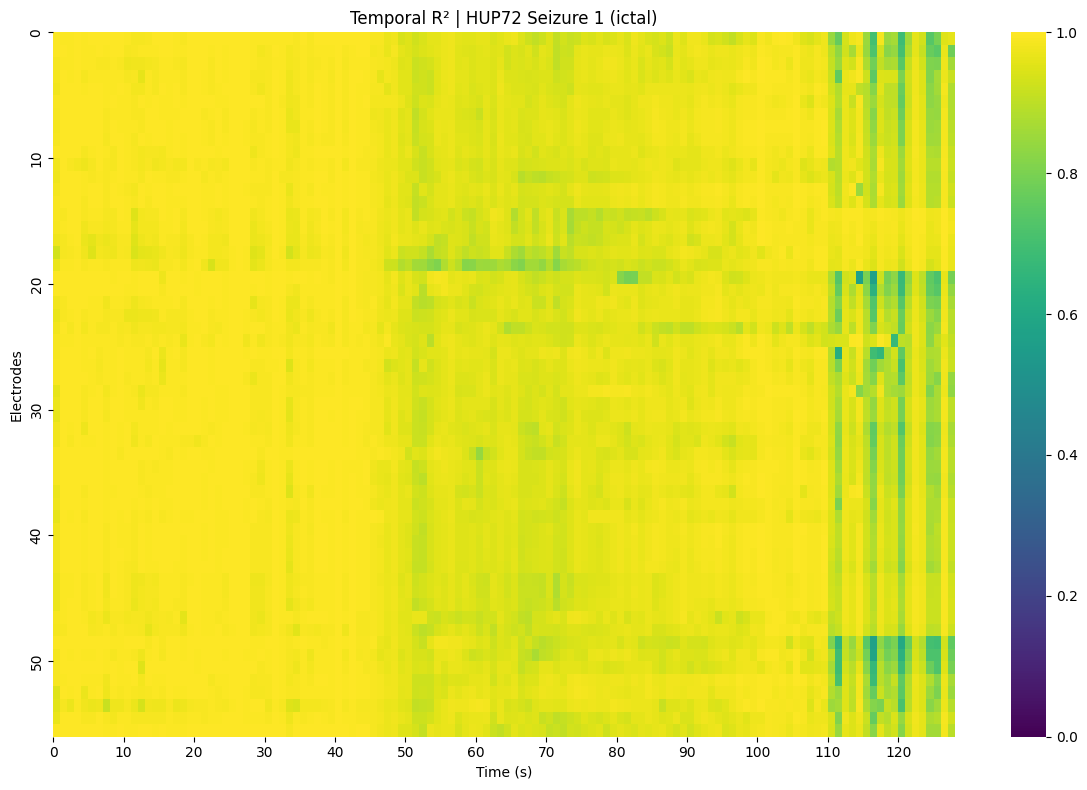

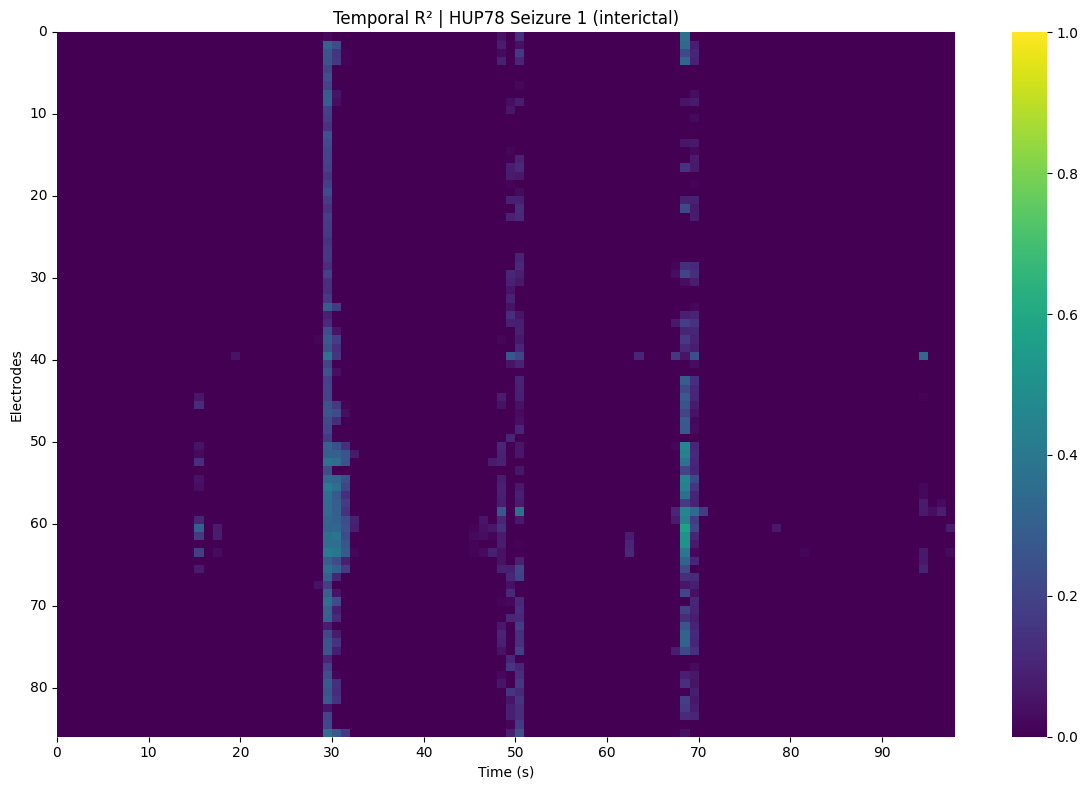

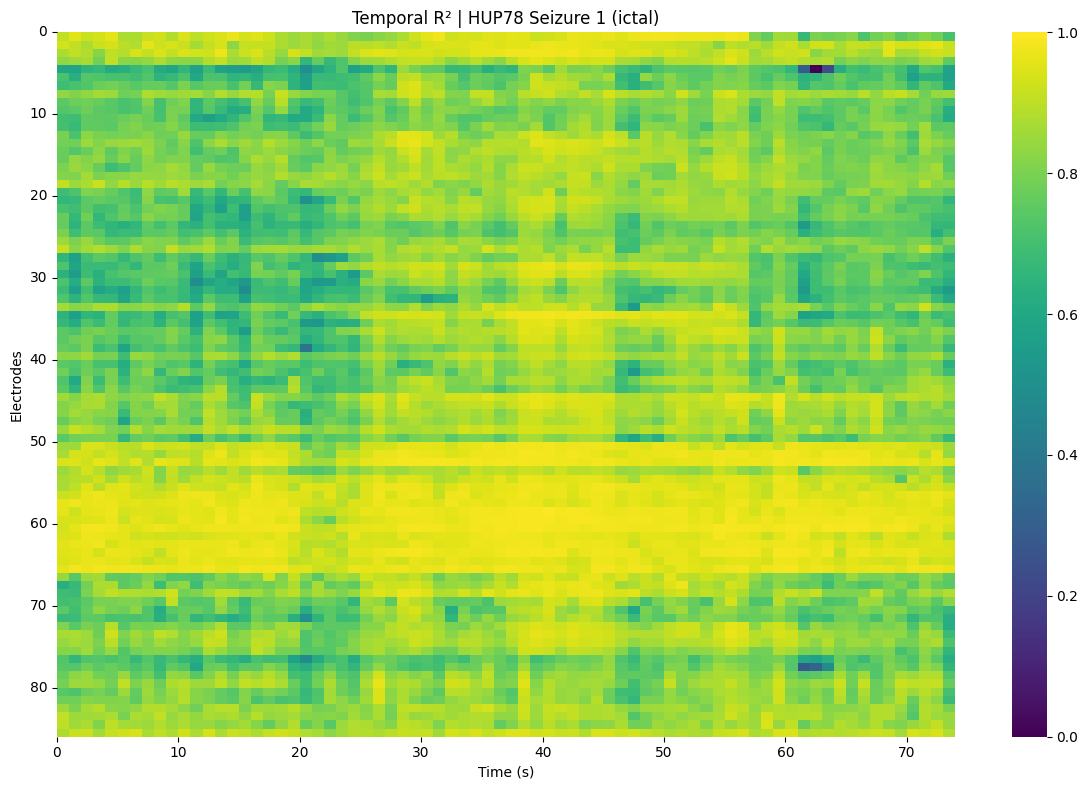

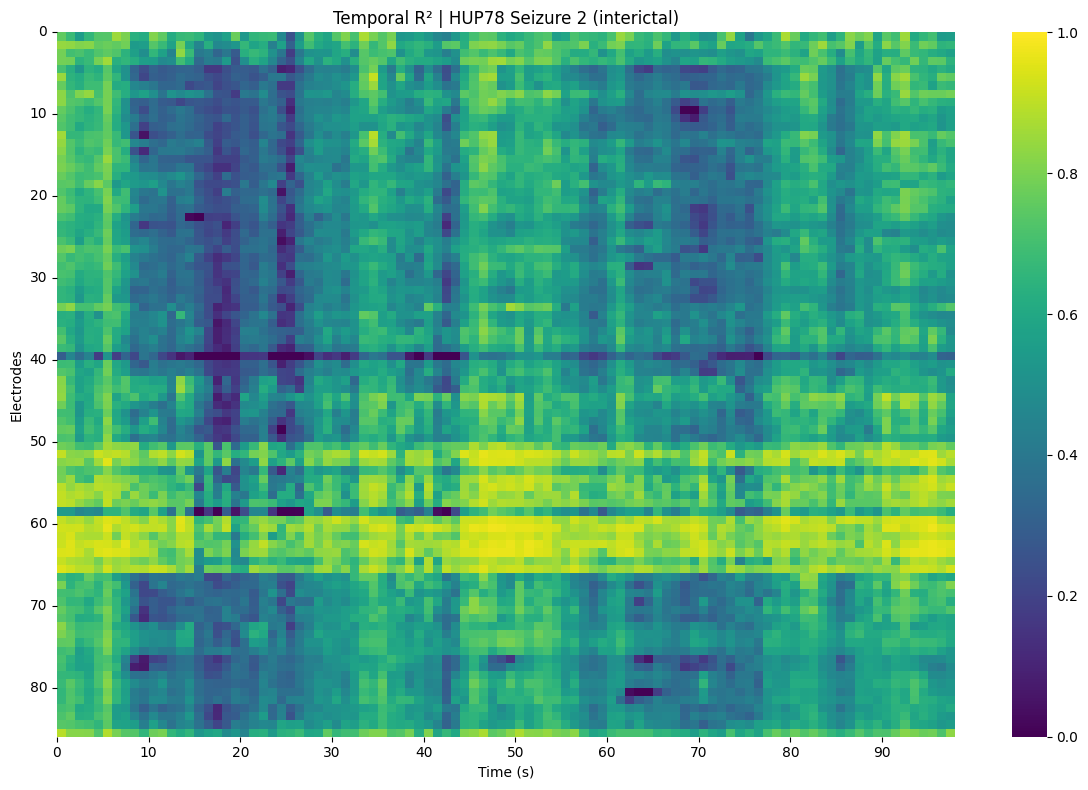

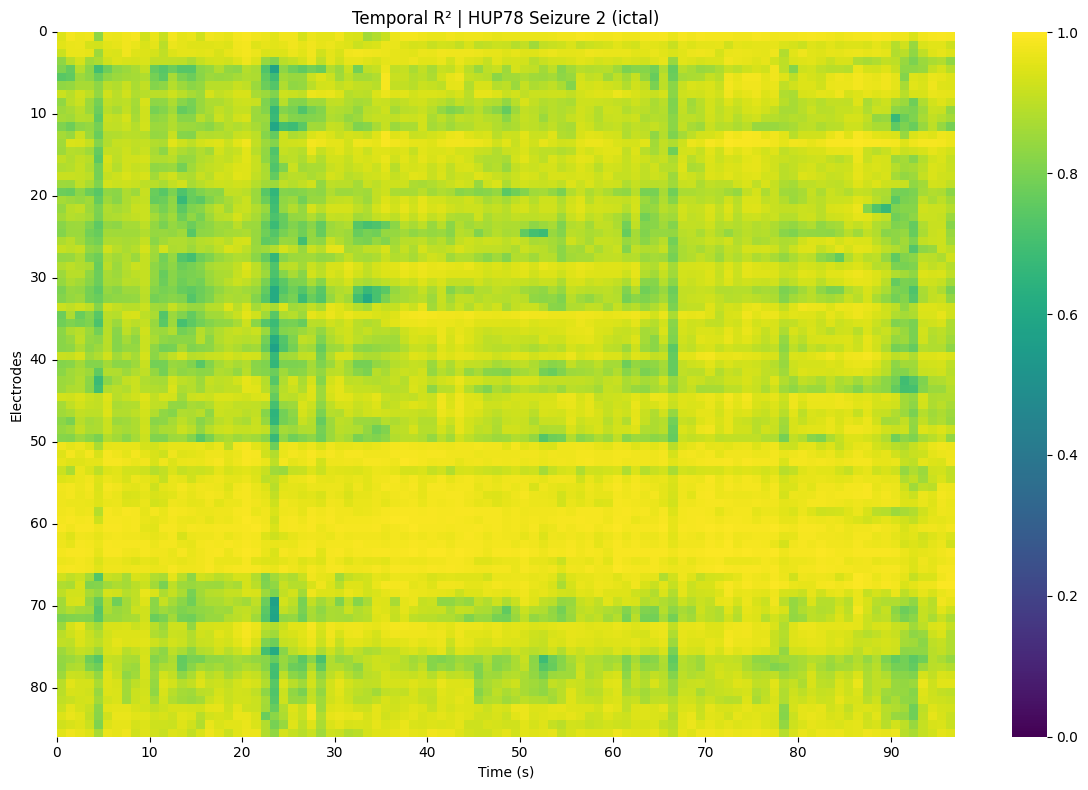

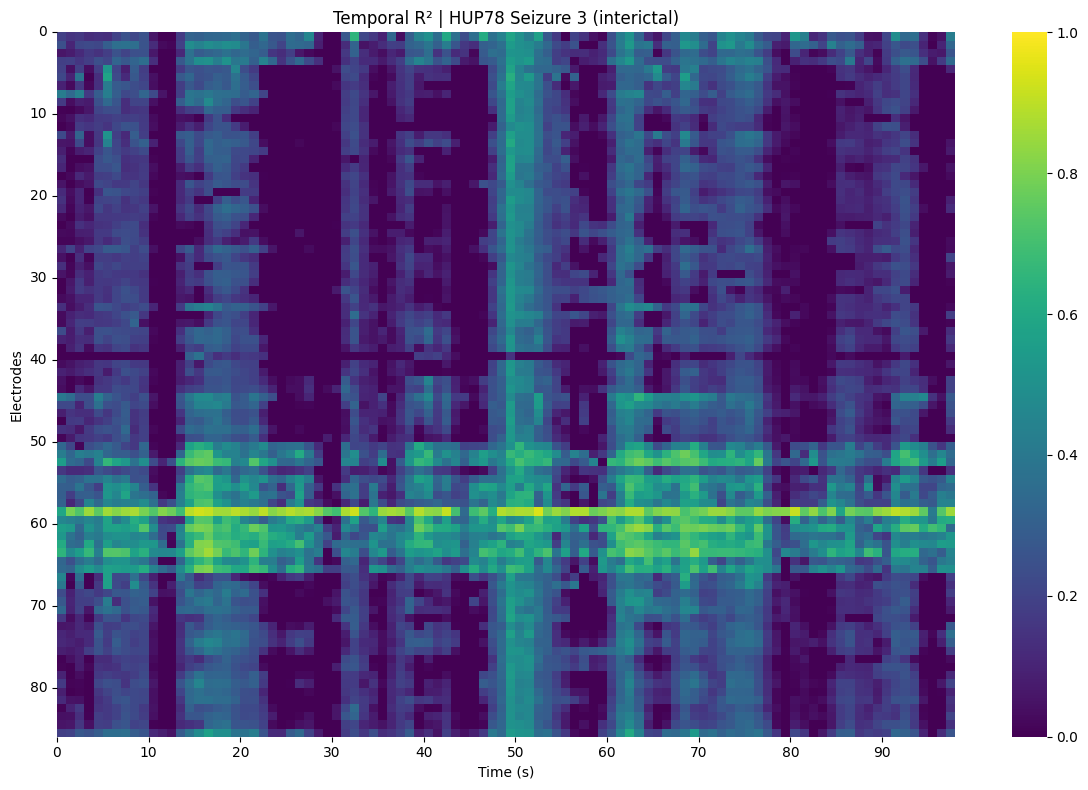

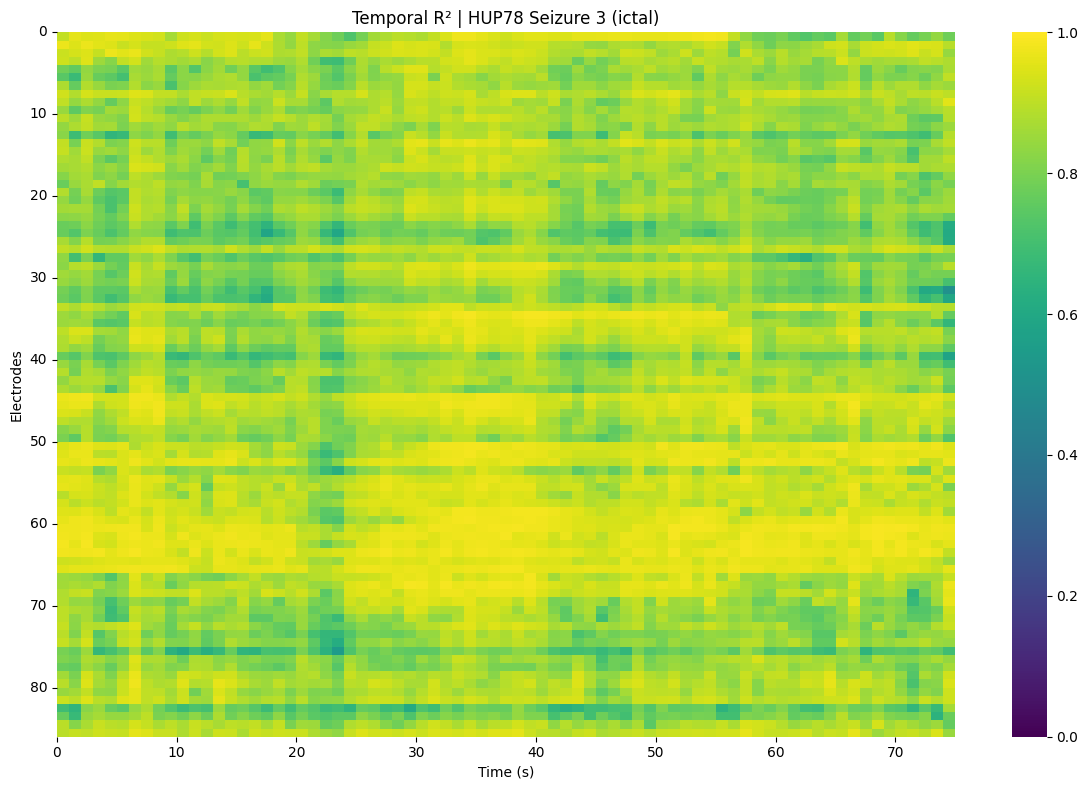

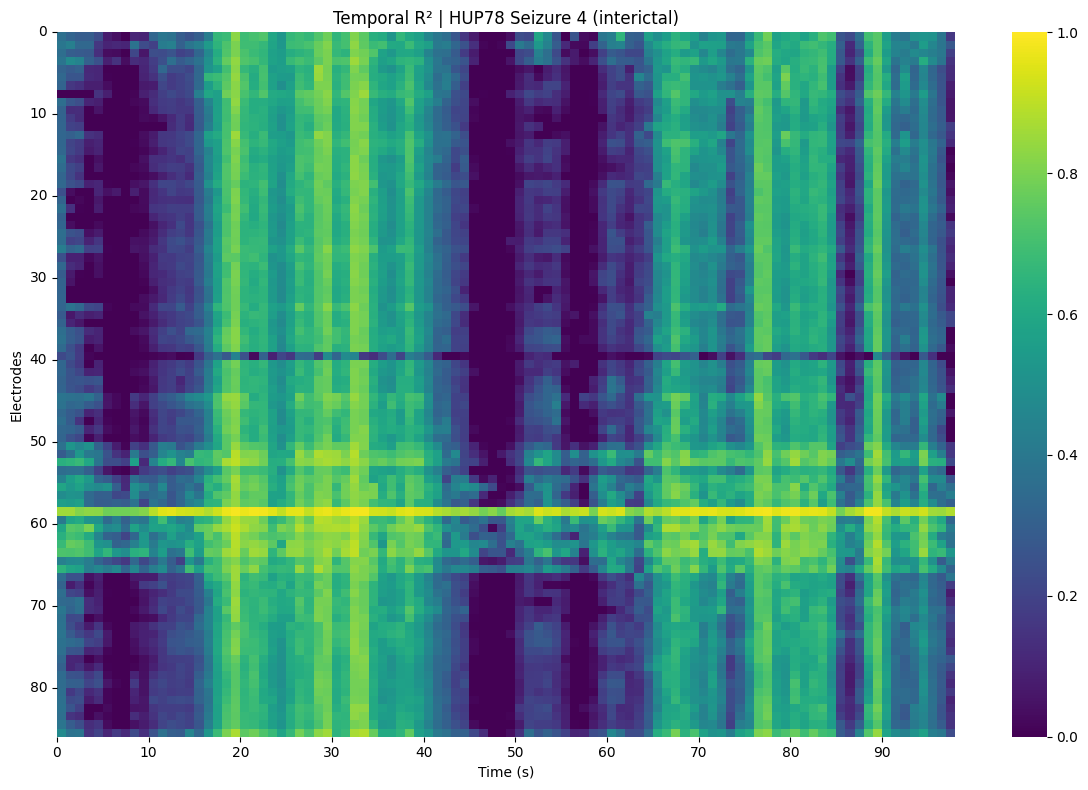

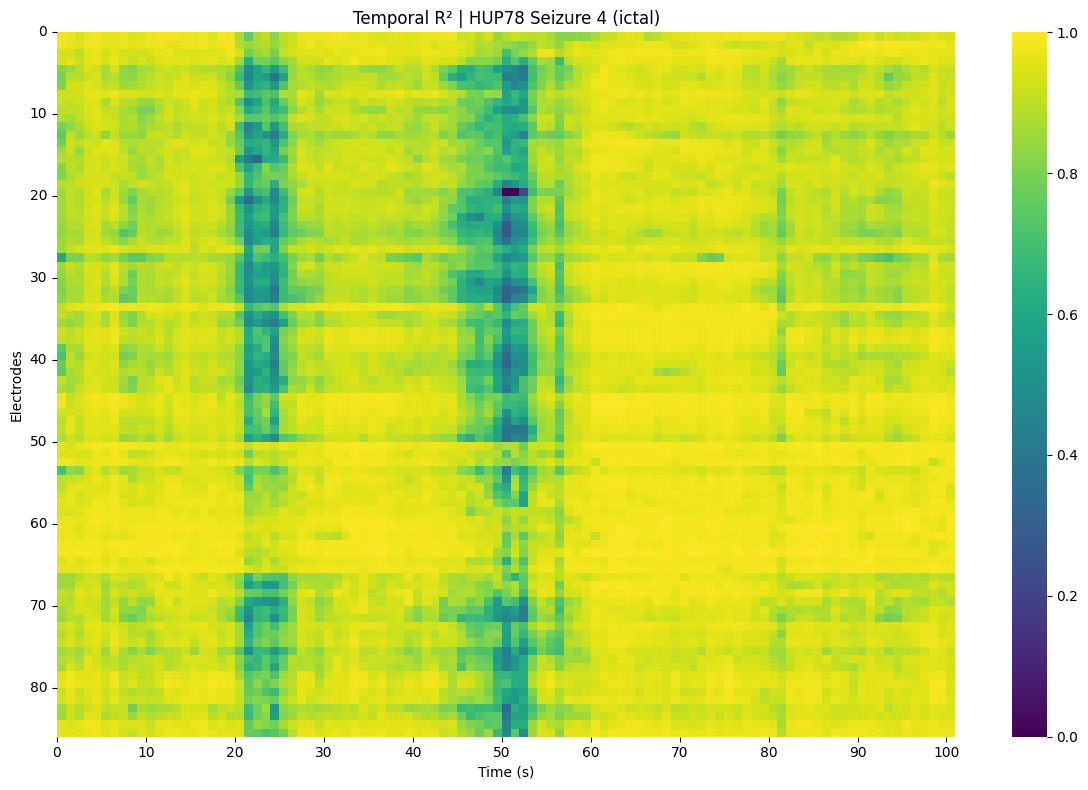

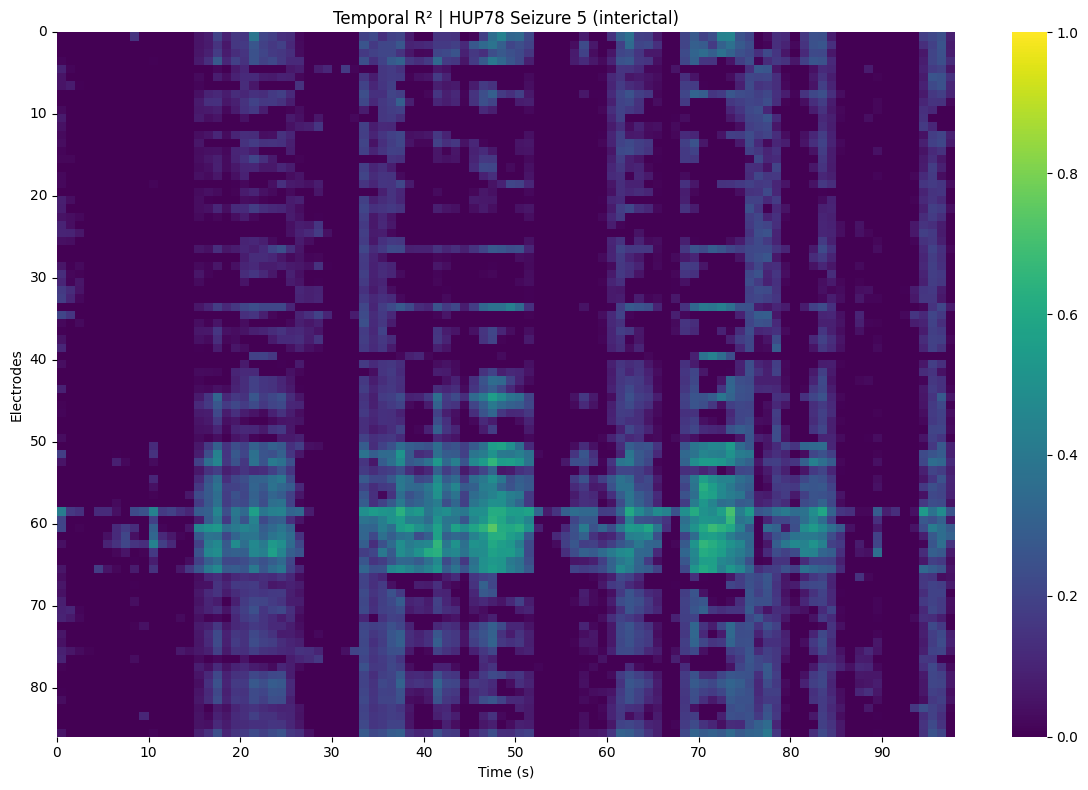

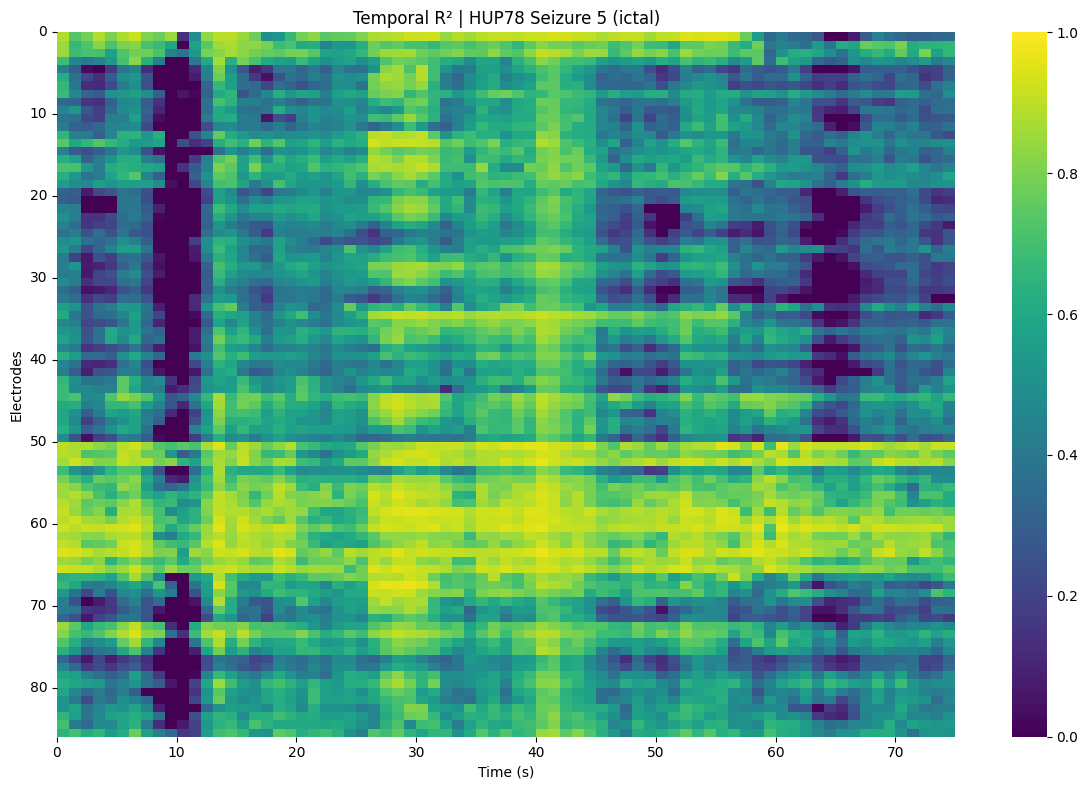

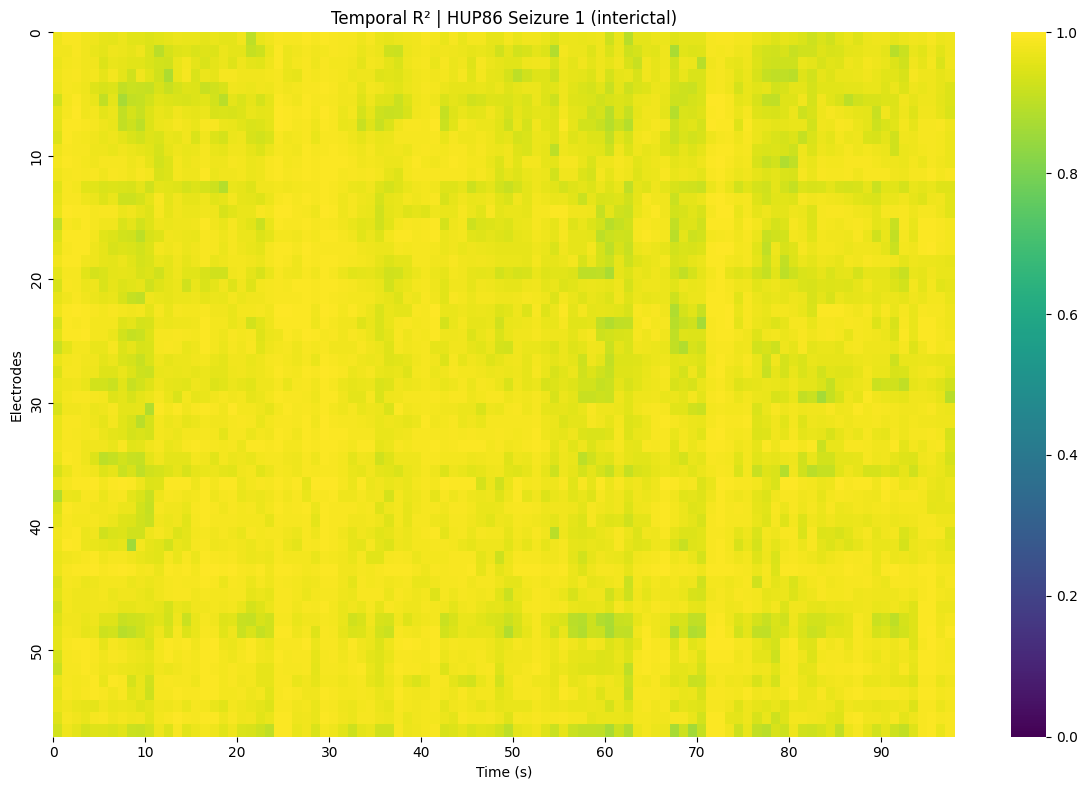

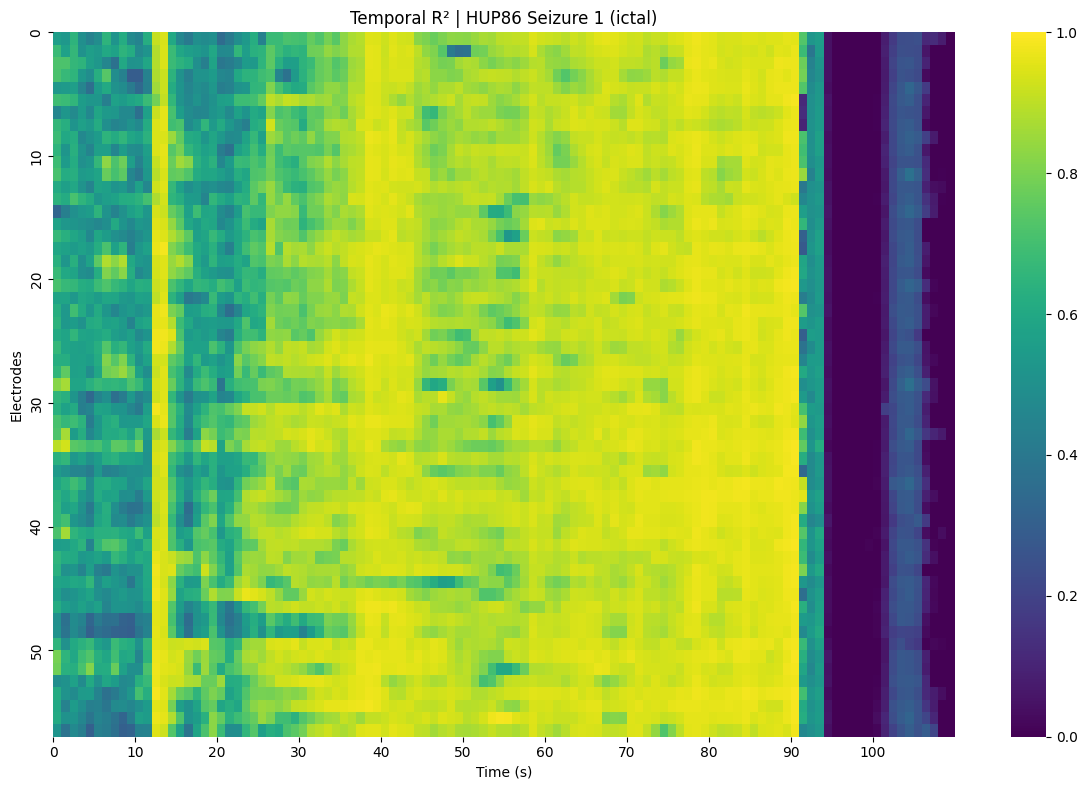

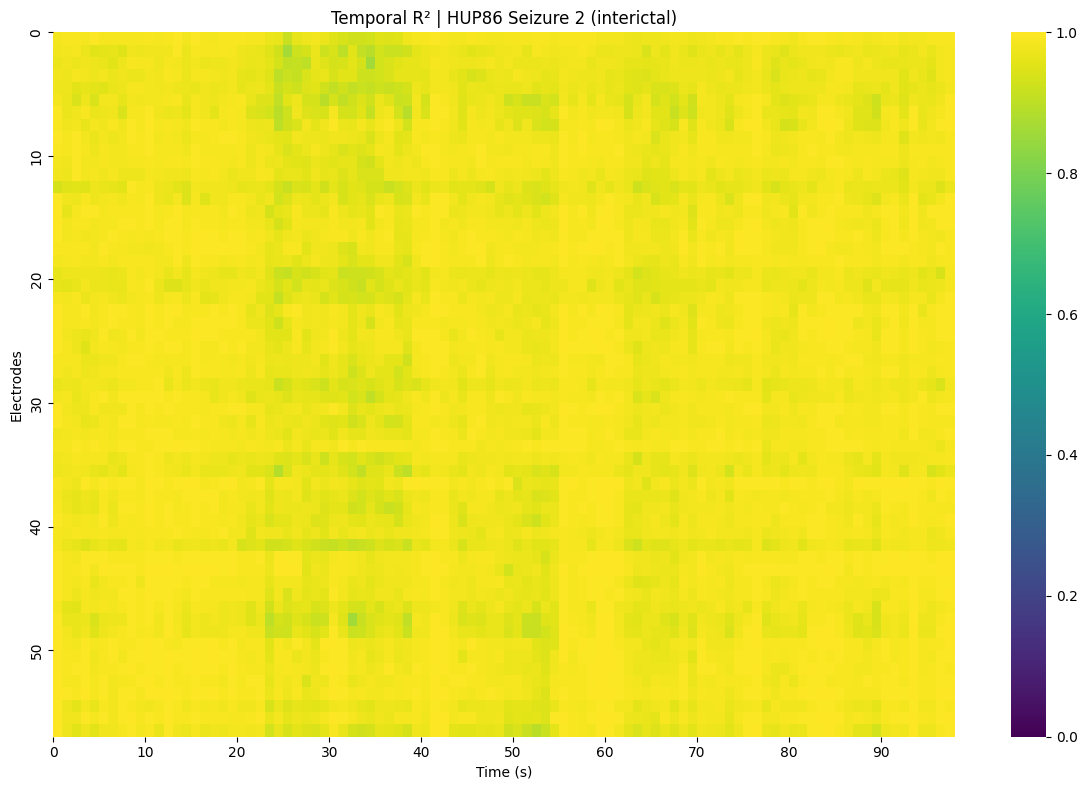

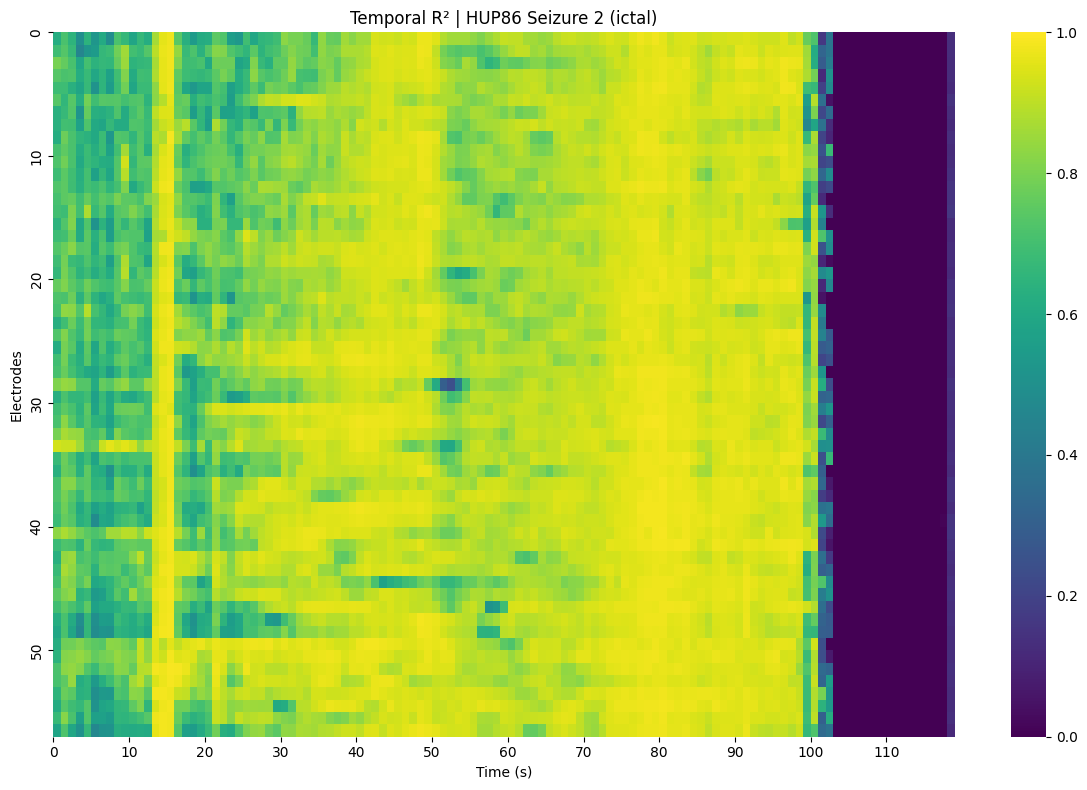

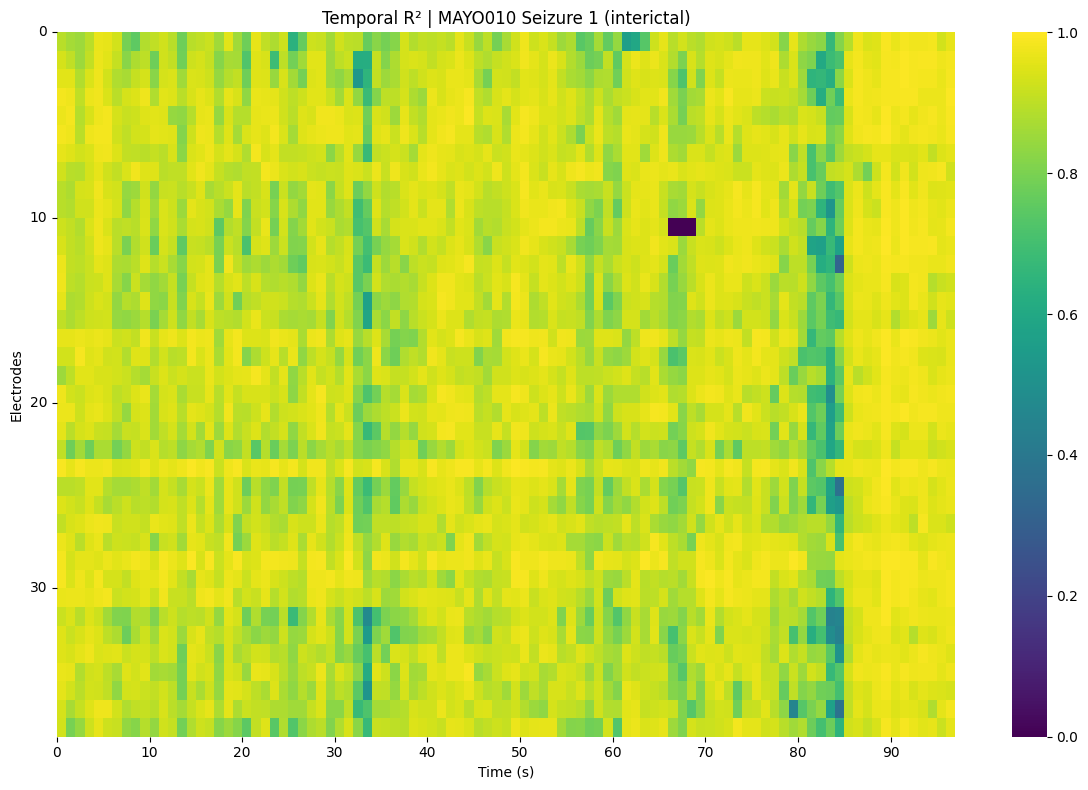

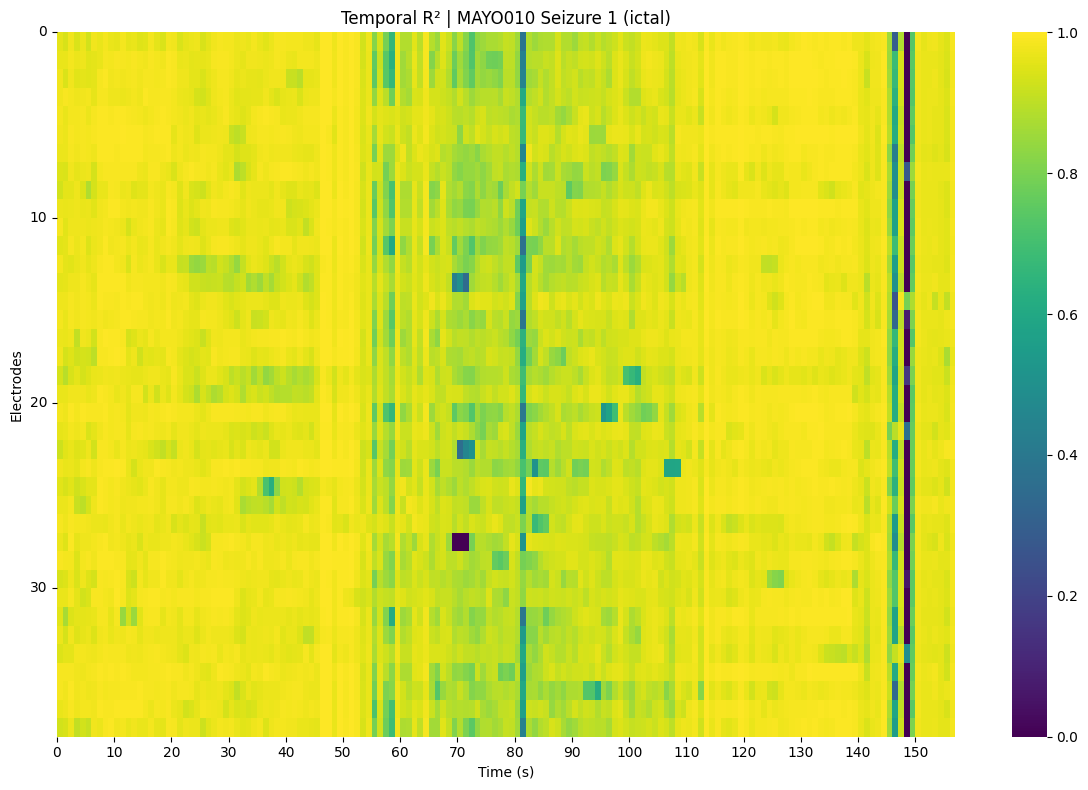

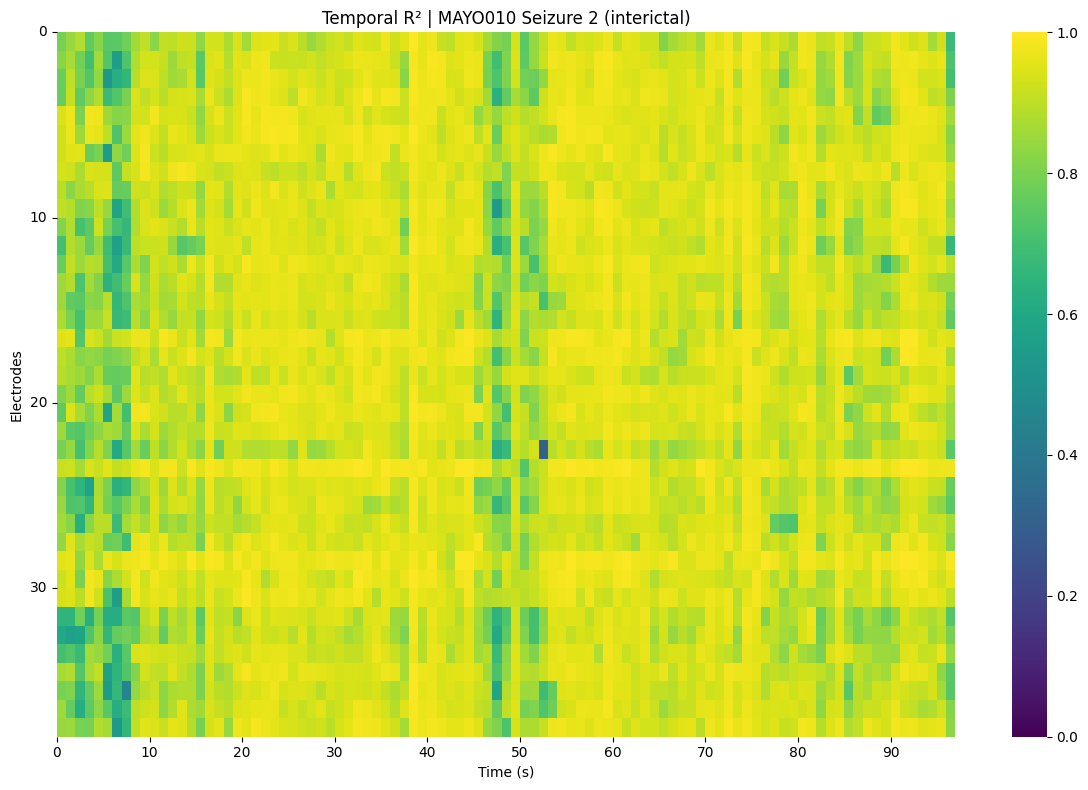

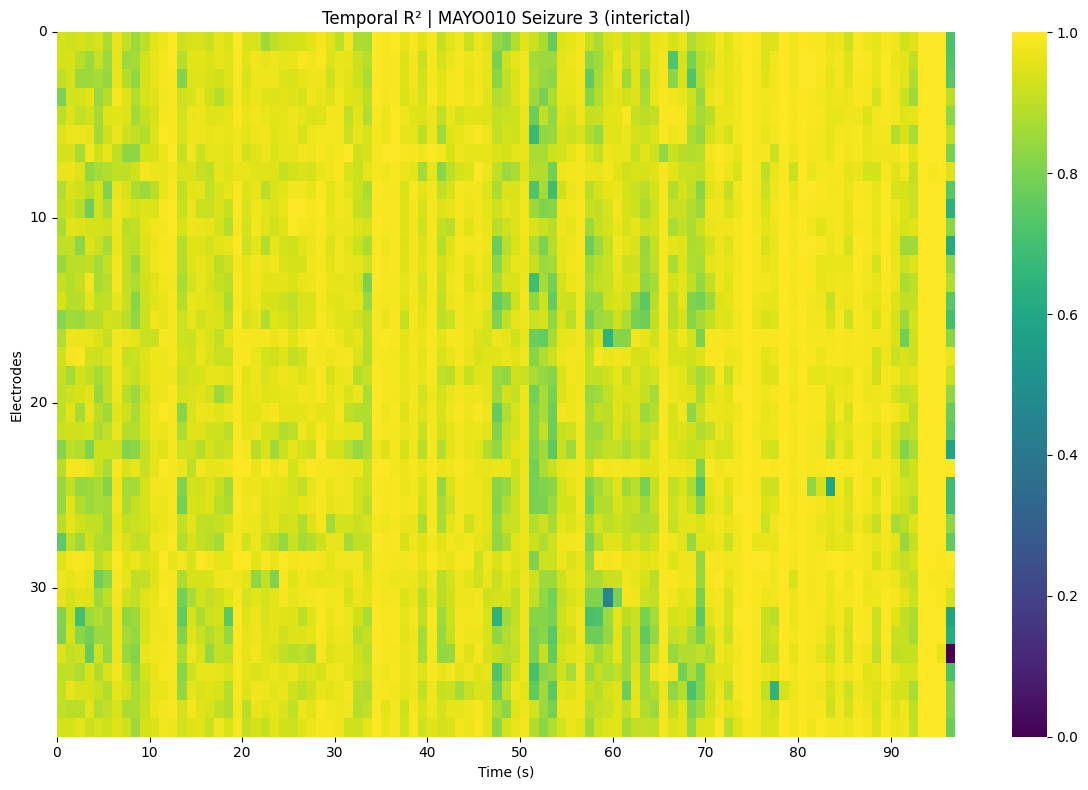

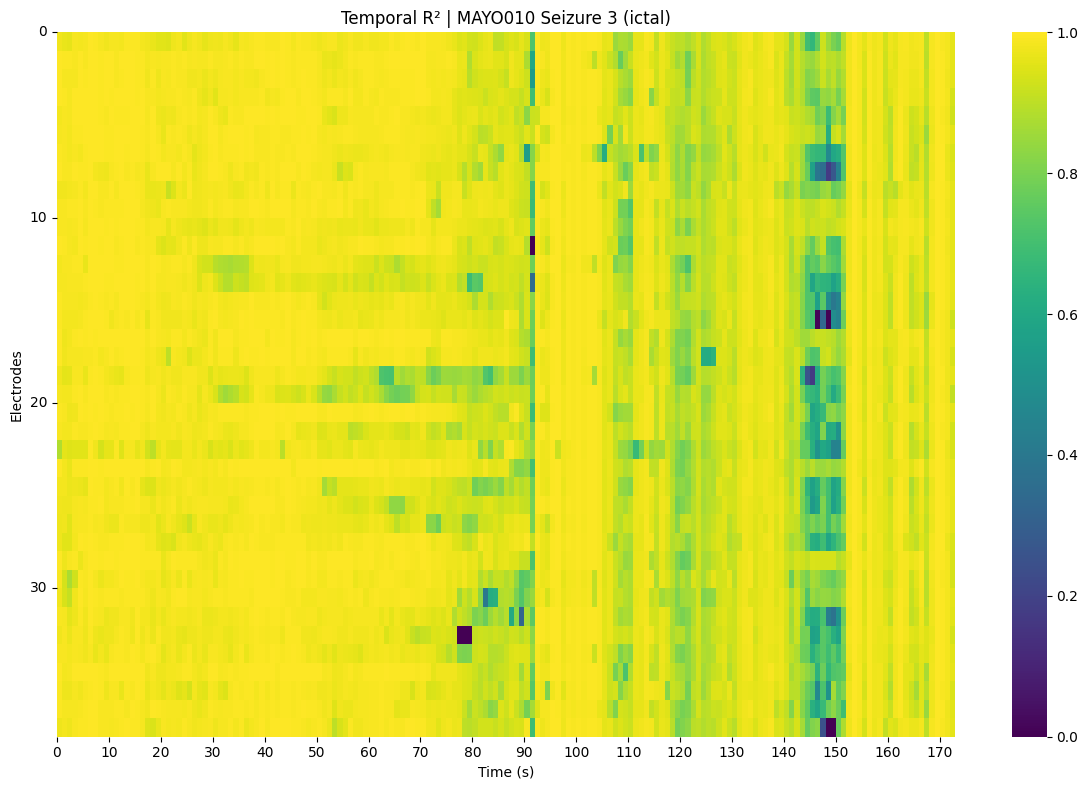

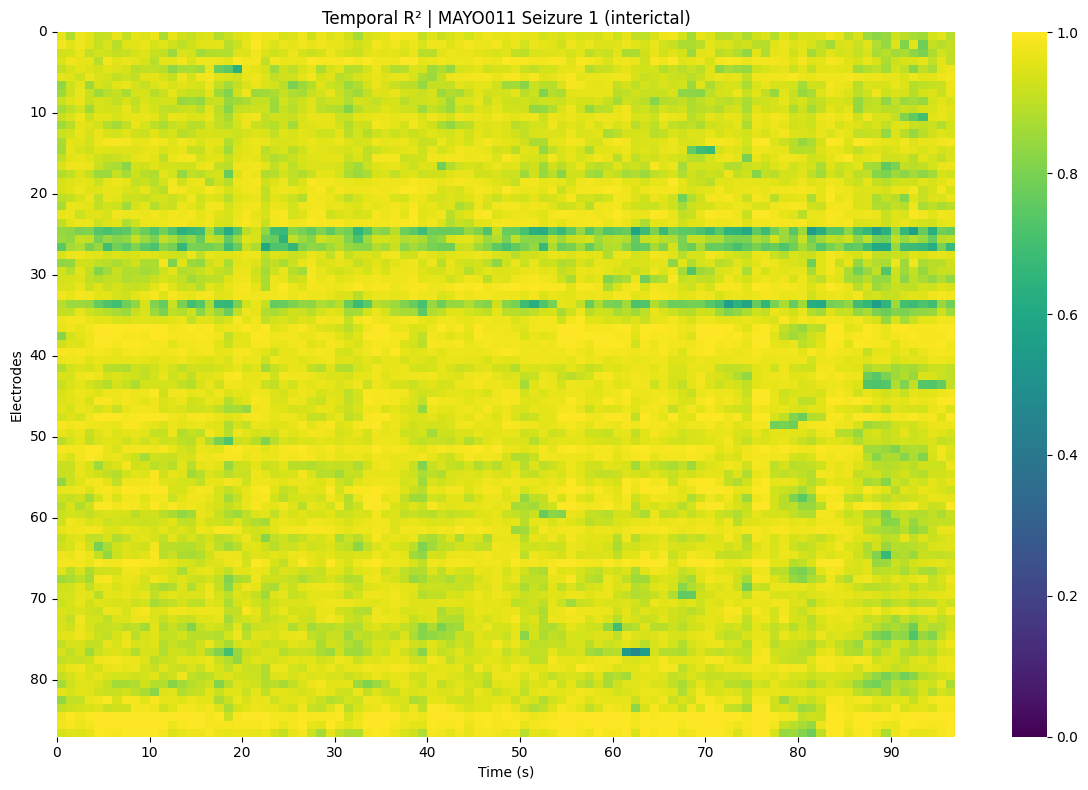

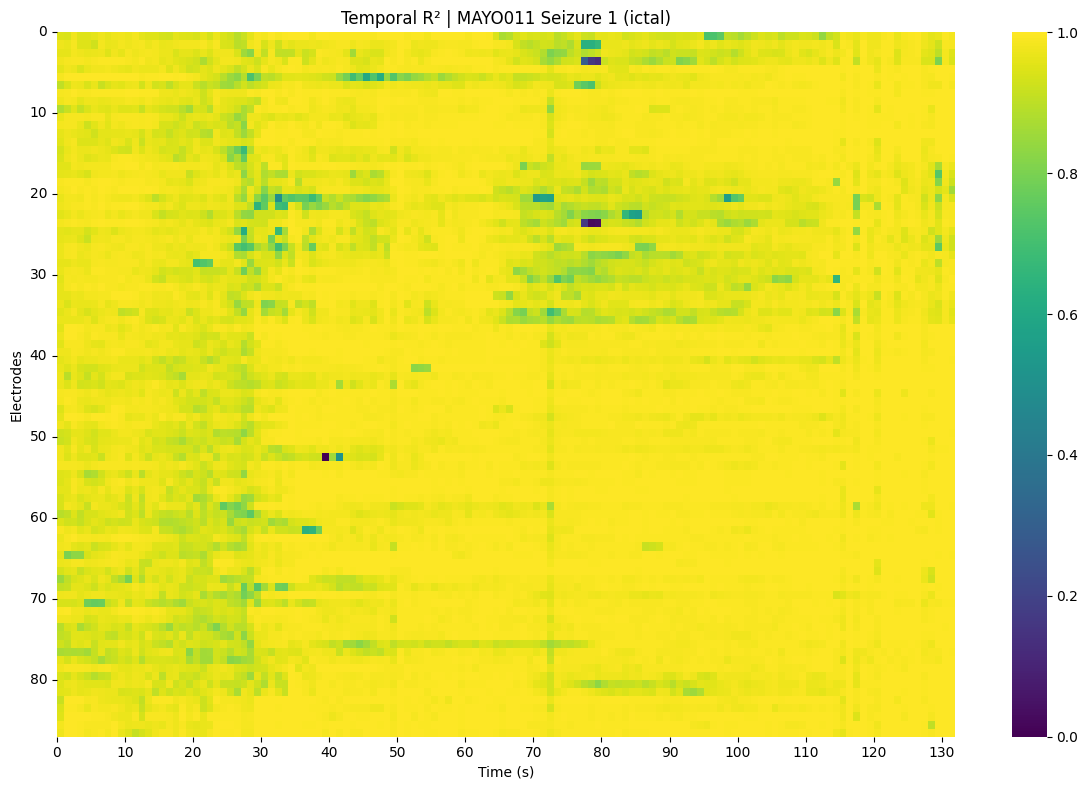

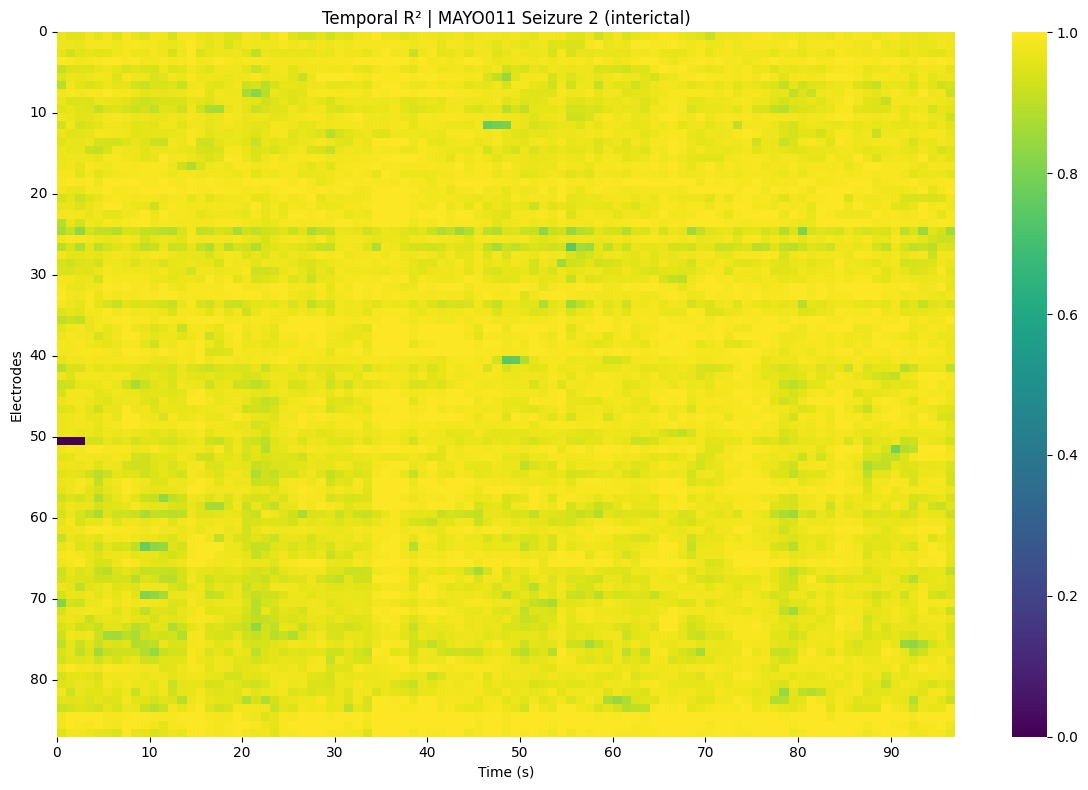

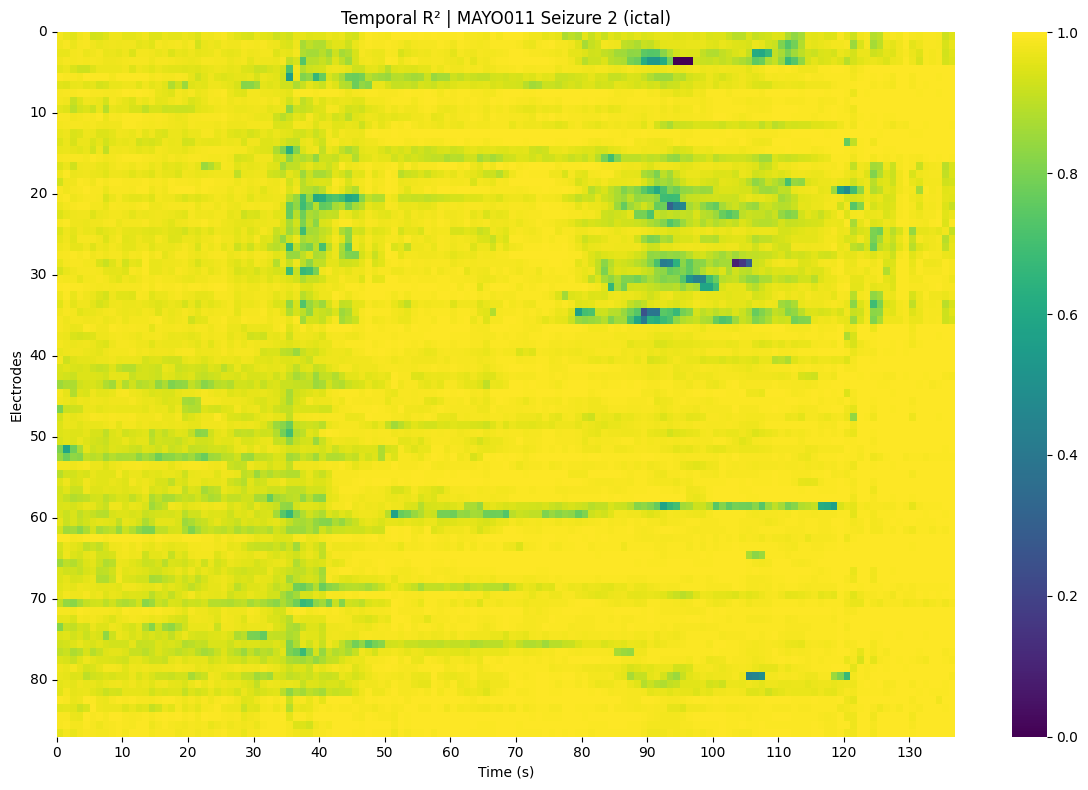

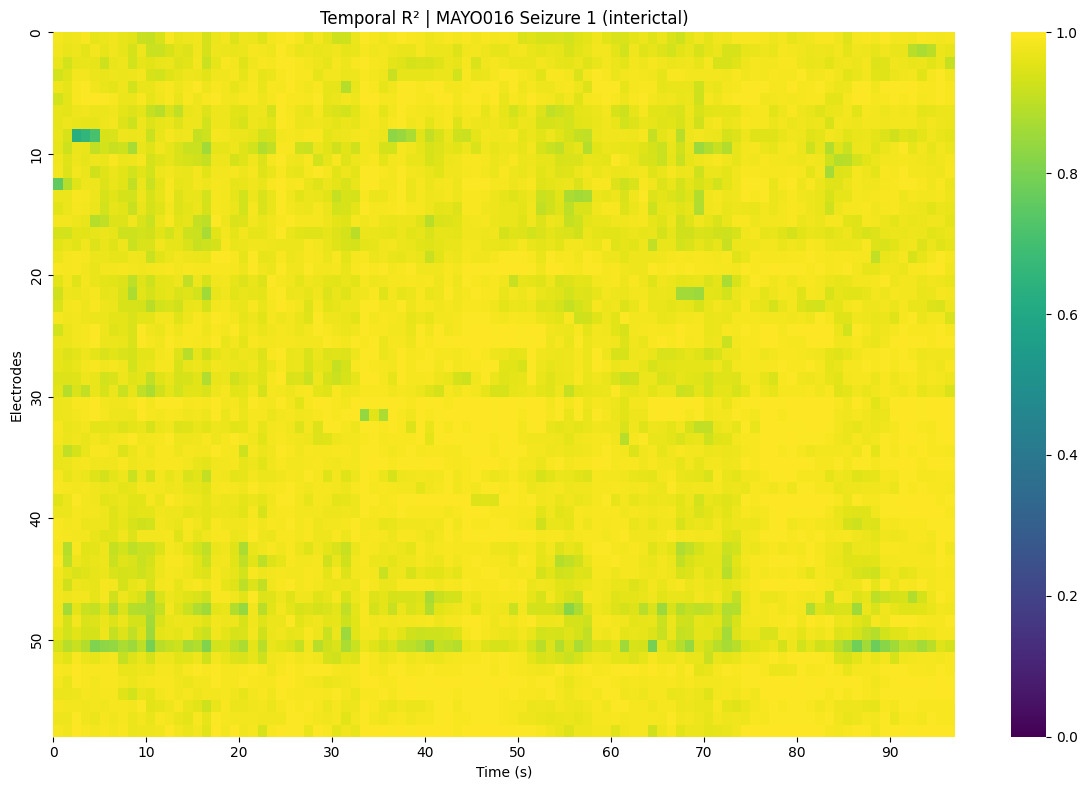

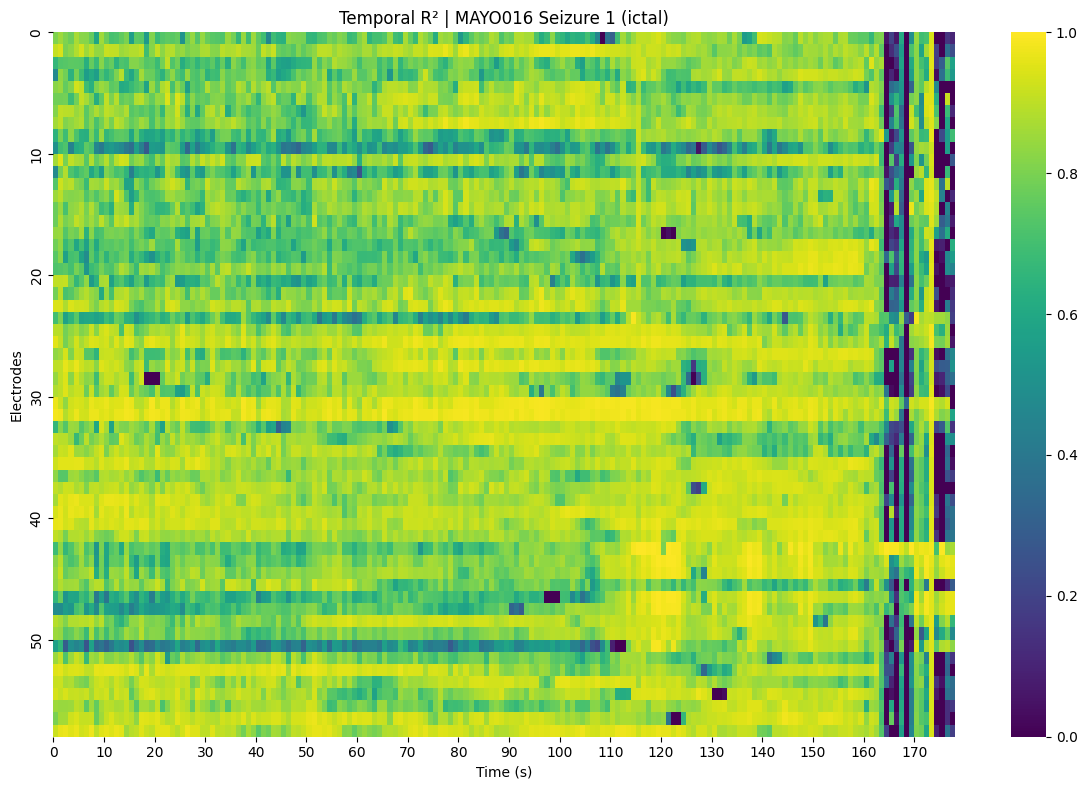

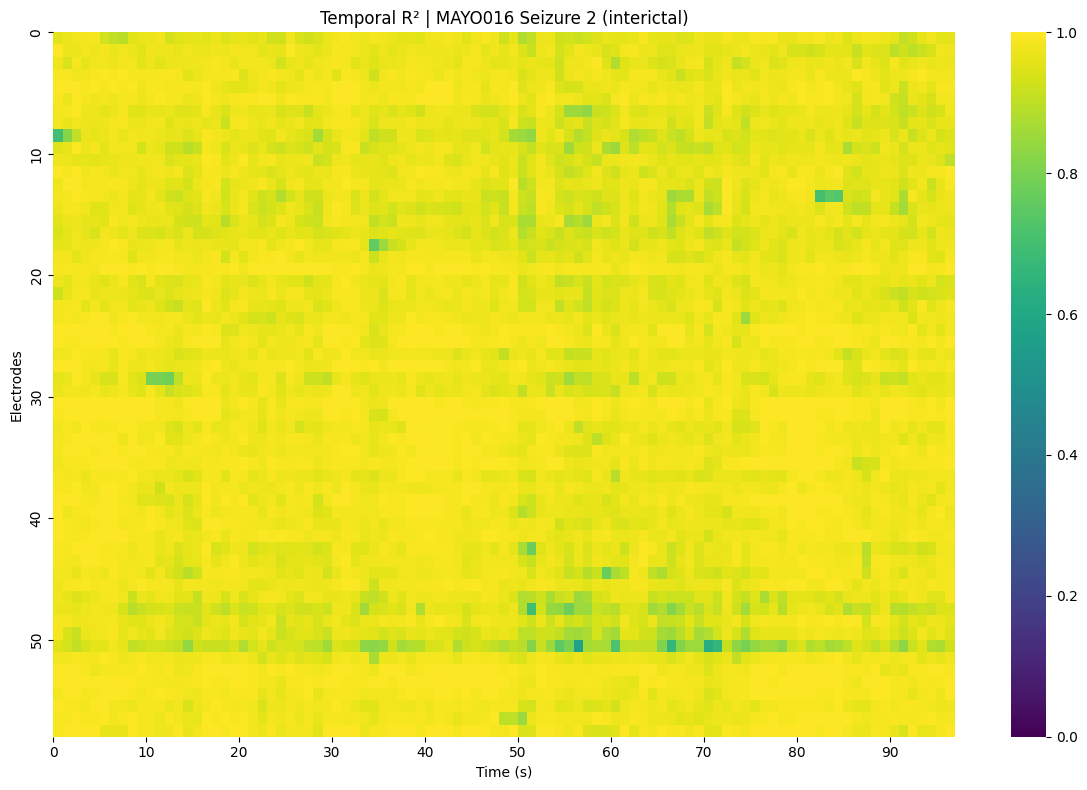

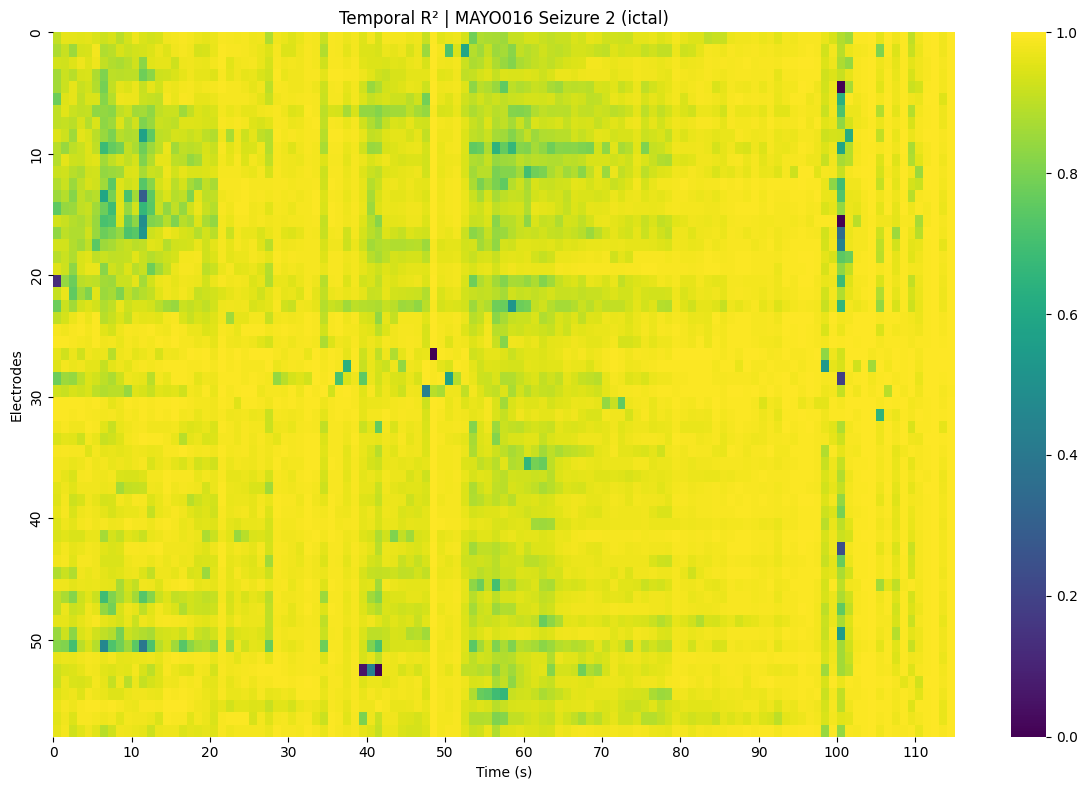

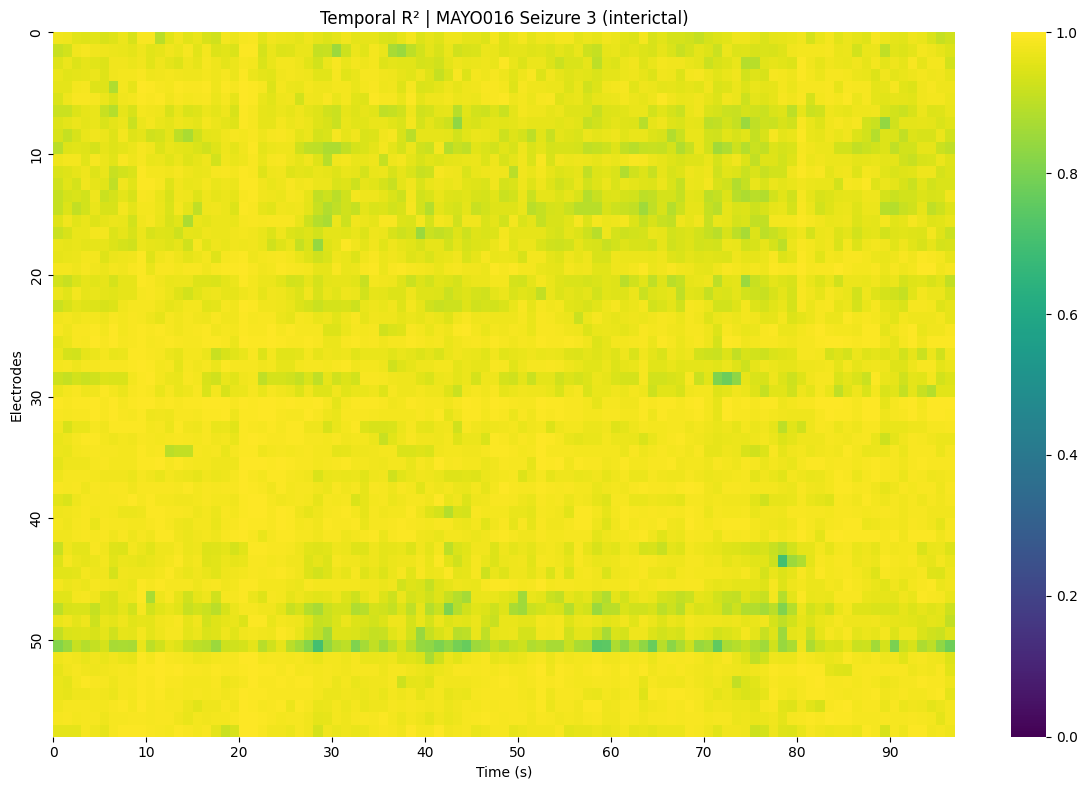

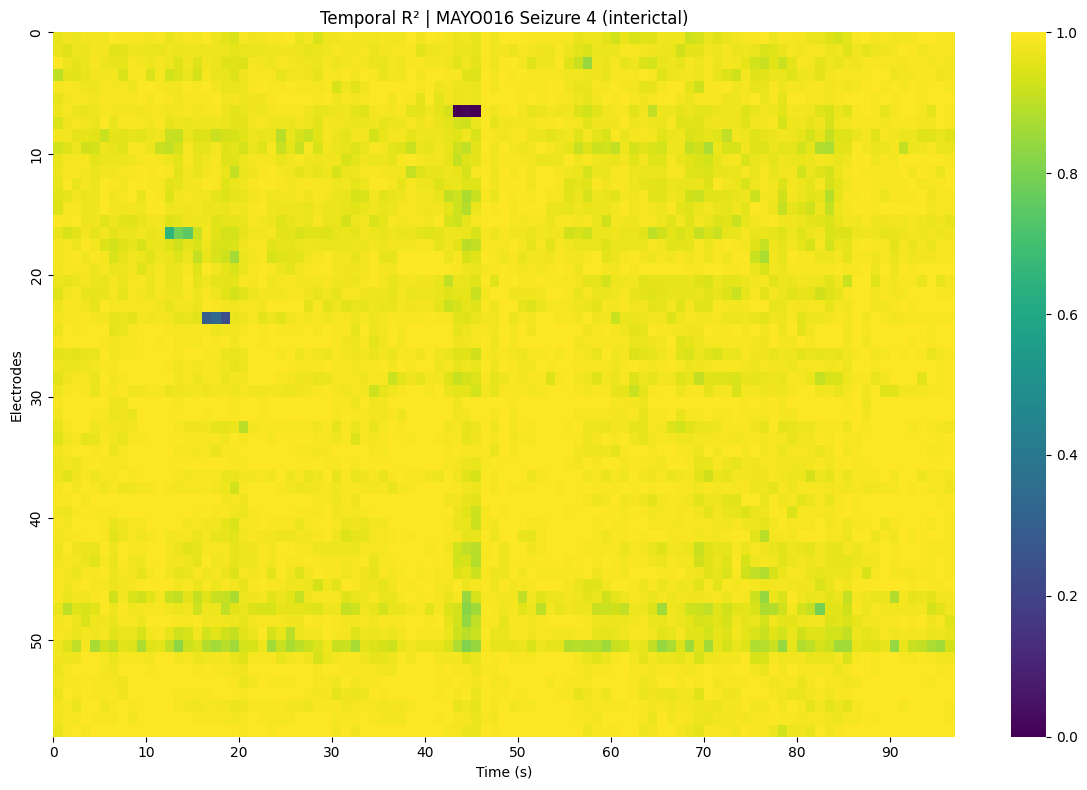

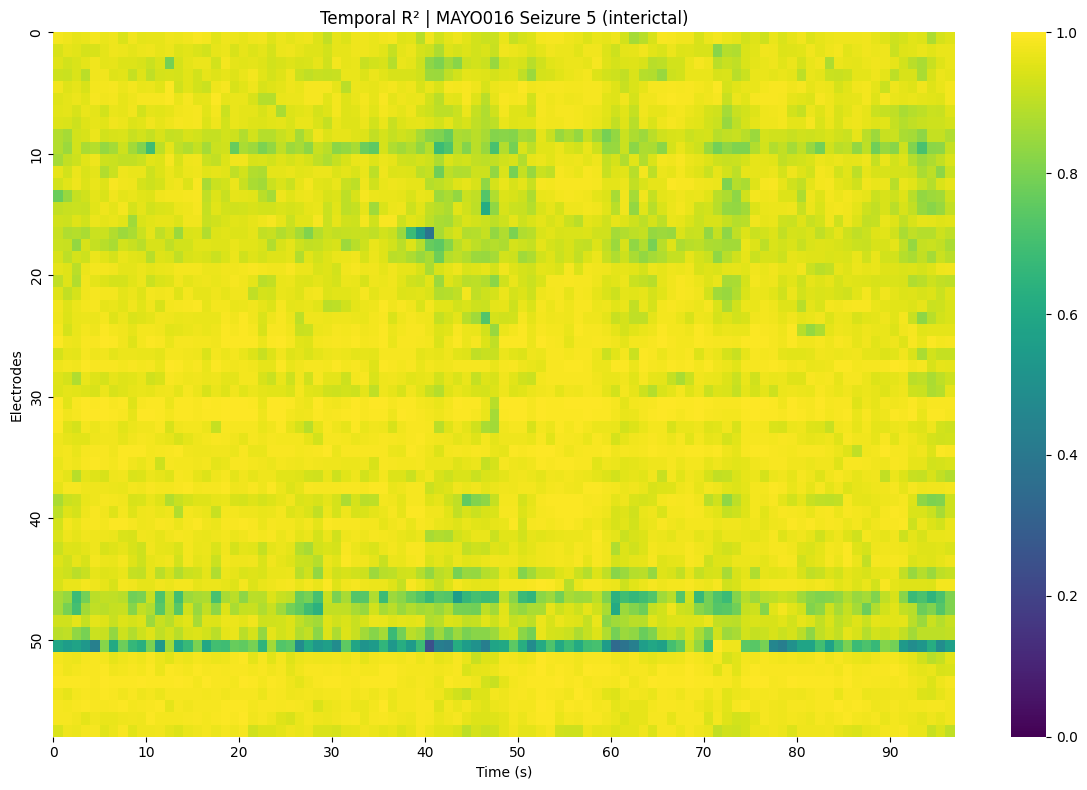

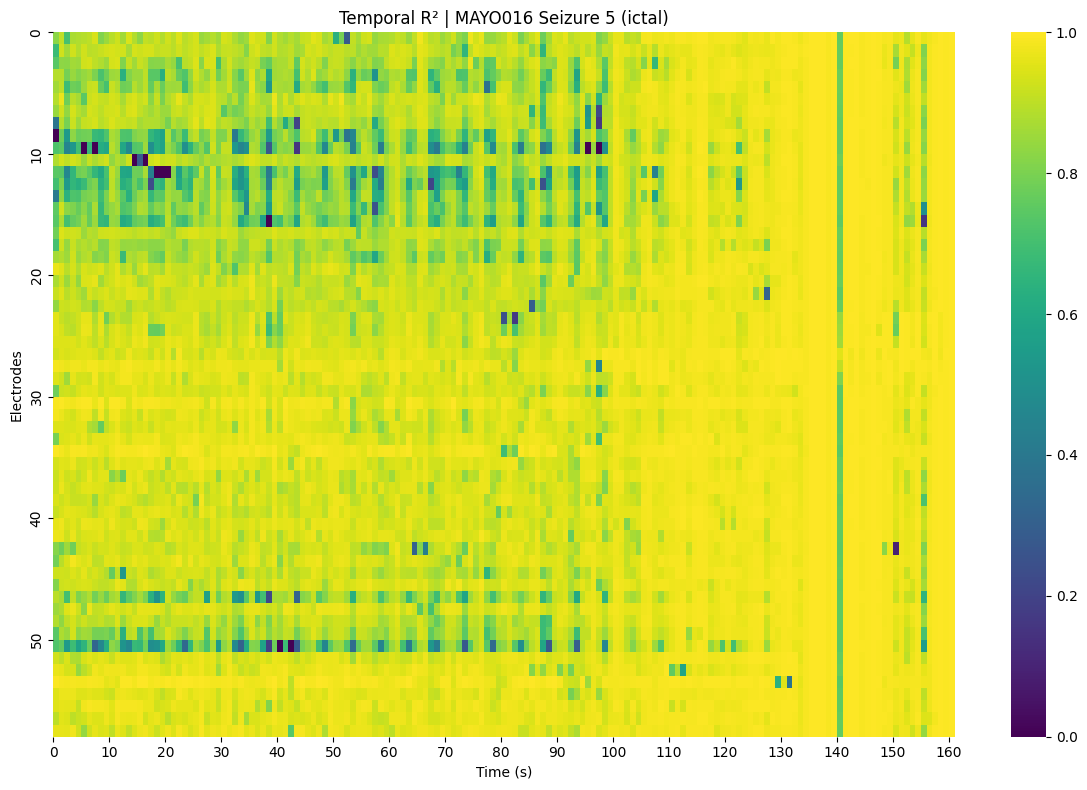

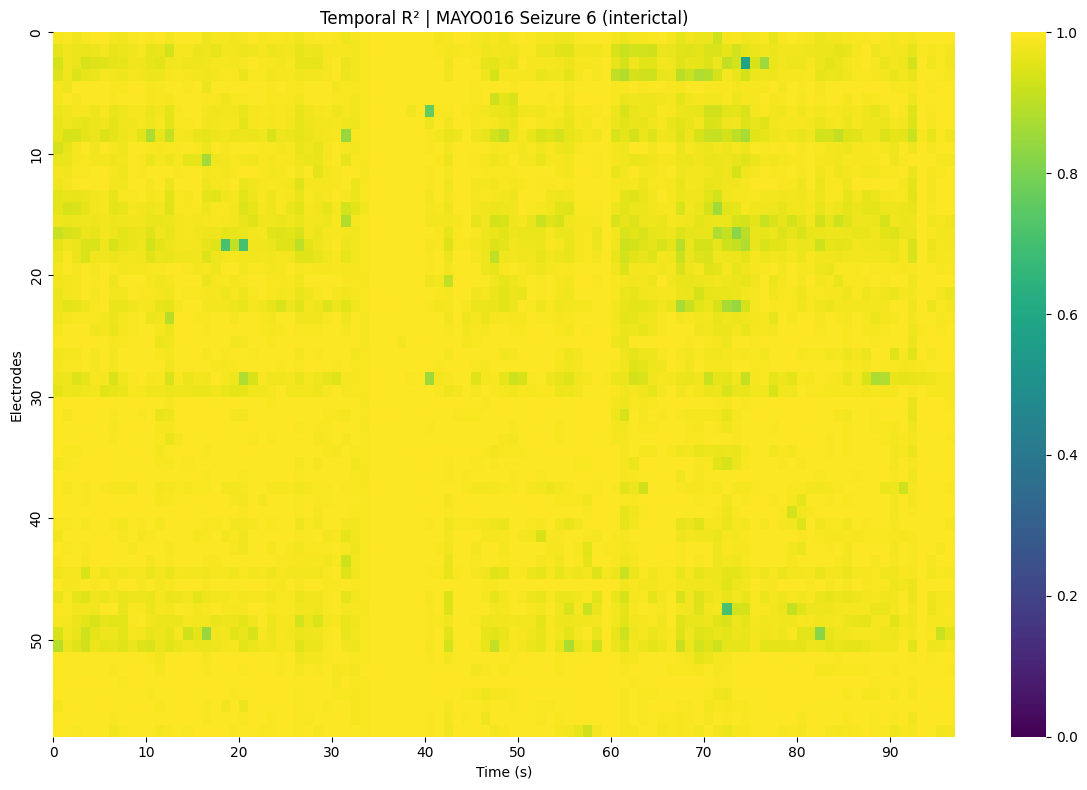

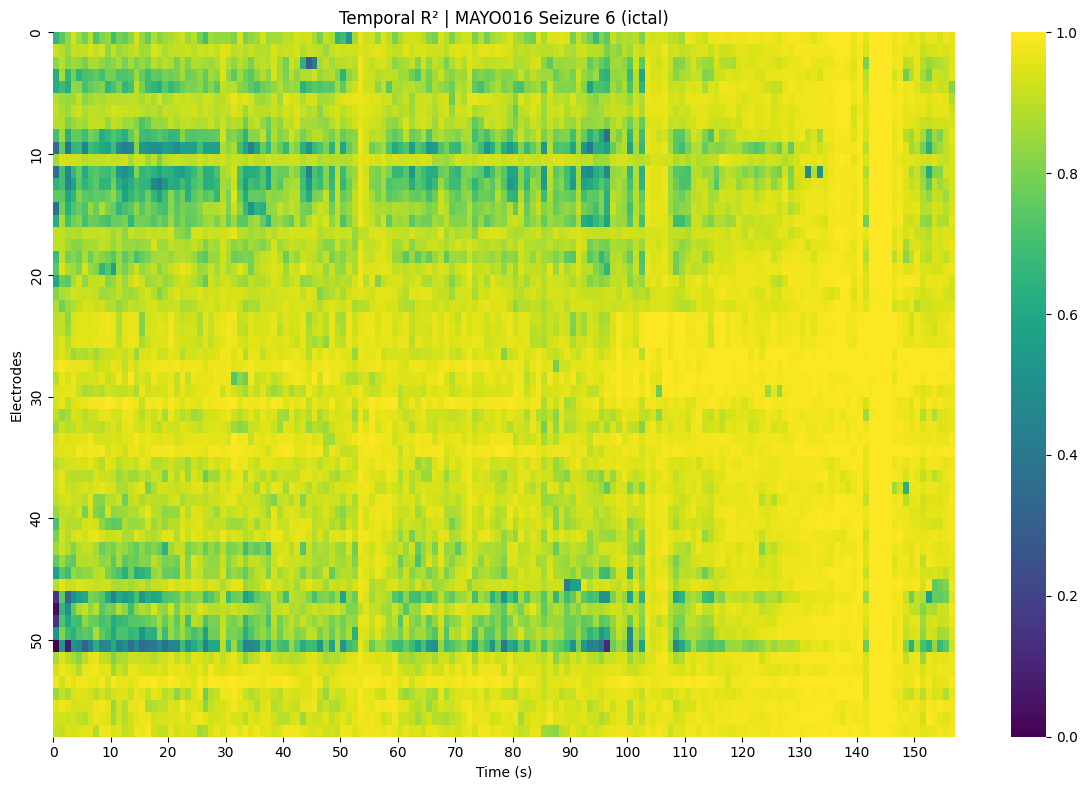

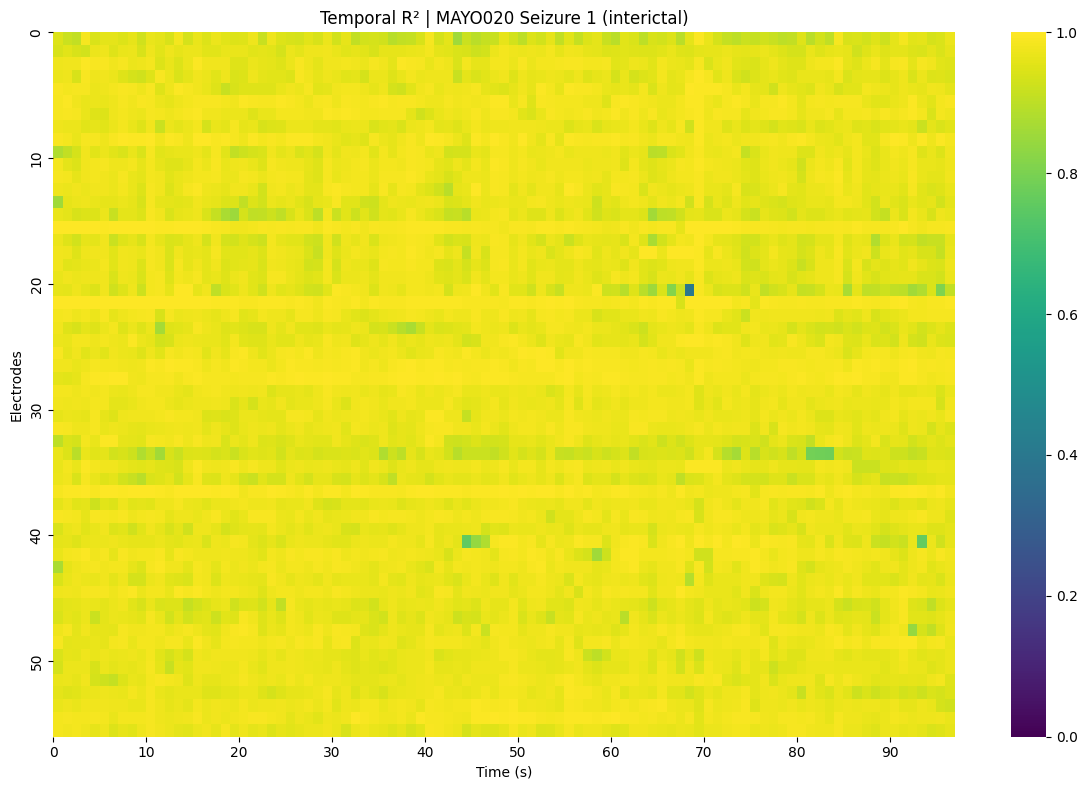

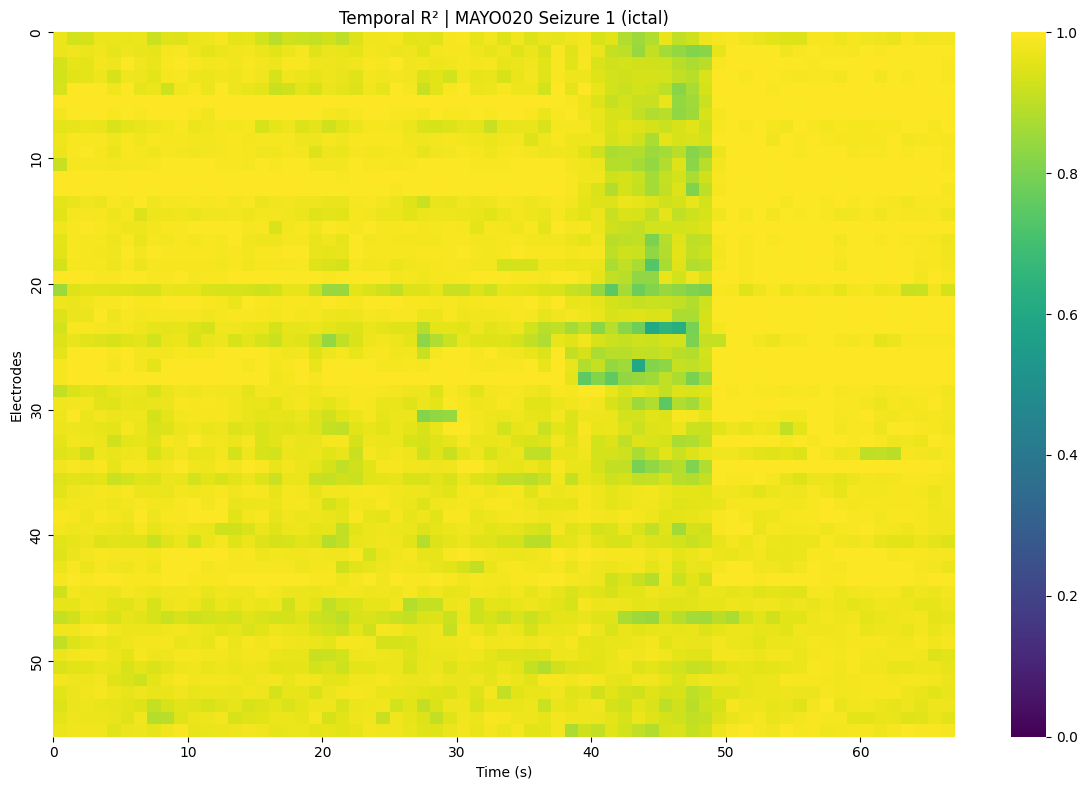

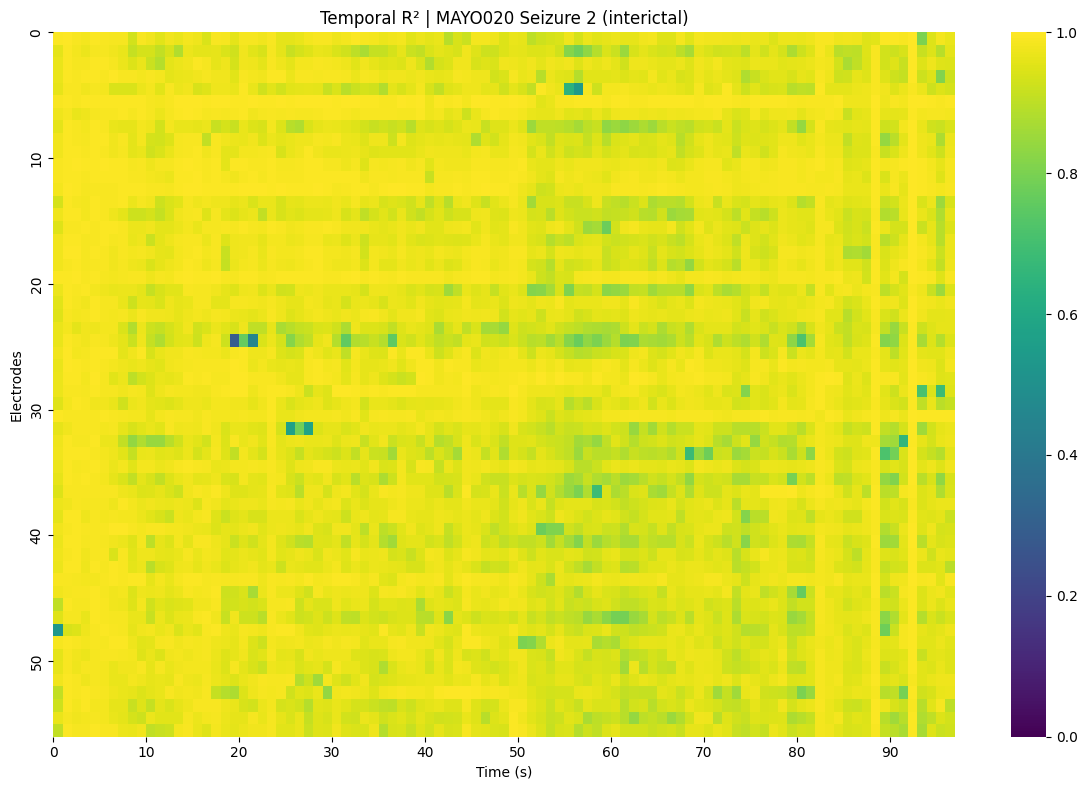

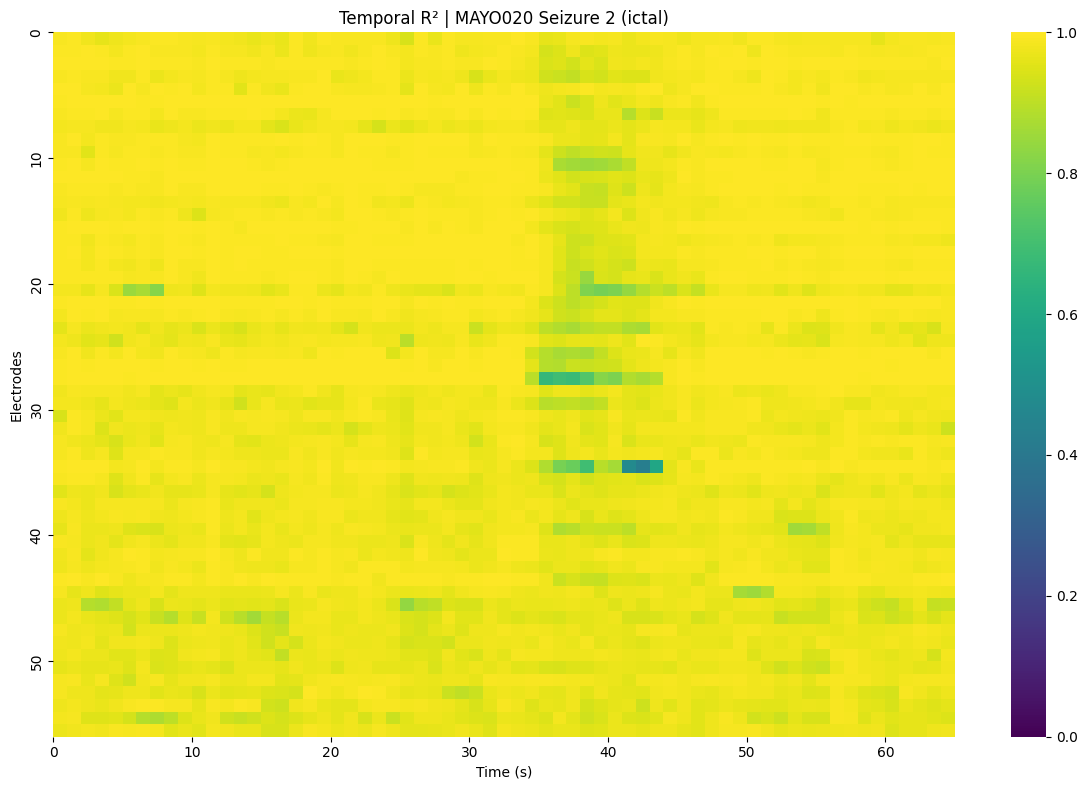

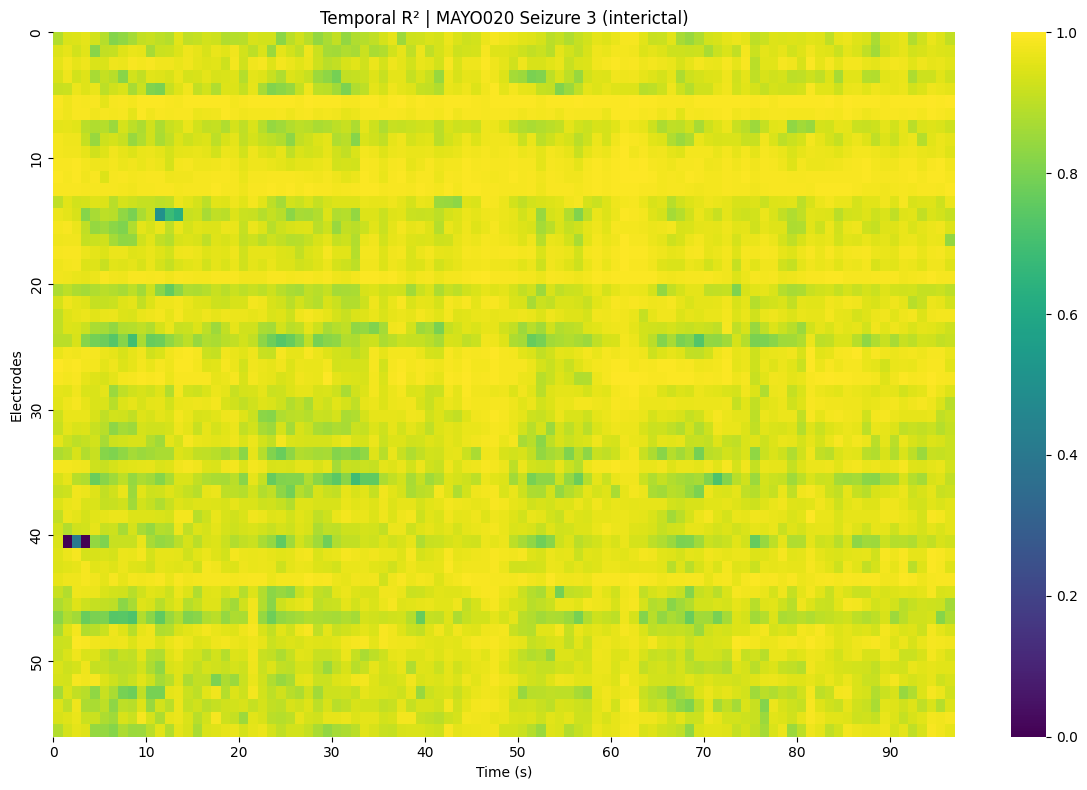

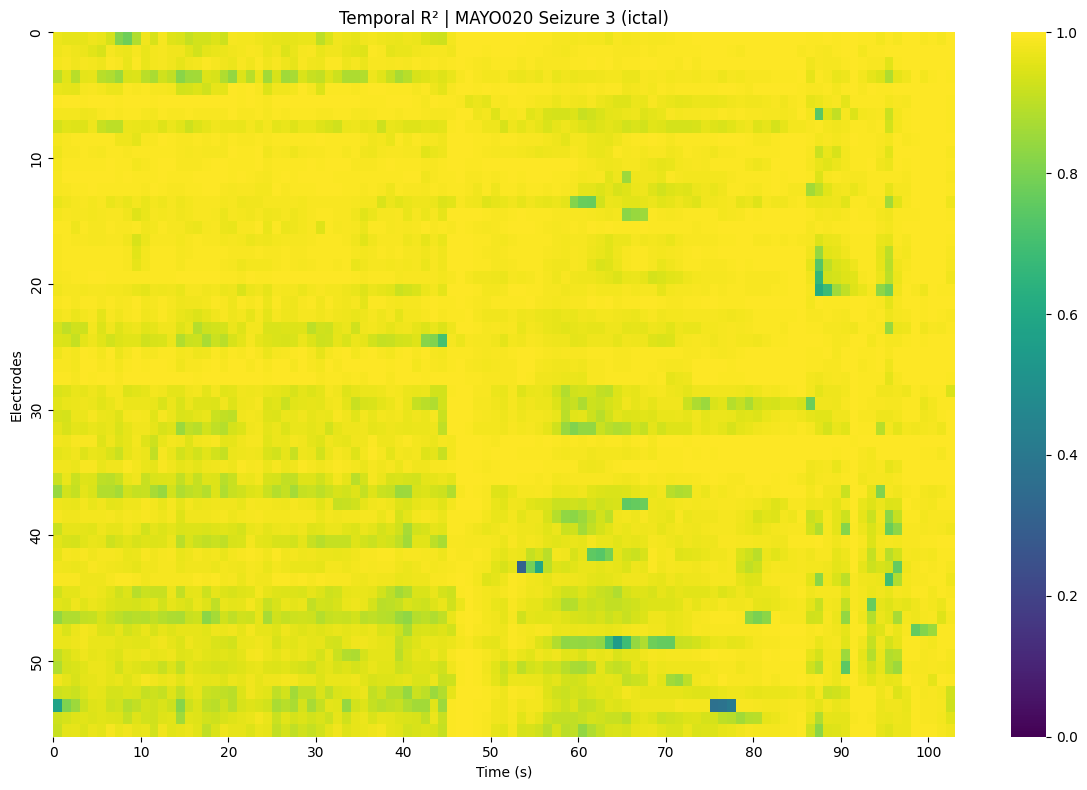

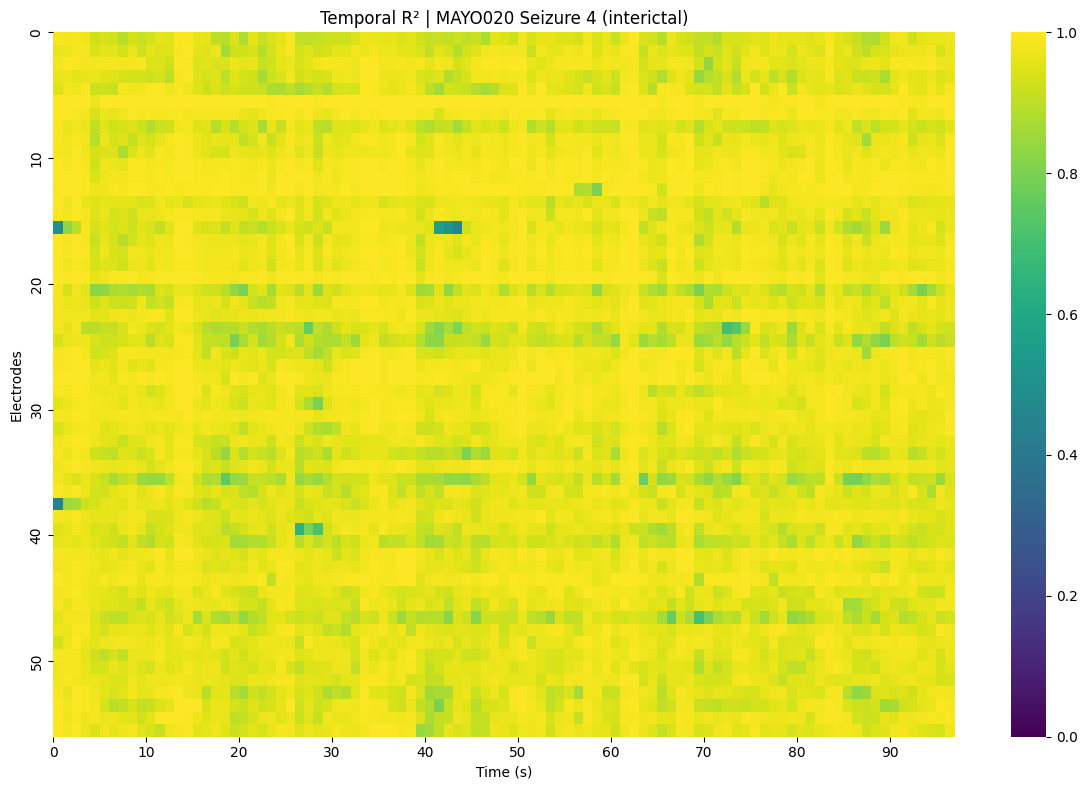

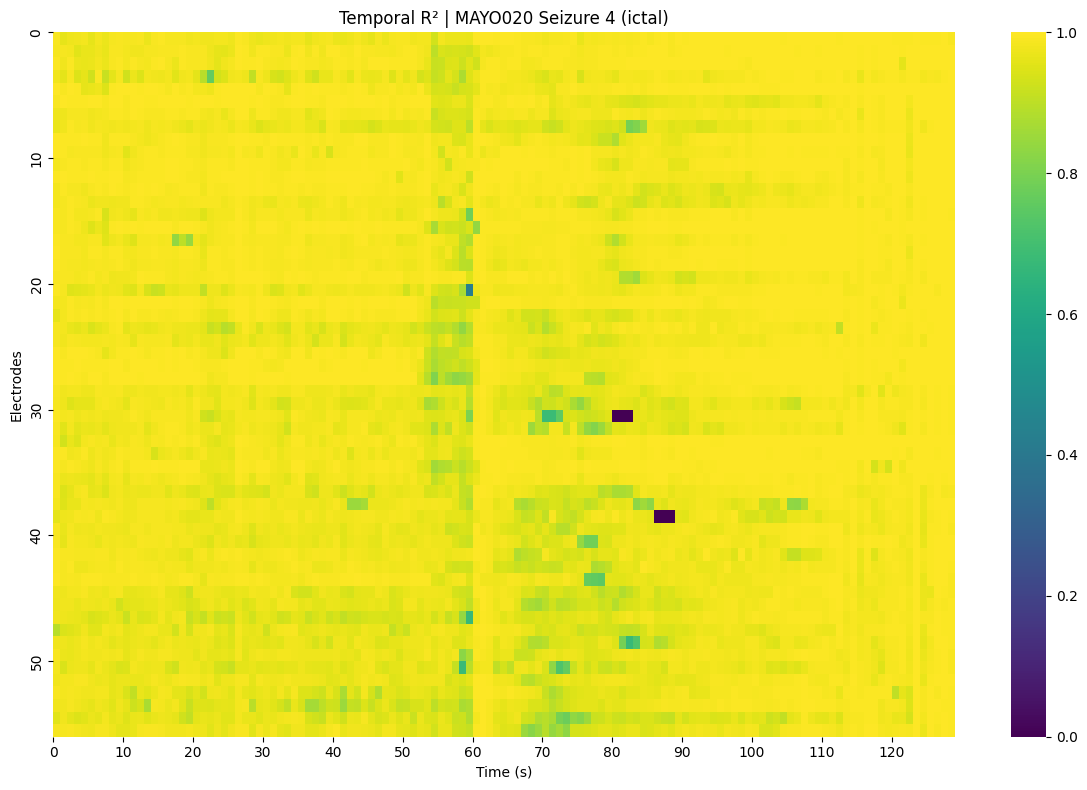

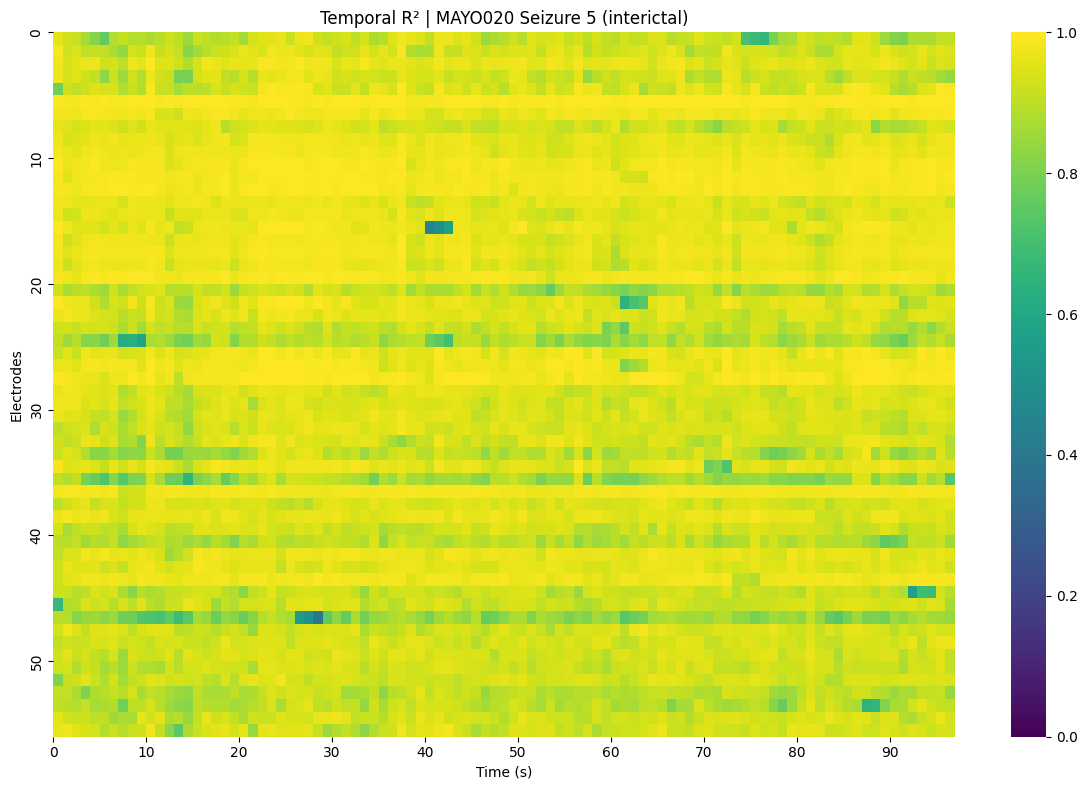

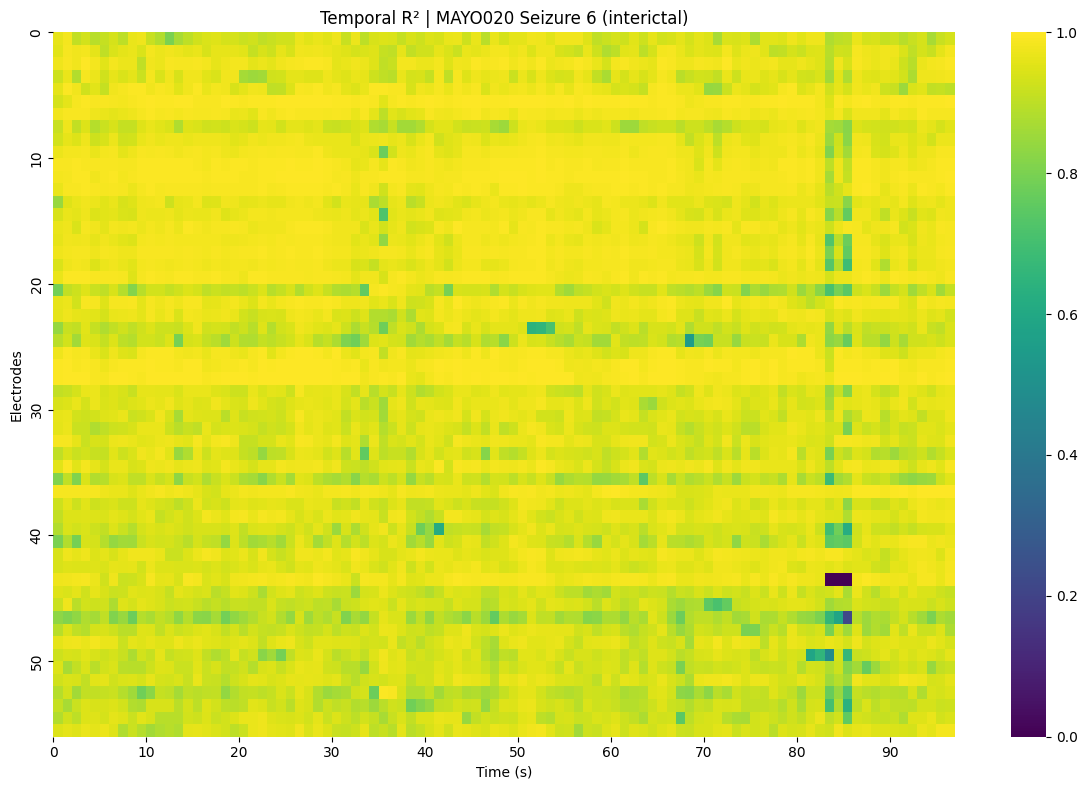

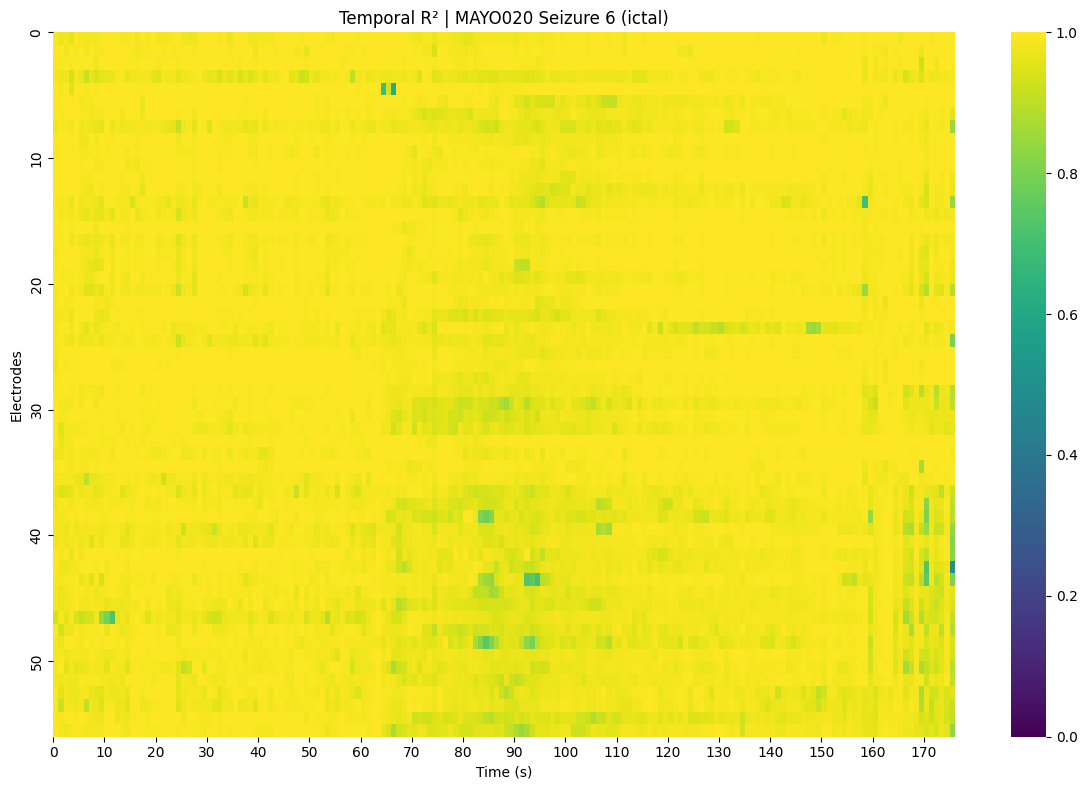

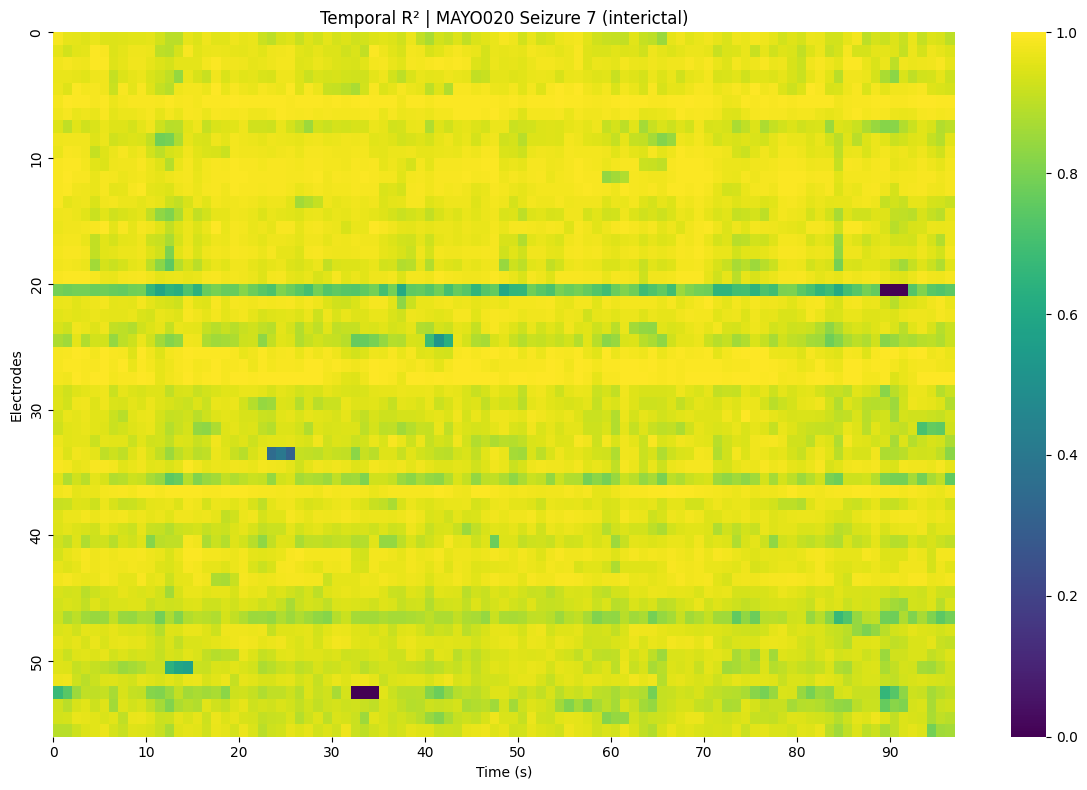

In [4]:
# R2 plots for all patients and segments to visualize fit 
for patient in patients: 
    for seizure in range(1, 9):
        for phase in ['interictal', 'ictal']:
            path = os.path.join(main_pathname, 'data_v2', patient, f'{phase}_block_{seizure}_parameters_3sec_1iter.mat')
            if(os.path.exists(path)):
                parameters = scipy.io.loadmat(path)
                raw_signal = scipy.io.loadmat(os.path.join(main_pathname, 'data', patient, f'{patient}-{phase}-block-{seizure}.mat'))

                alpha = parameters['alpha']
                xPred = parameters['xPred']
                evData = raw_signal['evData']
                sampling_rate = int(np.ceil(raw_signal['Fs'][0][0]))
                window_samples = sampling_rate*window_length
                stride_samples = sampling_rate*stride
                num_chns, data_points = evData.shape
                num_windows = alpha.shape[1]

                counts = np.zeros(data_points)
                evData_centered = np.zeros_like(evData)
                # need to locally center windowed raw data for r squared to match reconstructed data 
                for start_idx in range(0, data_points - window_samples + 1, stride_samples):
                    X = evData[:, start_idx:start_idx + window_samples]
                    X = X - np.mean(X, axis = 1, keepdims=True)
                    evData_centered[:, start_idx:start_idx + window_samples] += X
                    counts[start_idx:start_idx + window_samples] += 1

                counts[counts == 0] = 1
                evData_centered /= counts[np.newaxis, :]

                # Heatmap, time x channels 
                # 1 second chunks for r2
                r2_over_time = np.zeros((num_chns, num_windows))
                for i in range(num_windows):
                    window_slice = slice(i*sampling_rate, (i+1)*sampling_rate)
                    for ch in range(num_chns):
                        try:
                            r2_over_time[ch, i] = r2_score(evData_centered[ch, window_slice], xPred[ch, window_slice])
                        except: 
                            r2_over_time[ch, i] = np.nan 
                

                plt.figure(figsize=(12, 8))
                sns.heatmap(r2_over_time, cmap='viridis', vmin=0, vmax=1, cbar=True)

                # Label axes
                plt.title(f'Temporal R² | {patient} Seizure {seizure} ({phase})')
                plt.xlabel('Time (s)')
                plt.ylabel('Electrodes')
                
                # Time ticks in seconds
                ytick_locs = np.arange(0, num_chns, 10)
                ytick_labels = [str(i) for i in ytick_locs]
                xtick_locs = np.arange(0, num_windows, 10)
                xtick_labels = [str(i) for i in xtick_locs]
                plt.xticks(xtick_locs, xtick_labels, rotation = 0)
                plt.yticks(ytick_locs, ytick_labels)

                plt.tight_layout()
                plt.show()

                # save the r2 data 
                save_path = os.path.join(main_pathname, 'data_v2', patient, f"{phase}_block_{seizure}_r2_all.npz")
                np.savez_compressed(save_path, r2_fit = r2_over_time)

In [2]:
# Excluding segments based on R2 values and creating table for excluded segments 
def check_segment(r2_segment, threshold=0.5):
    channel_r2 = np.nanmean(r2_segment, axis=1)
    good_ratio = np.mean(channel_r2 >= threshold)
    mean_r2 = np.nanmean(channel_r2)
    passes_check = good_ratio >= 0.6
    return passes_check, mean_r2, good_ratio

data_length = 18
ictal_start = 20
excluded_seg = [] 

for patient in patients: 
    save_dict = {}
    for seizure in range(1, 9):
        for phase in ['interictal', 'ictal']:
            path = os.path.join(main_pathname, 'data_v2', patient, f"{phase}_block_{seizure}_r2_all.npz")
            if(os.path.exists(path)):
                r2_all = np.load(path)["r2_fit"]
                num_windows = r2_all.shape[1]
                ictal_end = min(num_windows-21, ictal_start + data_length)
                
                if phase == 'interictal': 
                    interictal_r2 = r2_all[:, 0:data_length]
                    passes, mean_r2, good_ratio = check_segment(interictal_r2)
                    if passes:
                        save_dict[f"interictal_r2_block_{seizure}"] = interictal_r2
                    else: 
                        excluded_seg.append((patient, 'interictal', seizure, mean_r2, good_ratio))
                        
                else: 
                    # Pre-ictal
                    preictal_r2 = r2_all[:, 0:data_length]
                    passes, mean_r2, good_ratio = check_segment(preictal_r2)
                    if passes:
                        save_dict[f"preictal_r2_block_{seizure}"] = preictal_r2
                    else: 
                        excluded_seg.append((patient, 'preictal', seizure, mean_r2, good_ratio))
                    # Ictal
                    # if ictal_end - ictal_start < data_length:
                    #     excluded_seg.append((patient, 'ictal', seizure, 'short', 'short'))
                    # else:
                    ictal_r2 = r2_all[:, ictal_start:ictal_end]
                    passes, mean_r2, good_ratio = check_segment(ictal_r2)
                    if passes:
                        save_dict[f"ictal_r2_block_{seizure}"] = ictal_r2
                    else: 
                        excluded_seg.append((patient, 'ictal', seizure, mean_r2, good_ratio))
                    # Post-ictal
                    postictal_r2 = r2_all[:, -data_length:]
                    passes, mean_r2, good_ratio = check_segment(postictal_r2)
                    if passes:
                        save_dict[f"postictal_r2_block_{seizure}"] = postictal_r2
                    else: 
                        excluded_seg.append((patient, 'postictal', seizure, mean_r2, good_ratio))

    save_path = os.path.join(main_pathname, 'data_v2', patient, f"valid_fos_blocks.npz")
    np.savez_compressed(save_path, **save_dict)
print("\nExcluded Segments Summary:")
print("Patient | Segment Type | Count | Mean R² | % Good Channels")
print("-" * 60)

from collections import defaultdict
summary = defaultdict(lambda: defaultdict(list))

for patient, seg_type, seizure, mean_r2, good_ratio in excluded_seg:
    summary[patient][seg_type].append((mean_r2, good_ratio))

for patient in sorted(summary.keys()):
    for seg_type in ['preictal', 'ictal', 'postictal', 'interictal']:
        if seg_type in summary[patient]:
            values = summary[patient][seg_type]
            count = len(values)
            avg_r2 = np.mean([v[0] for v in values])
            avg_ratio = np.mean([v[1] for v in values])
            print(f"{patient} | {seg_type} | {count} | {avg_r2:.3f} | {avg_ratio*100:.1f}%")

excluded_list = []
for patient, seg_type, seizure, mean_r2, good_ratio in excluded_seg:
    excluded_list.append({
        'patient': patient,
        'seizure': seizure,
        'segment_type': seg_type
    })

# Save to file
excluded_path = os.path.join(main_pathname, 'data_v2', 'excluded_segments.json')
with open(excluded_path, 'w') as f:
    json.dump(excluded_list, f, indent=2)

print("\n" + "=" * 60)
print("Detailed list of excluded segments by block:")
print("=" * 60)
for patient, seg_type, seizure, mean_r2, good_ratio in excluded_seg:
    print(f"{patient} | {seg_type} | Block {seizure} | R²={mean_r2:.3f} | Good channels={good_ratio*100:.1f}%")


Excluded Segments Summary:
Patient | Segment Type | Count | Mean R² | % Good Channels
------------------------------------------------------------
HUP64 | postictal | 1 | 0.345 | 17.4%
HUP68 | postictal | 3 | 0.313 | 8.0%
HUP78 | preictal | 1 | 0.429 | 33.7%
HUP78 | postictal | 1 | 0.433 | 32.6%
HUP78 | interictal | 5 | -0.192 | 13.5%
HUP86 | postictal | 2 | -0.412 | 0.0%
MAYO016 | postictal | 1 | 0.328 | 24.1%

Detailed list of excluded segments by block:
HUP64 | postictal | Block 1 | R²=0.345 | Good channels=17.4%
HUP68 | postictal | Block 1 | R²=0.370 | Good channels=17.7%
HUP68 | postictal | Block 2 | R²=0.337 | Good channels=3.8%
HUP68 | postictal | Block 3 | R²=0.232 | Good channels=2.5%
HUP78 | interictal | Block 1 | R²=-1.822 | Good channels=0.0%
HUP78 | interictal | Block 2 | R²=0.553 | Good channels=53.5%
HUP78 | interictal | Block 3 | R²=0.197 | Good channels=5.8%
HUP78 | interictal | Block 4 | R²=0.222 | Good channels=8.1%
HUP78 | interictal | Block 5 | R²=-0.110 | Good ch

In [11]:
# Load excluded segments info
excluded_path = os.path.join(main_pathname, 'data_v2', 'excluded_segments.json')
with open(excluded_path, 'r') as f:
    excluded_segments = json.load(f)

# Convert to set of tuples for easy lookup
excluded_set = {(seg['patient'], seg['segment_type'], seg['seizure']) 
                for seg in excluded_segments}

# Calculate amplitudes for different segment types
amplitudes = {
    'included_postictal': [],
    'excluded_postictal': [],
    'included_interictal': [],
    'excluded_interictal_HUP78': [],
}

for patient in patients: 
    for seizure in range(1, 9): 
        features_path = os.path.join(main_pathname, 'data_v2', patient, f"fos_features_block_{seizure}.npz")
        if os.path.exists(features_path):
            features = np.load(features_path)
            
            # Calculate RMS amplitude for each segment type
            for seg_type, data_key in [('preictal', 'preictal_iEEG'),
                                        ('ictal', 'ictal_iEEG'), 
                                        ('postictal', 'postictal_iEEG'),
                                        ('interictal', 'interictal_iEEG')]:
                
                if data_key in features:
                    data = features[data_key]
                    # RMS amplitude across channels and time
                    rms_amp = np.sqrt(np.mean(data**2))
                    
                    if seg_type == 'postictal':
                        if (patient, seg_type, seizure) in excluded_set:
                            amplitudes['excluded_postictal'].append(rms_amp)
                        else:
                            amplitudes['included_postictal'].append(rms_amp)
                    
                    elif seg_type == 'interictal':
                        if (patient, seg_type, seizure) in excluded_set:
                            amplitudes['excluded_interictal_HUP78'].append(rms_amp)
                        elif patient != 'HUP78':
                            amplitudes['included_interictal'].append(rms_amp)

# Calculate statistics
print("\nAmplitude Analysis:")
print(f"Excluded post-ictal: {np.mean(amplitudes['excluded_postictal']):.1f} ± {np.std(amplitudes['excluded_postictal']):.1f} µV")
print(f"Included post-ictal: {np.mean(amplitudes['included_postictal']):.1f} ± {np.std(amplitudes['included_postictal']):.1f} µV")
print(f"\nHUP78 inter-ictal: {np.mean(amplitudes['excluded_interictal_HUP78']):.1f} ± {np.std(amplitudes['excluded_interictal_HUP78']):.1f} µV")
print(f"Other patients' inter-ictal: {np.mean(amplitudes['included_interictal']):.1f} ± {np.std(amplitudes['included_interictal']):.1f} µV")


Amplitude Analysis:
Excluded post-ictal: 139.1 ± 177.0 µV
Included post-ictal: 457.8 ± 928.7 µV

HUP78 inter-ictal: 238.5 ± 176.3 µV
Other patients' inter-ictal: 153.4 ± 126.7 µV


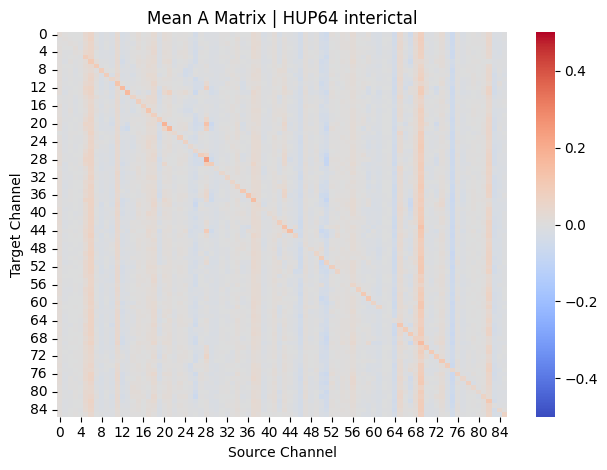

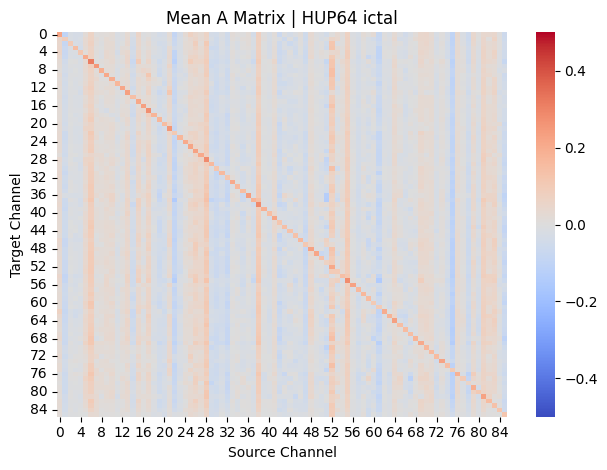

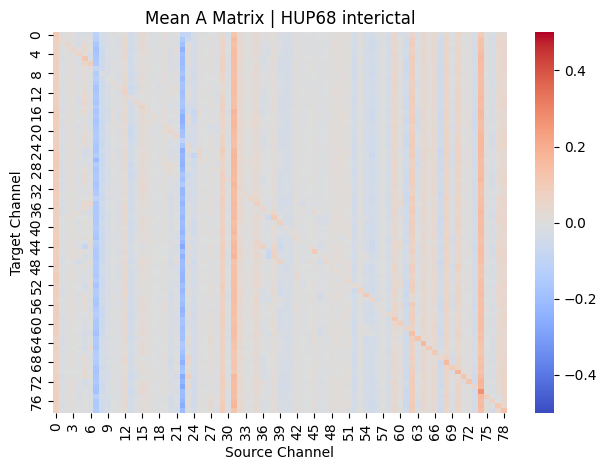

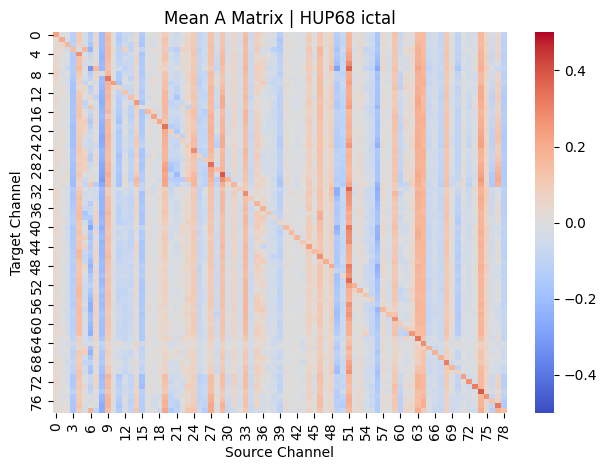

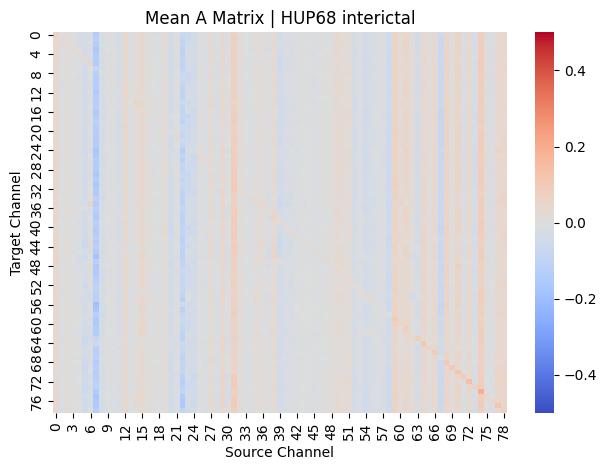

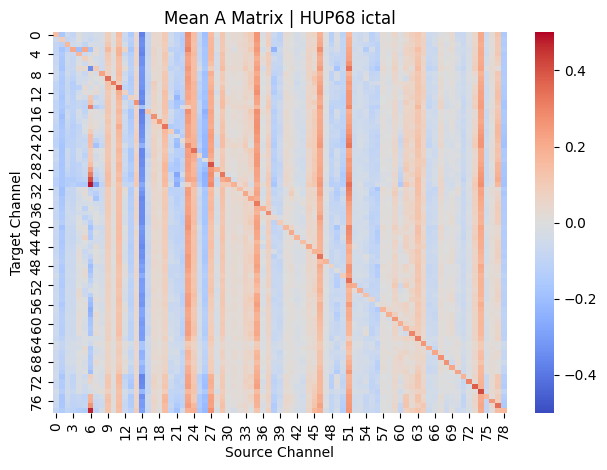

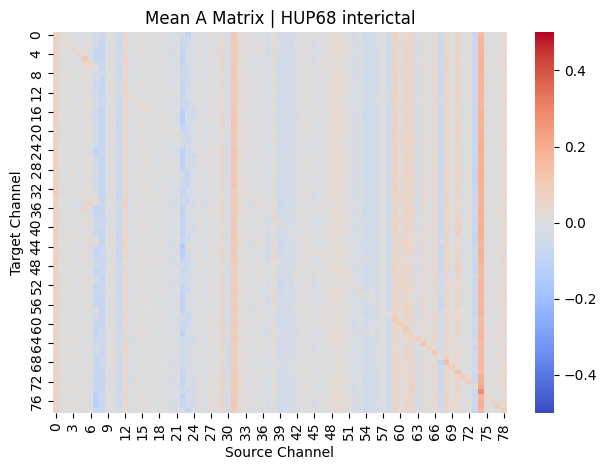

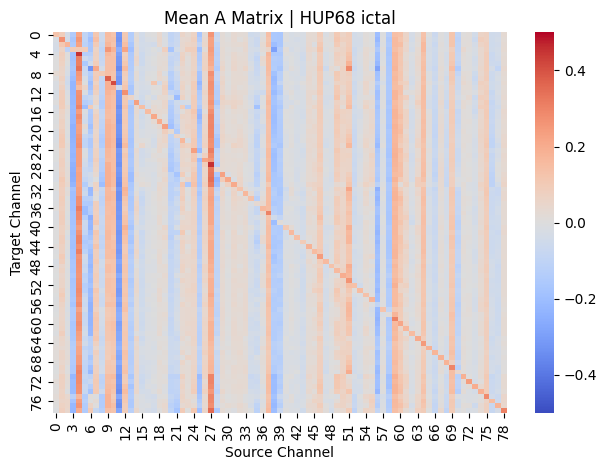

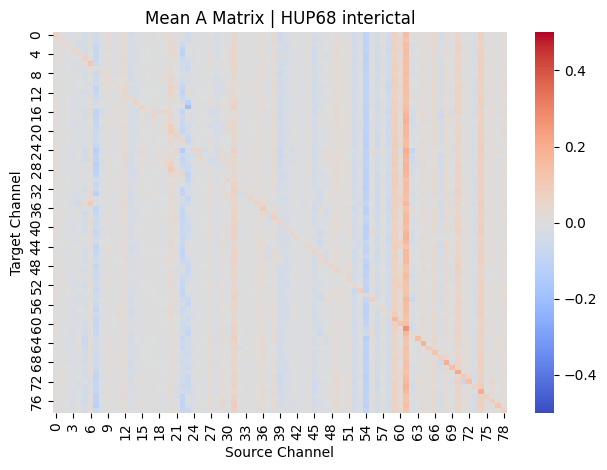

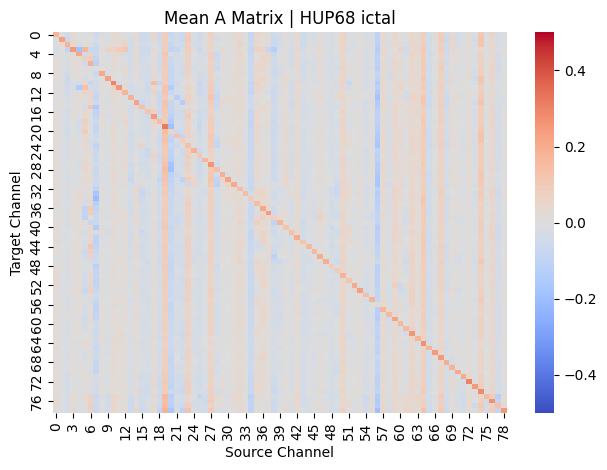

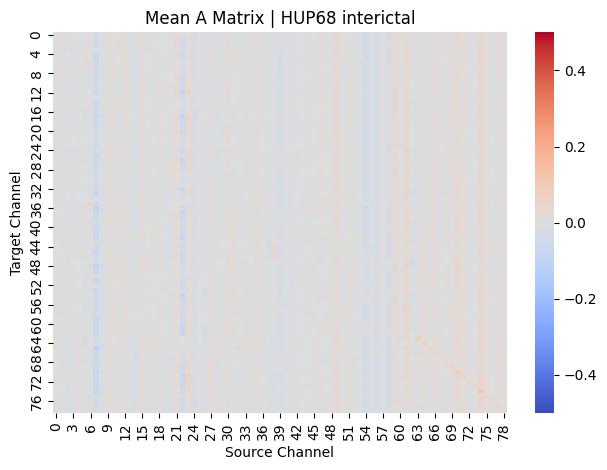

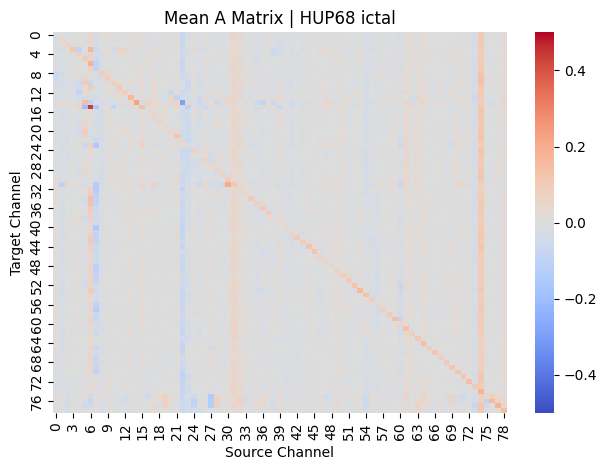

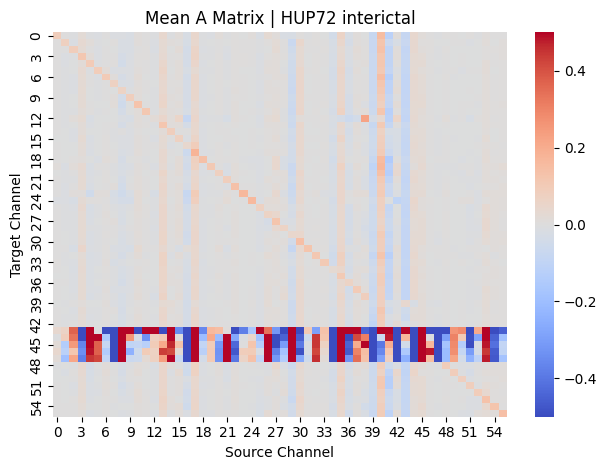

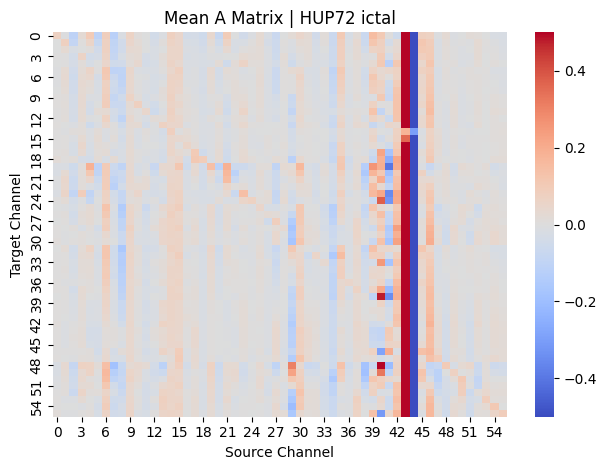

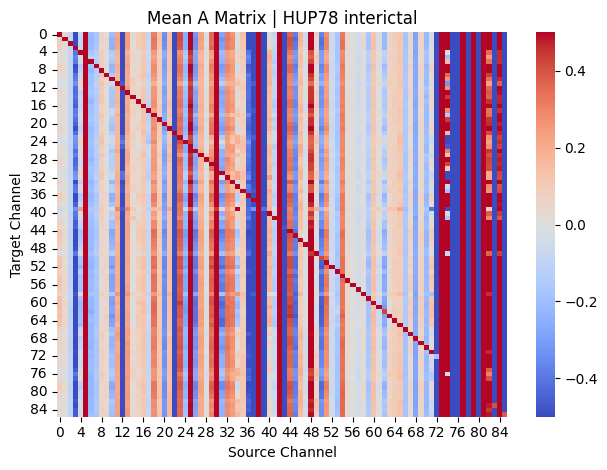

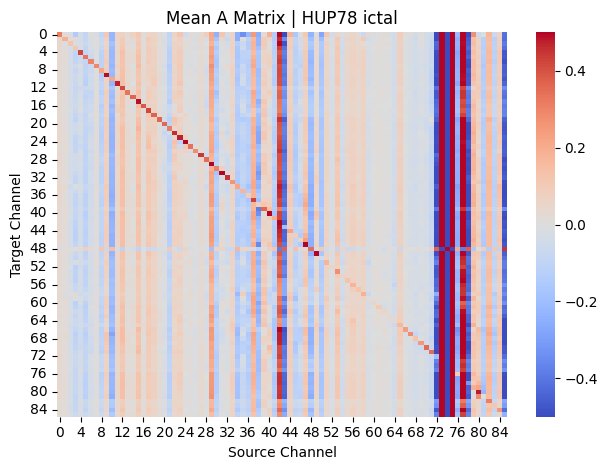

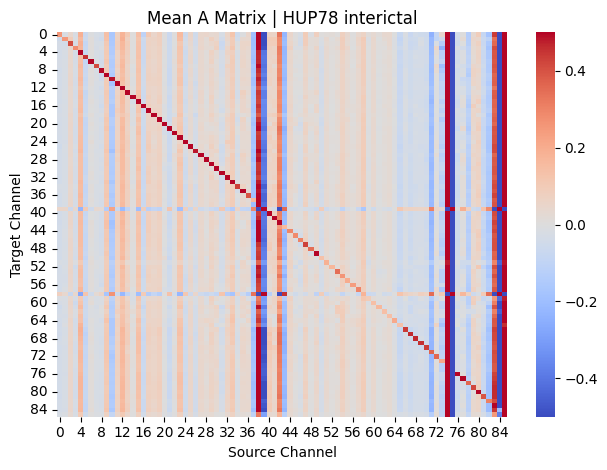

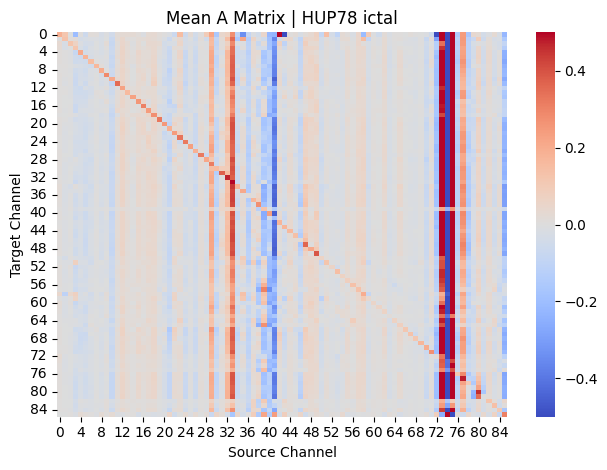

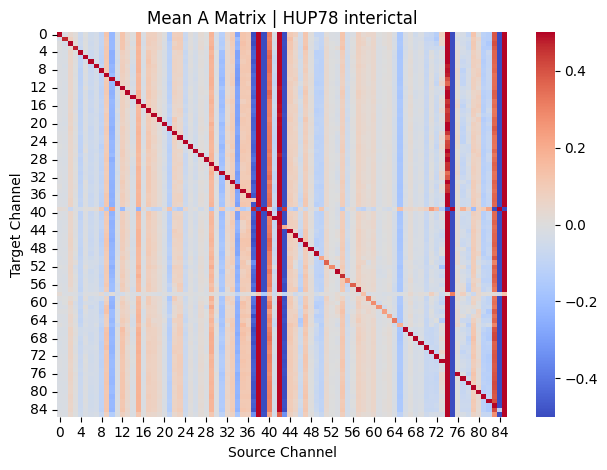

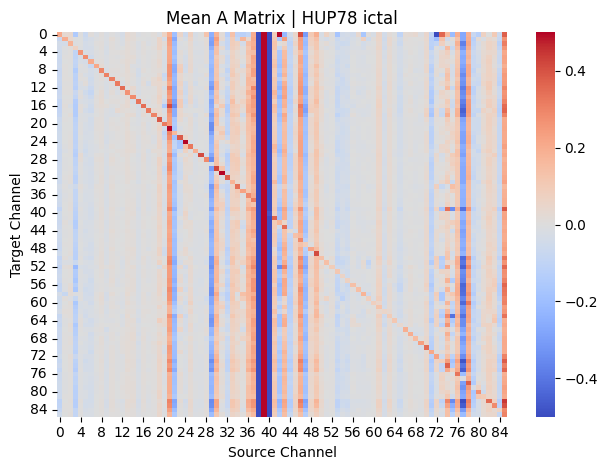

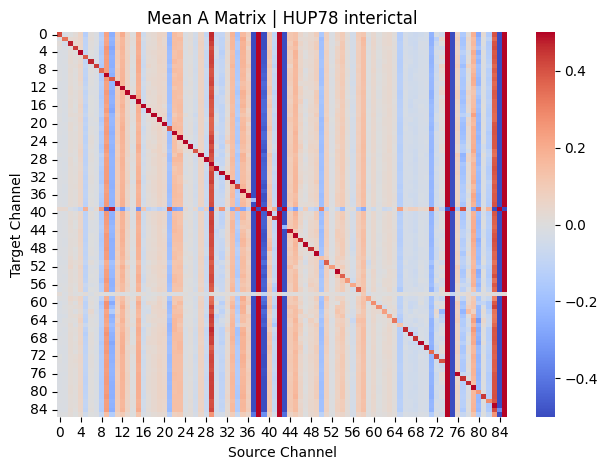

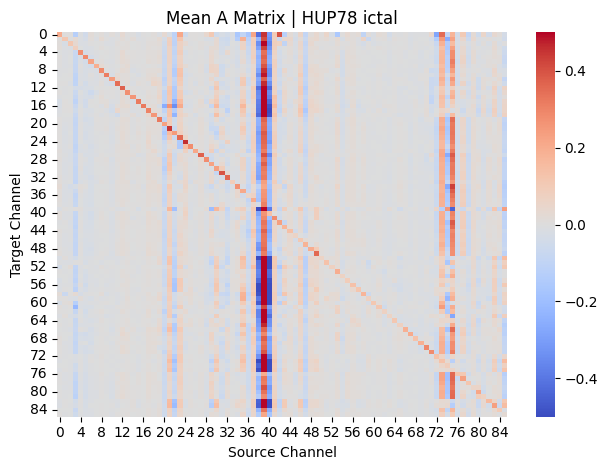

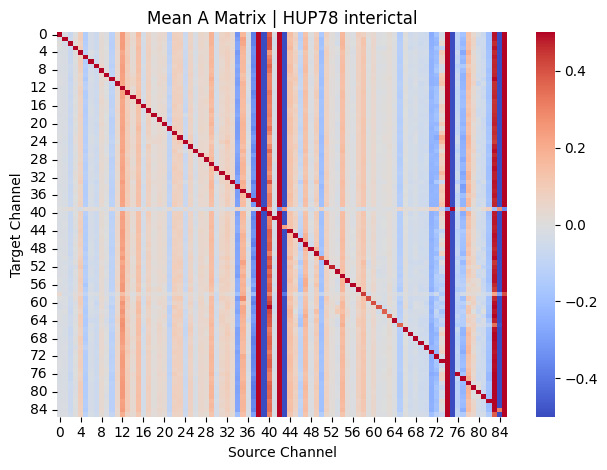

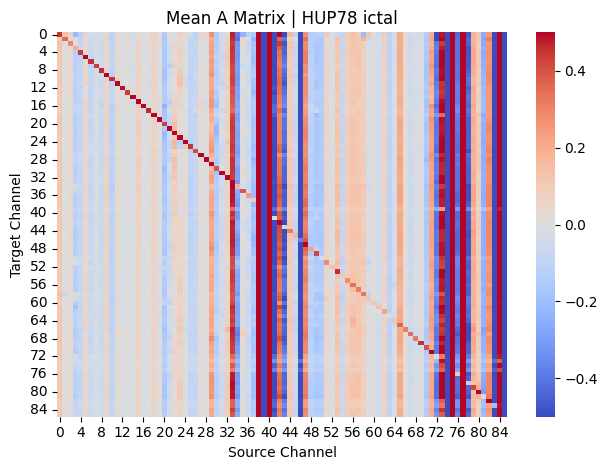

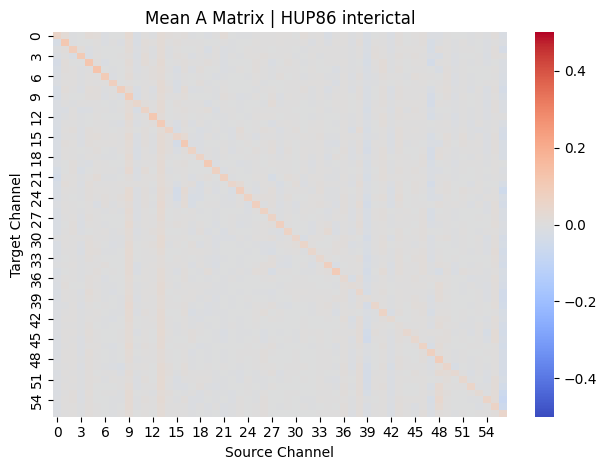

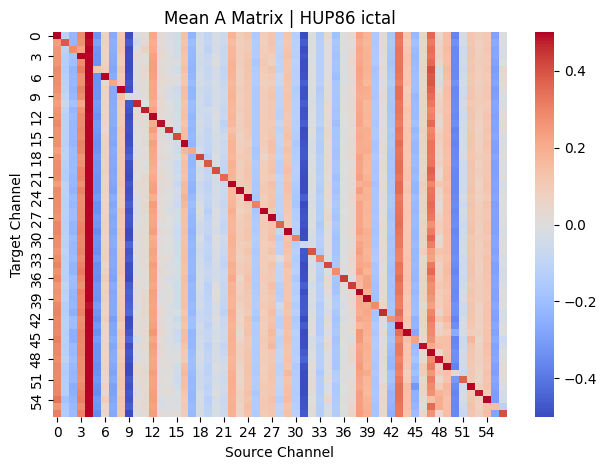

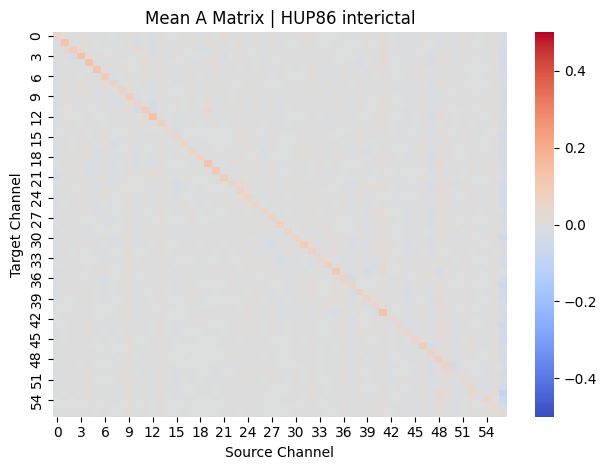

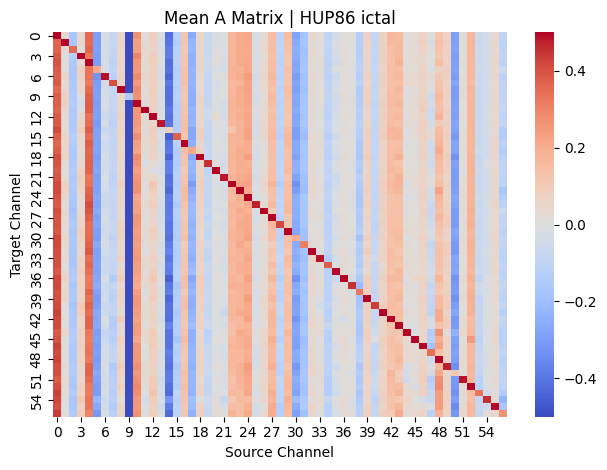

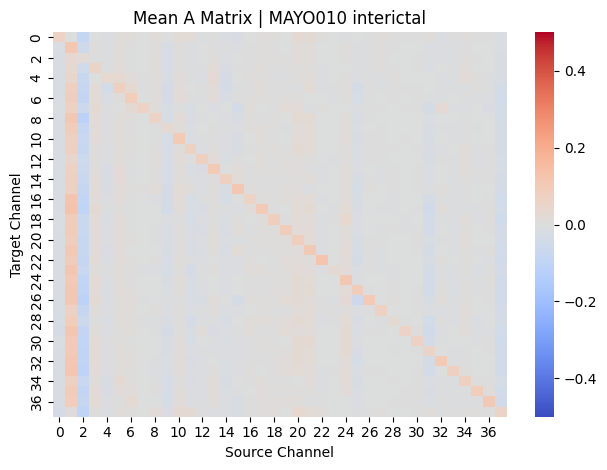

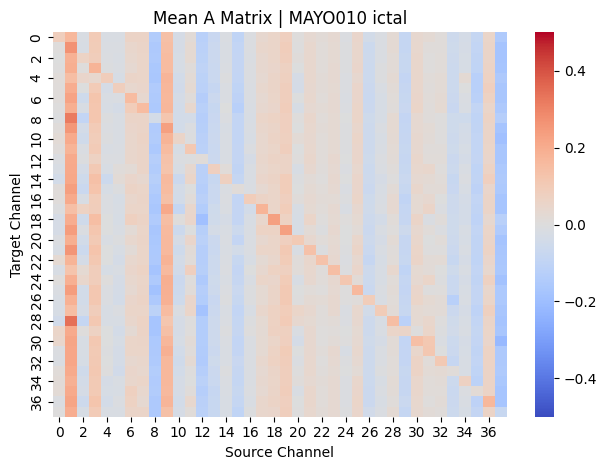

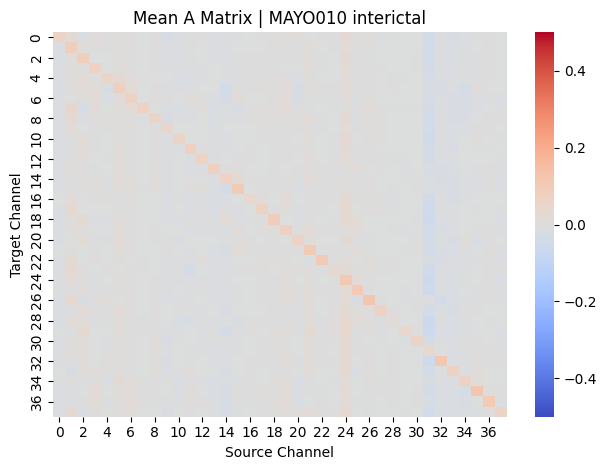

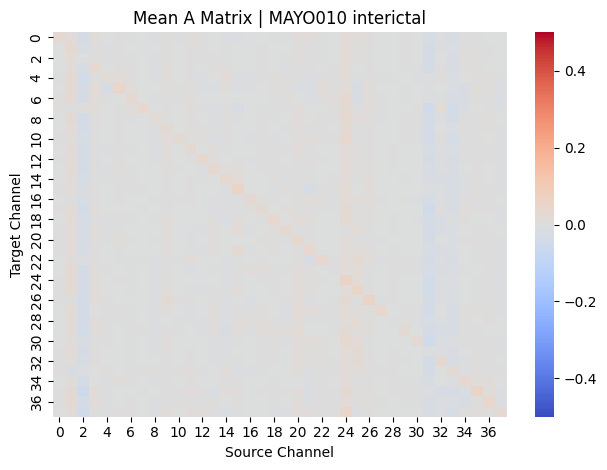

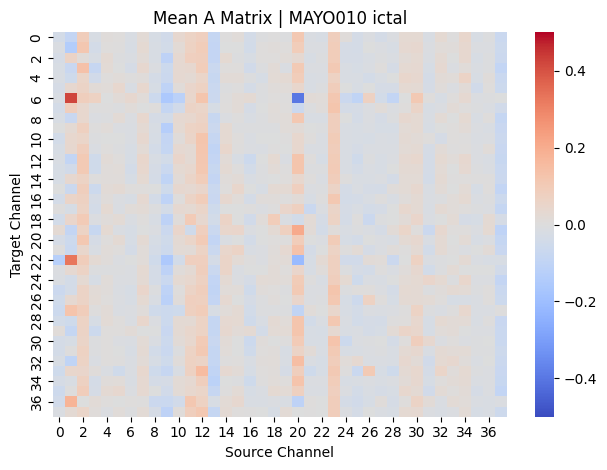

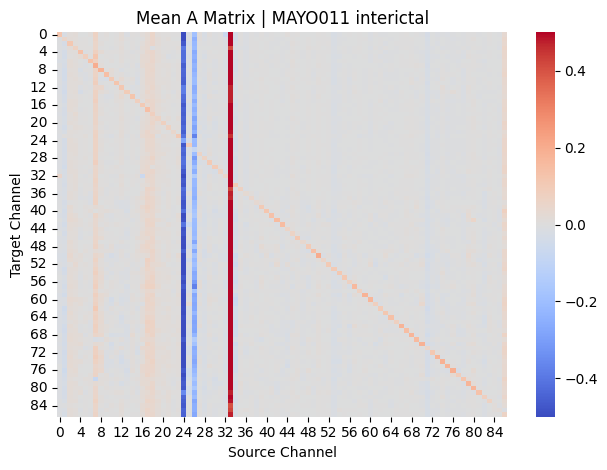

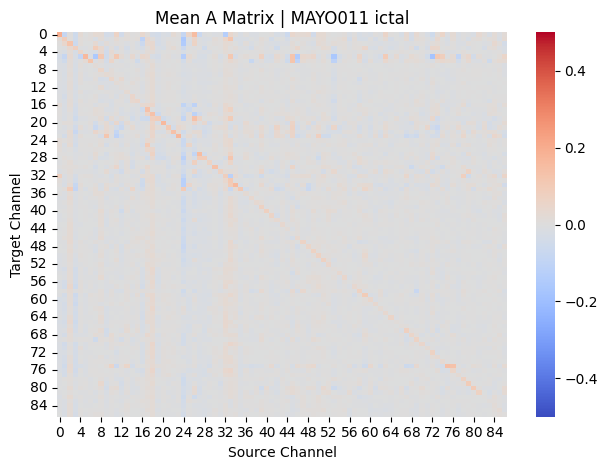

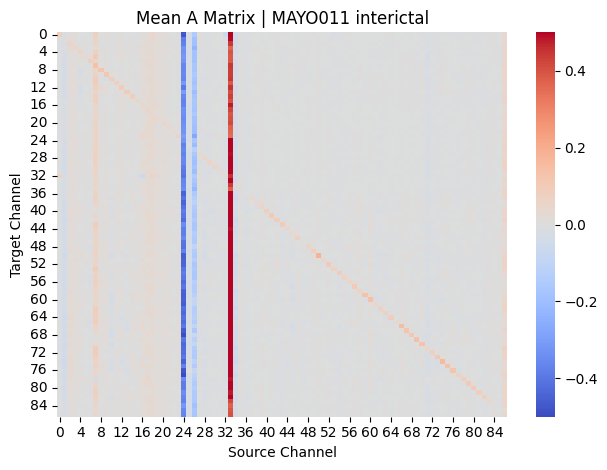

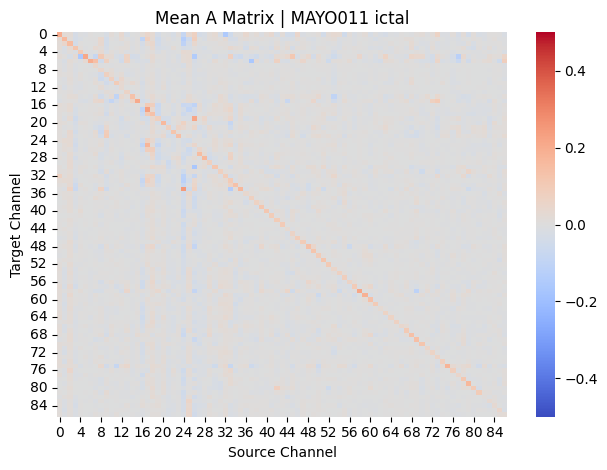

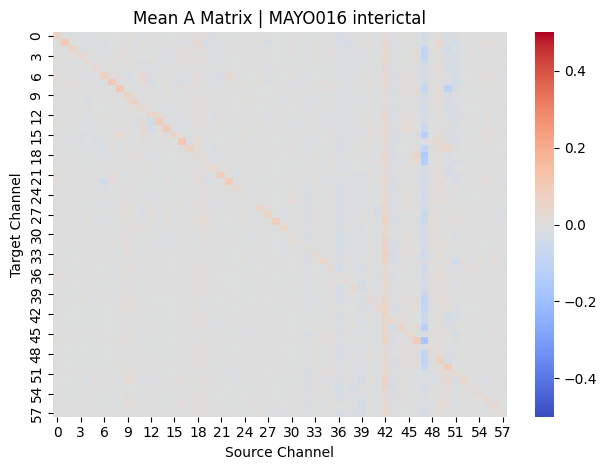

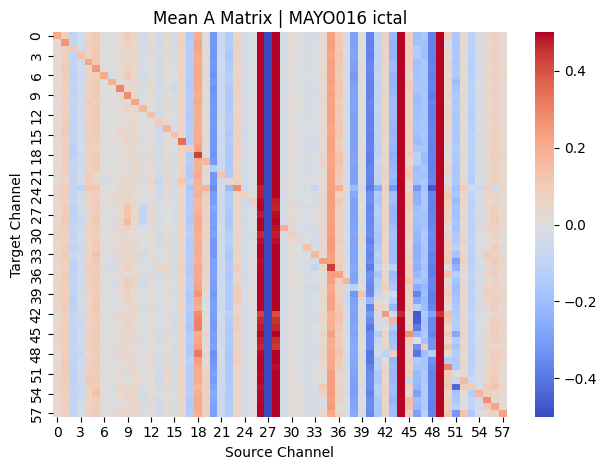

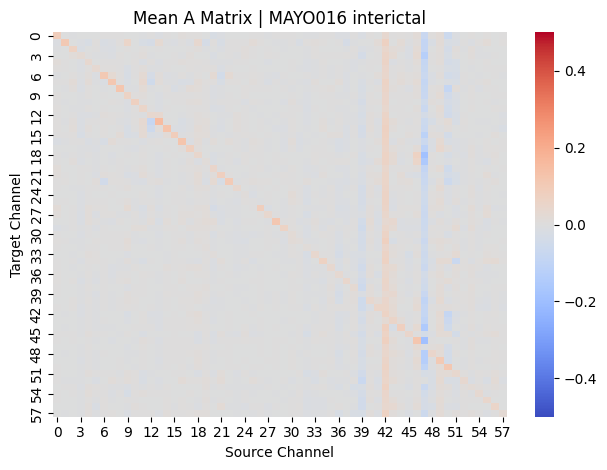

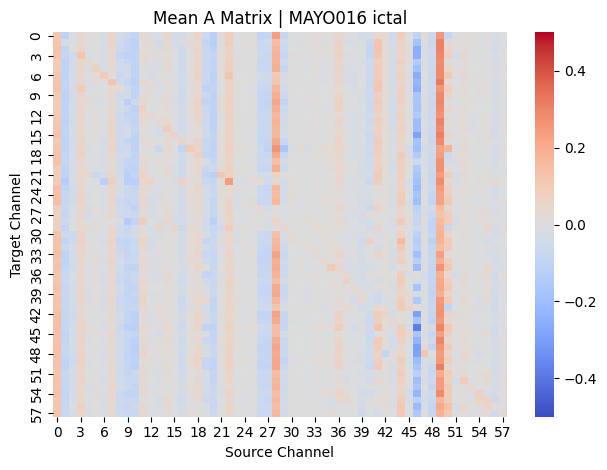

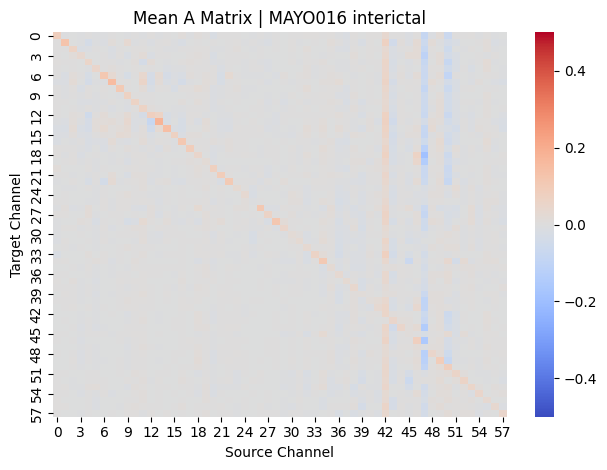

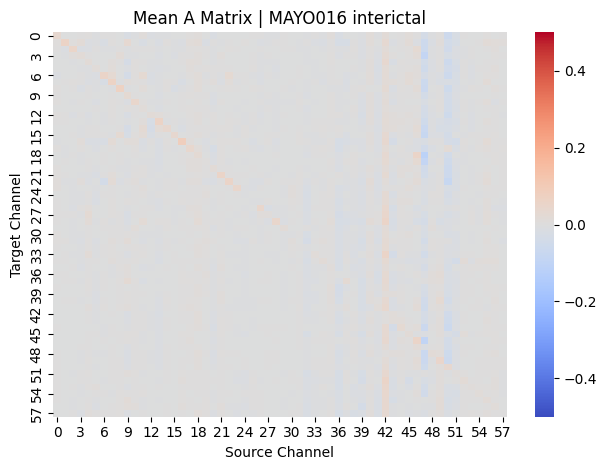

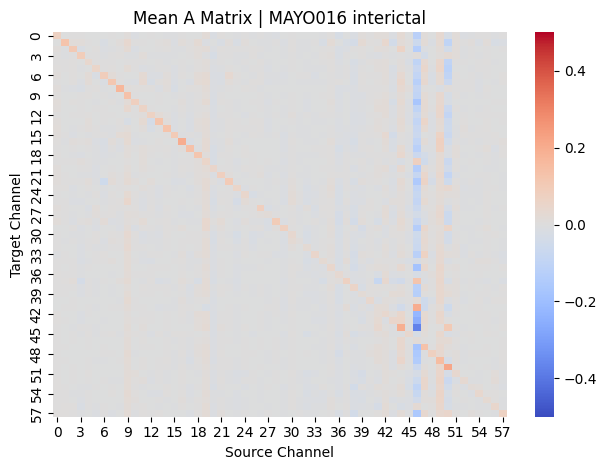

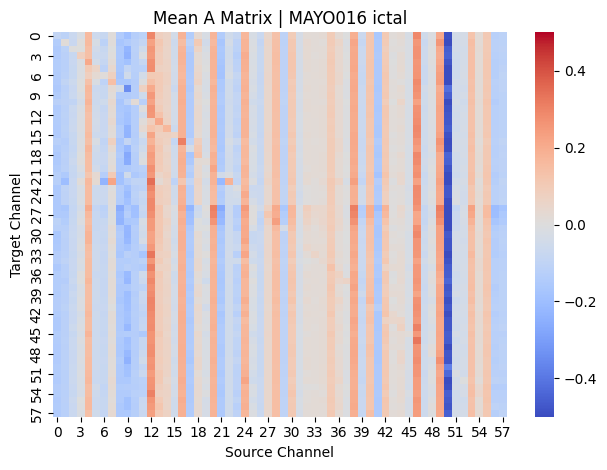

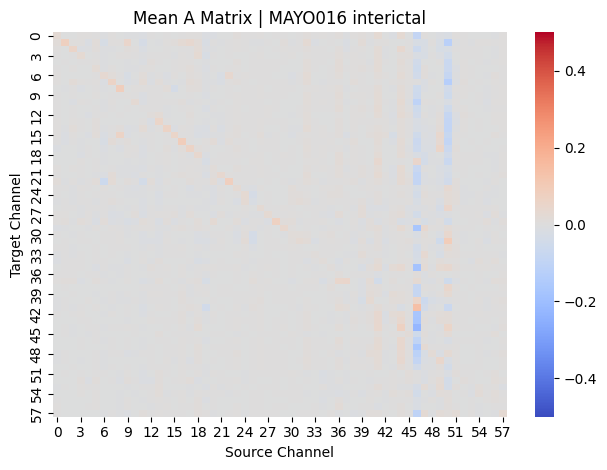

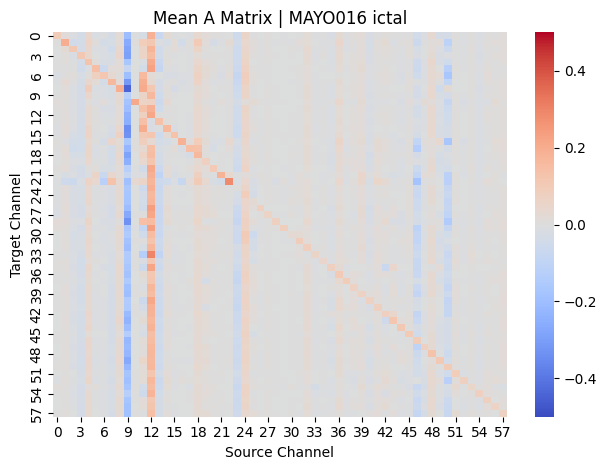

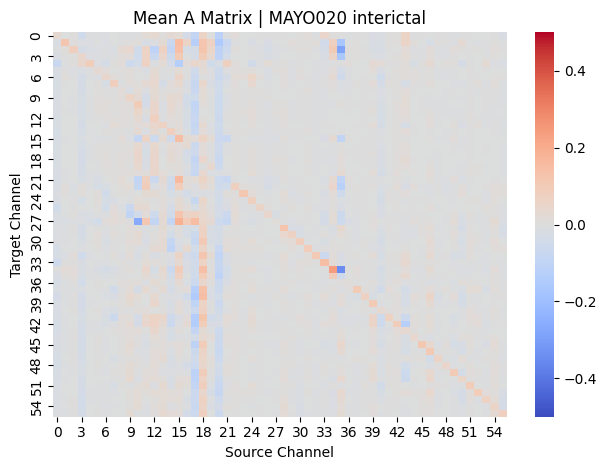

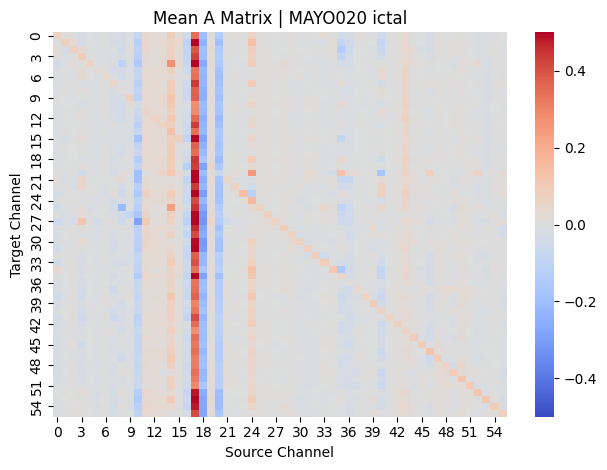

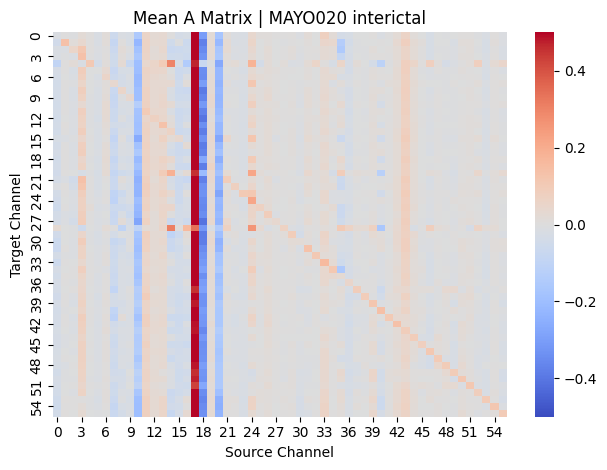

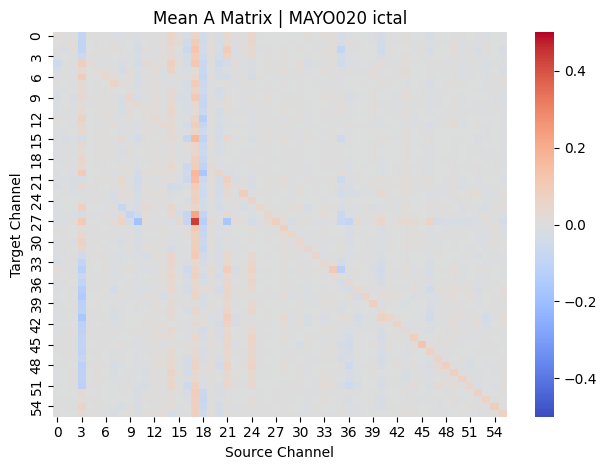

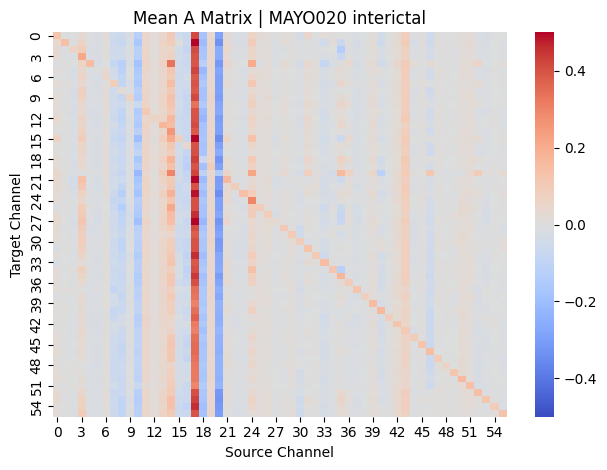

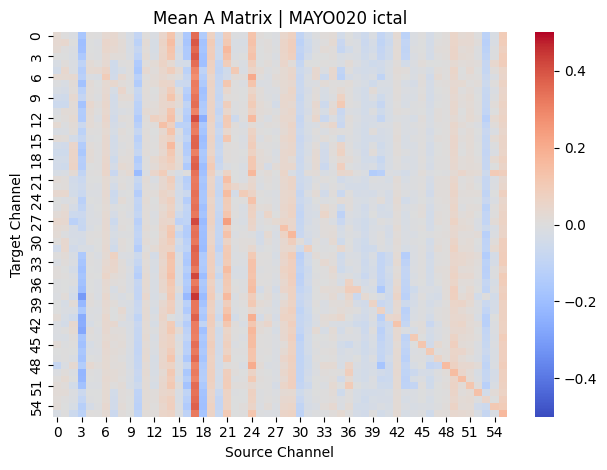

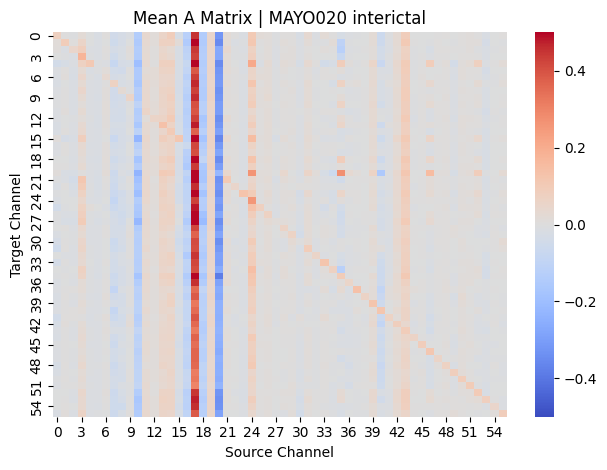

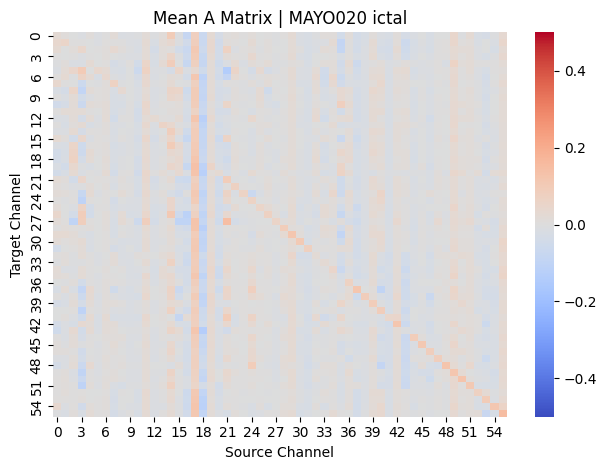

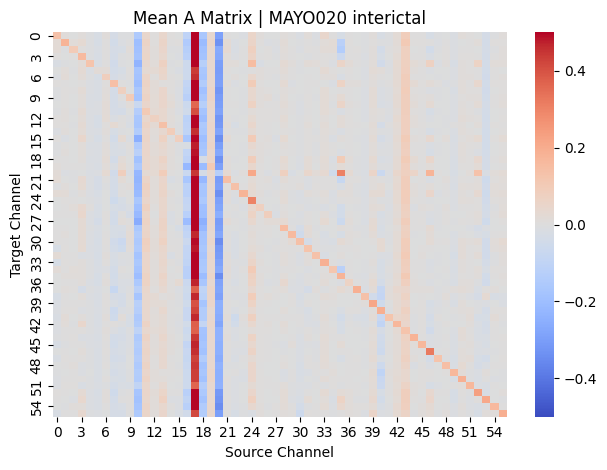

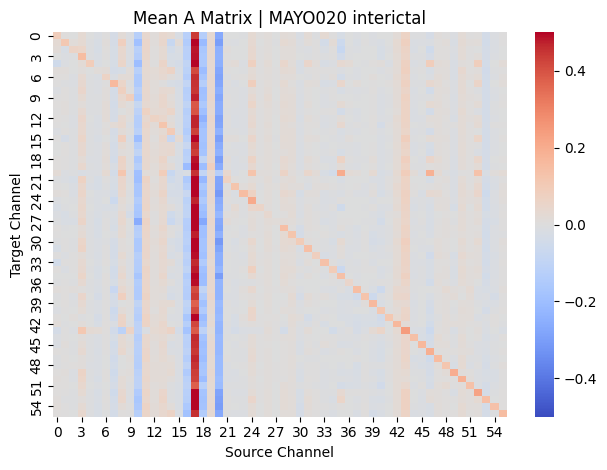

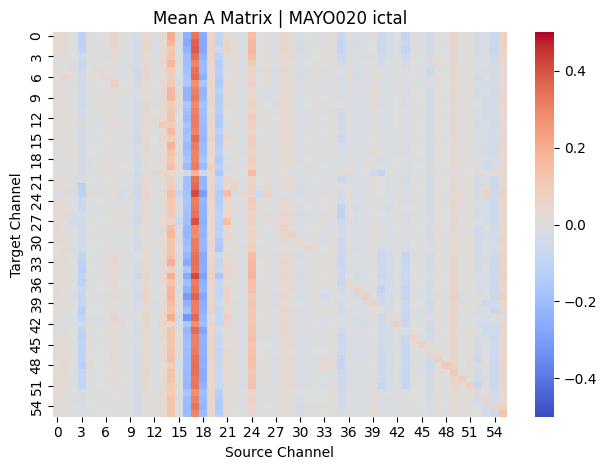

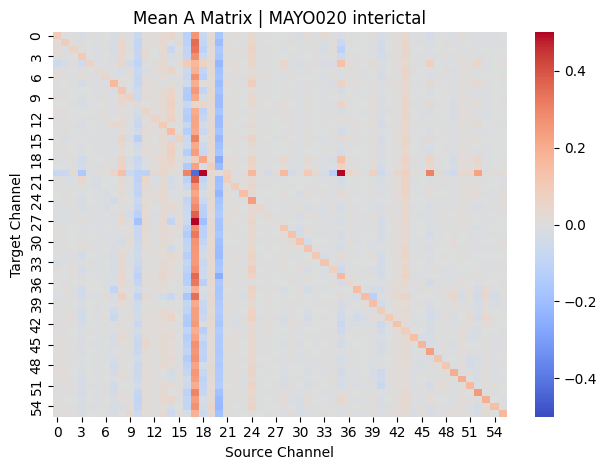

In [ ]:
# Plotting heatmap of A matrix 
for patient in patients: 
    for seizure in range(1, 9):
        for phase in ['interictal', 'ictal']:
            path = os.path.join(main_pathname, 'data_v2', patient, f'{phase}-block-{seizure}_parameters_3sec_1iter.mat')
            if(os.path.exists(path)):
                parameters = scipy.io.loadmat(path)
                A_matrix = parameters['A']
                A_avg = np.mean(A_matrix, axis=2) 
                plt.figure()
                sns.heatmap(A_avg, cmap='coolwarm', vmin=-.5, vmax=.5,center=0)
                plt.title(f'Mean A Matrix | {patient} {phase}')
                plt.xlabel('Source Channel')
                plt.ylabel('Target Channel')
                plt.tight_layout()
                plt.show()